# Reader guide to the completed version-12 notebook

This is a presentation-only copy of the exact **completed resumed execution**. All 105 original cells, 54 code execution counts and saved outputs remain unchanged and in order. No code was added or rerun to create this copy.

The workflow trained or restored seven classical configurations and nine DL configurations. Version 12 trained C4 and restored the other fifteen models by checked identity. The checkpointed DL epoch counts are: A1 12, B1 15, B2 11, B3 13, B4 10, C1 17, C2 16, C3 11 and C4 9. Only C4's nine-point epoch history survives in the terminal record. For example, **C2: 16 checkpointed epochs; history unavailable**. Therefore later original outputs that display a history length of 0 mean “not retained after restoration,” not “not trained.”

Some original explanatory outputs also display TEACHING architecture defaults. The FULL settings in the configuration table and controller source are authoritative. Figures below are embedded reader aids from saved version-12 artifacts; they are not fabricated execution outputs.


# Smart-Contract Vulnerability Detection from EVM Bytecode: Two-Mode Reference Notebook

This notebook shows, step by step, how the deep-learning and classical experiments behind the paper are computed on the released v2 dataset. Every number is produced by a visible cell below; nothing is loaded from hidden state, and every input file is authenticated by its SHA-256 before it is used.

**How to read it.** Section 1 fixes the run mode and the seeds. Section 2 resolves and audits the data and defines the teaching split. Later sections will train the models, select thresholds on the validation role only, freeze that choice once, and report per-label F1. In this revision the sections that are not yet migrated are shown as clearly marked placeholder cells; each finished code cell is preceded by a short explanation of what it computes and why it matters.

**Two modes, one switch.** `TEACHING` runs a bounded CPU demonstration on a 4,096-row sample of the TRAIN role and labels every result `DEMO_ONLY`. `FULL_KAGGLE_GPU` is the later GPU run over the released TRAIN, VAL, and TEST roles; its results are `RETROSPECTIVE_REFERENCE_CANDIDATE`, not an estimate on untouched external contracts. The mode name is the only thing a reader edits.

**What it is not.** It does not fetch data from the network, does not read credentials, and does not depend on a single Colab session. The eight targets are Slither-derived proxy labels, so the outputs are a prioritization aid for reviewers, not an audit verdict.

## 1. Setup and Reproducibility

### Choose one execution mode

There is one editable switch. `TEACHING` uses only the canonical TRAIN parent; it never opens official VAL or official TEST, and every result is labelled `DEMO_ONLY`. `FULL_KAGGLE_GPU` is the later GPU workflow over the released TRAIN, VAL, and TEST roles: fit on TRAIN, select on VAL, freeze once, then evaluate TEST once. Its results are `RETROSPECTIVE_REFERENCE_CANDIDATE`, not an unbiased estimate on a previously untouched external population.

The process registry shows all ten deep-learning configurations in order. B5 is visible as a diagnostic, but it is not trained again and is excluded from selection.

In [1]:
from dataclasses import dataclass
from types import MappingProxyType
from typing import Literal

# THE ONE SWITCH A READER MAY EDIT. "TEACHING" runs the bounded CPU demonstration
# on a 4,096-row sample of the released TRAIN role. "FULL_KAGGLE_GPU" is the later
# GPU run over the released TRAIN, VAL and TEST roles. Any other value is rejected.
RUN_MODE = "FULL_KAGGLE_GPU"

@dataclass(frozen=True)
class ModeConfig:
    mode: Literal["TEACHING", "FULL_KAGGLE_GPU"]
    permitted_prefreeze_roles: tuple[str, ...]
    heldout_role: Literal["demo_holdout", "official_test"]
    result_status: Literal["DEMO_ONLY", "RETROSPECTIVE_REFERENCE_CANDIDATE"]
    selected_rows: int | None
    demo_counts: tuple[int, int, int] | None
    split_seed: int
    model_seed: int
    max_seq_len: int
    batch_size: int
    epochs: int
    requires_gpu: bool
    max_wall_seconds: int | None
    max_peak_rss_bytes: int | None
    max_projected_rss_delta_bytes: int | None

_TEACHING_PROFILE = ModeConfig(
    mode="TEACHING",
    permitted_prefreeze_roles=("TRAIN",),
    heldout_role="demo_holdout",
    result_status="DEMO_ONLY",
    selected_rows=4096,
    demo_counts=(3276, 410, 410),
    split_seed=376,
    model_seed=42,
    max_seq_len=1024,
    batch_size=32,
    epochs=2,
    requires_gpu=False,
    max_wall_seconds=1500,
    max_peak_rss_bytes=6_000_000_000,
    max_projected_rss_delta_bytes=1_500_000_000,
)

_FULL_PROFILE = ModeConfig(
    mode="FULL_KAGGLE_GPU",
    permitted_prefreeze_roles=("TRAIN", "VAL"),
    heldout_role="official_test",
    result_status="RETROSPECTIVE_REFERENCE_CANDIDATE",
    selected_rows=None,
    demo_counts=None,
    split_seed=376,
    model_seed=42,
    max_seq_len=20_000,
    batch_size=32,
    epochs=20,
    requires_gpu=True,
    max_wall_seconds=None,
    max_peak_rss_bytes=None,
    max_projected_rss_delta_bytes=None,
)

MODE_PROFILES = MappingProxyType({
    "TEACHING": _TEACHING_PROFILE,
    "FULL_KAGGLE_GPU": _FULL_PROFILE,
})

PROCESS_REGISTRY = ("A1", "B1", "B2", "B3", "B4", "B5", "C1", "C2", "C3", "C4")
TRAINED_REGISTRY = ("A1", "B1", "B2", "B3", "B4", "C1", "C2", "C3", "C4")
SELECTION_REGISTRY = ("A1", "B1", "B2", "B3", "B4", "C1", "C2", "C3", "C4")
DIAGNOSTIC_REGISTRY = ("B5",)

def mode_config_v1(mode: str) -> ModeConfig:
    """Return the one canonical profile for a mode name; anything else is rejected."""
    if type(mode) is not str or mode not in ("TEACHING", "FULL_KAGGLE_GPU"):
        raise ValueError("E_MODE_NOT_CANONICAL")
    return MODE_PROFILES[mode]

# Resolved from RUN_MODE at the top of this cell; not for editing.
MODE_CONFIG = mode_config_v1(RUN_MODE)


The next cells use logical role aliases rather than machine-specific paths. In TEACHING, expect a bounded CPU-friendly demonstration (up to 1,500 seconds, 6 GB peak RSS, and 1.5 GB projected RSS growth). FULL_KAGGLE_GPU requires a usable GPU and intentionally has no inherited TEACHING wall-time or memory cap.

In [2]:
# Full seed control
# The seeds are part of the mode profile; the controller applies them itself
# (split, carve-out, model initialisation) and records them in the frozen selection.
print("Split seed:", MODE_CONFIG.split_seed, "| model seed:", MODE_CONFIG.model_seed)
print("Seeds are applied inside the sealed controller; no cell sets a global seed by hand.")


Split seed: 376 | model seed: 42
Seeds are applied inside the sealed controller; no cell sets a global seed by hand.


In [3]:
# Retired step (intentionally inactive)
# RETIRED: this step of the original notebook is switched off on purpose (for example, recursive local or cloud-drive discovery) and will not return. The position is kept so the lineage stays visible.
pass

In [4]:
# Mode-aware hardware preflight
# The device decision is the controller's: the demonstration runs on the
# processor within its published limits; the complete run refuses to start
# without a usable graphics card and has no other branch.
print("Mode:", MODE_CONFIG.mode, "| requires a graphics card:", MODE_CONFIG.requires_gpu)
if MODE_CONFIG.max_wall_seconds is not None:
    print("Published limits: wall", MODE_CONFIG.max_wall_seconds, "s | peak memory", MODE_CONFIG.max_peak_rss_bytes, "bytes | memory growth", MODE_CONFIG.max_projected_rss_delta_bytes, "bytes")
else:
    print("No wall or memory cap in this mode; the quota guard decides before every stage.")


Mode: FULL_KAGGLE_GPU | requires a graphics card: True
No wall or memory cap in this mode; the quota guard decides before every stage.


In [5]:
# Mode-bound hyperparameters and identity-bound run storage
# Hyperparameters come from the mode profile and the model cells; run storage is
# the working directory's artifacts tree, which the controller alone writes.
from pathlib import Path

BASE = Path.cwd()
RUNS_DIR = BASE / "artifacts"
CKPT_DIR = RUNS_DIR / "models"
print("Sequence limit:", MODE_CONFIG.max_seq_len, "| batch size:", MODE_CONFIG.batch_size, "| epochs at most:", MODE_CONFIG.epochs)
print("Run storage: the artifacts tree of the working directory; models under", CKPT_DIR.relative_to(BASE).as_posix())


Sequence limit: 20000 | batch size: 32 | epochs at most: 20
Run storage: the artifacts tree of the working directory; models under artifacts/models


### Resolve the authenticated data root without guessing

Resolution is deterministic and fail-closed. The four tiers are: the explicit `DEFI_V2_DATA_DIR` value, archive-relative `01_data_v2`, the programmatically constructed Kaggle datasets root, and the programmatically constructed Kaggle input root. The first nonempty tier must contain exactly one complete canonical root. A stale or ambiguous first tier stops immediately. Reader output should name only the accepted tier and logical alias `ARCHIVE_DATA_ROOT`, never a raw filesystem path.

In [6]:
import hashlib
import json
import os
from dataclasses import dataclass
from pathlib import Path
from typing import Literal

@dataclass(frozen=True)
class FileIdentity:
    sha256: str
    bytes: int

@dataclass(frozen=True)
class DeclaredFileIdentity:
    sha256: str
    bytes: int
    rows: int

@dataclass(frozen=True)
class ResolvedRoleIdentity:
    role: Literal["train", "val"]
    identity: FileIdentity

    def __post_init__(self) -> None:
        if self.role not in ("train", "val") or type(self.identity) is not FileIdentity:
            raise ValueError("E_DATA_RESOLUTION:role")

@dataclass(frozen=True)
class ResolvedData:
    mode: Literal["TEACHING", "FULL_KAGGLE_GPU"]
    state: Literal["SETUP", "TRAINING", "SELECTION_FROZEN"]
    role_identities: tuple[ResolvedRoleIdentity, ...]
    manifest_identity: FileIdentity
    declared_test_identity: DeclaredFileIdentity | None
    feature_order: tuple[str, ...]
    label_order: tuple[str, ...]

    def __post_init__(self) -> None:
        roles = tuple(item.role for item in self.role_identities)
        if self.mode not in ("TEACHING", "FULL_KAGGLE_GPU") or self.state not in ("SETUP", "TRAINING", "SELECTION_FROZEN"):
            raise ValueError("E_DATA_RESOLUTION:construction")
        if type(self.role_identities) is not tuple or not roles or len(set(roles)) != len(roles):
            raise ValueError("E_DATA_RESOLUTION:construction")
        if any(type(item) is not ResolvedRoleIdentity for item in self.role_identities) or not set(roles) <= {"train", "val"}:
            raise ValueError("E_DATA_RESOLUTION:construction")
        if type(self.manifest_identity) is not FileIdentity:
            raise ValueError("E_DATA_RESOLUTION:construction")
        if self.declared_test_identity is not None and type(self.declared_test_identity) is not DeclaredFileIdentity:
            raise ValueError("E_DATA_RESOLUTION:construction")
        for order in (self.feature_order, self.label_order):
            if type(order) is not tuple or not order or not all(
                type(item) is str and item and all(ch.isalnum() or ch in "-_." for ch in item) for item in order
            ):
                raise ValueError("E_DATA_RESOLUTION:construction")

# The four canonical tiers in resolution order. Only the first enabled tier
# is examined; a later tier is never a fallback for a broken earlier one.
_TIER_NAMES = ("ENVIRONMENT", "ARCHIVE_RELATIVE", "KAGGLE_DATASETS", "KAGGLE_INPUT")
_SIDECARS = ("manifest_v2.json", "feature_columns.json", "label_mappings.json")
# the two values of the label sidecar that name no label
_NON_LABEL_MARKERS = ("ignore", "safe")

def build_data_tiers(*, environ=None, archive_root, platform_root, kaggle_owner, kaggle_slug):
    """Construct the exact four-tier root list. Nothing is searched for.

    ENVIRONMENT is enabled only when DEFI_V2_DATA_DIR is set. The other three
    roots are built from their pinned parts and enabled only when that exact
    directory exists. The Kaggle tiers stay empty until owner and slug are pinned.
    """
    environment = os.environ if environ is None else environ
    explicit = environment.get("DEFI_V2_DATA_DIR")
    for pinned in (kaggle_owner, kaggle_slug):
        if type(pinned) is not str or Path(pinned).name != pinned or pinned in (".", ".."):
            raise RuntimeError("E_DATA_TIER_NOT_CANONICAL:kaggle-pin")
    archive = Path(os.fspath(archive_root)) / "01_data_v2"
    kaggle_input = Path(os.fspath(platform_root)) / "kaggle" / "input"
    datasets = (kaggle_input / "datasets" / kaggle_owner / kaggle_slug,) if kaggle_owner and kaggle_slug else ()
    inputs = (kaggle_input / kaggle_slug,) if kaggle_slug else ()
    explicit_roots = (Path(explicit),) if explicit else ()
    return (
        ("ENVIRONMENT", explicit is not None, explicit_roots),
        ("ARCHIVE_RELATIVE", archive.is_dir(), (archive,)),
        ("KAGGLE_DATASETS", bool(datasets) and datasets[0].is_dir(), datasets),
        ("KAGGLE_INPUT", bool(inputs) and inputs[0].is_dir(), inputs),
    )

def resolve_explicit_tiers(mode_config, tiers, authority_contract) -> ResolvedData:
    """Resolve the first enabled tier and authenticate only the permitted roles.

    The result carries identities (SHA-256, byte counts, declared row counts)
    and the schema order. It carries no paths, no file handles, and no way to
    open the held-out role: TEACHING touches TRAIN only; FULL_KAGGLE_GPU touches
    TRAIN and VAL before the freeze and records the manifest-declared TEST
    identity without opening that file.
    """
    if type(mode_config) is not ModeConfig or mode_config.mode not in ("TEACHING", "FULL_KAGGLE_GPU"):
        raise ValueError("E_MODE_NOT_CANONICAL")
    permitted = ("TRAIN",) if mode_config.mode == "TEACHING" else ("TRAIN", "VAL")
    if tuple(mode_config.permitted_prefreeze_roles) != permitted:
        raise ValueError("E_MODE_NOT_CANONICAL")

    def record(mapping, key, with_rows):
        entry = mapping.get(key) if type(mapping) is dict else None
        if type(entry) is not dict or type(entry.get("sha256")) is not str or type(entry.get("bytes")) is not int:
            raise RuntimeError("E_DATA_AUTHORITY_CONTRACT:" + str(key))
        if with_rows and type(entry.get("rows")) is not int:
            raise RuntimeError("E_DATA_AUTHORITY_CONTRACT:" + str(key))
        return entry

    # 1. The authority contract is checked before any filesystem access.
    if type(authority_contract) is not dict:
        raise RuntimeError("E_DATA_AUTHORITY_CONTRACT")
    role_files = authority_contract.get("role_files")
    role_identities = authority_contract.get("role_identities")
    sidecars = authority_contract.get("sidecars")
    label_source = authority_contract.get("label_order")
    if type(role_files) is not dict or type(label_source) not in (tuple, list) or not label_source:
        raise RuntimeError("E_DATA_AUTHORITY_CONTRACT")
    label_order = tuple(label_source)
    if not all(type(item) is str for item in label_order):
        raise RuntimeError("E_DATA_AUTHORITY_CONTRACT:label_order")
    for role in permitted:
        if role_files.get(role) != role.lower() + "_v2.parquet":
            raise RuntimeError("E_DATA_AUTHORITY_CONTRACT:" + role)
        record(role_identities, role, True)
    for name in _SIDECARS:
        record(sidecars, name, False)
    feature_count = sidecars["feature_columns.json"].get("count")
    if type(feature_count) is not int or feature_count <= 0:
        raise RuntimeError("E_DATA_AUTHORITY_CONTRACT:count")
    declared = None
    if mode_config.mode == "FULL_KAGGLE_GPU":
        declared = record(authority_contract, "declared_test_identity", True)

    # 2. Tier list: canonical names in canonical order, no duplicates, exact shapes.
    if type(tiers) is not tuple or not all(type(tier) is tuple and len(tier) == 3 for tier in tiers):
        raise RuntimeError("E_DATA_TIER_NOT_CANONICAL")
    names = tuple(tier[0] for tier in tiers)
    if not all(name in _TIER_NAMES for name in names) or len(set(names)) != len(names):
        raise RuntimeError("E_DATA_TIER_NOT_CANONICAL")
    if tuple(sorted(names, key=_TIER_NAMES.index)) != names:
        raise RuntimeError("E_DATA_TIER_NOT_CANONICAL:order")
    if not all(type(tier[1]) is bool and type(tier[2]) is tuple for tier in tiers):
        raise RuntimeError("E_DATA_TIER_NOT_CANONICAL:shape")

    # 3. The first enabled tier must hold exactly one complete root; there is no fallback.
    enabled = [tier for tier in tiers if tier[1]]
    if not enabled:
        raise RuntimeError("E_DATA_RESOLUTION:E_DATA_NO_NONEMPTY_TIER")
    tier_name, _, raw_roots = enabled[0]
    keyed = {}
    for raw_root in raw_roots:
        root = Path(os.fspath(raw_root))
        key = os.path.normcase(os.fspath(root.resolve()))
        if key not in keyed:
            keyed[key] = root
    if len(keyed) != 1:
        raise RuntimeError("E_DATA_RESOLUTION:E_DATA_FIRST_NONEMPTY_TIER_INVALID:" + tier_name)
    root = next(iter(keyed.values()))
    if not root.is_dir() or not all((root / role_files[role]).is_file() for role in permitted):
        raise RuntimeError("E_DATA_RESOLUTION:E_DATA_FIRST_NONEMPTY_TIER_INVALID:" + tier_name)

    # 4. Sidecars and permitted role files are authenticated by exact byte count and SHA-256.
    def authenticate(filename, entry):
        target = root / filename
        data = target.read_bytes() if target.is_file() else None
        if data is None or len(data) != entry["bytes"] or hashlib.sha256(data).hexdigest() != entry["sha256"]:
            raise RuntimeError("E_DATA_RESOLUTION:E_DATA_ROOT_AUTHENTICATION:" + filename)
        return data

    manifest_bytes = authenticate("manifest_v2.json", sidecars["manifest_v2.json"])
    try:
        manifest = json.loads(manifest_bytes)
        features = json.loads(authenticate("feature_columns.json", sidecars["feature_columns.json"]))
        labels = json.loads(authenticate("label_mappings.json", sidecars["label_mappings.json"]))
    except ValueError:
        raise RuntimeError("E_DATA_RESOLUTION:E_DATA_ROOT_AUTHENTICATION:sidecar-json")
    if type(features) is not list or len(features) != feature_count or len(set(features)) != feature_count:
        raise RuntimeError("E_DATA_RESOLUTION:E_DATA_ROOT_AUTHENTICATION:feature_columns")
    if not all(type(item) is str and item for item in features):
        raise RuntimeError("E_DATA_RESOLUTION:E_DATA_ROOT_AUTHENTICATION:feature_columns")
    # The released sidecar maps each analyser detector to a label name; its values are
    # the eight labels plus the two markers that mean no label. The manifest carries
    # the label order itself, and both must agree with the contract.
    if type(labels) is not dict or not labels or not all(type(key) is str and type(value) is str for key, value in labels.items()):
        raise RuntimeError("E_DATA_RESOLUTION:E_DATA_ROOT_AUTHENTICATION:label_mappings")
    mapped = sorted(set(labels.values()) - set(_NON_LABEL_MARKERS))
    if mapped != sorted(label_order) or type(manifest) is not dict or manifest.get("labels") != list(label_order):
        raise RuntimeError("E_DATA_RESOLUTION:E_DATA_ROOT_AUTHENTICATION:label_mappings")
    resolved = []
    for role in permitted:
        entry = role_identities[role]
        key = role.lower()
        if manifest.get("n_" + key) != entry["rows"] or manifest.get("sha256_" + key) != entry["sha256"]:
            raise RuntimeError("E_DATA_RESOLUTION:E_DATA_ROOT_AUTHENTICATION:manifest")
        authenticate(role_files[role], entry)
        resolved.append(ResolvedRoleIdentity(key, FileIdentity(entry["sha256"], entry["bytes"])))
    declared_identity = None
    if declared is not None:
        if manifest.get("n_test") != declared["rows"] or manifest.get("sha256_test") != declared["sha256"]:
            raise RuntimeError("E_DATA_RESOLUTION:E_DATA_ROOT_AUTHENTICATION:manifest")
        declared_identity = DeclaredFileIdentity(declared["sha256"], declared["bytes"], declared["rows"])
    return ResolvedData(
        mode=mode_config.mode,
        state="SETUP",
        role_identities=tuple(resolved),
        manifest_identity=FileIdentity(sidecars["manifest_v2.json"]["sha256"], len(manifest_bytes)),
        declared_test_identity=declared_identity,
        feature_order=tuple(features),
        label_order=label_order,
    )


The resolver has no recursive discovery, glob, network, download, mount, or copy fallback. TEACHING authorizes TRAIN only. FULL pre-freeze authorizes TRAIN and VAL only; neither mode receives a TEST locator, reader, path, or callback from this layer.

In [7]:
# Deterministic role-aware data resolution
# Resolution happens inside the sealed run (next section): no mount, no
# discovery, no copy; every file is checked against the released manifest.
print("Roles this mode may open before the freeze:", MODE_CONFIG.permitted_prefreeze_roles)
print("Held-out role of this mode:", MODE_CONFIG.heldout_role)


Roles this mode may open before the freeze: ('TRAIN', 'VAL')
Held-out role of this mode: official_test


## 2. Data Loading

### Prove the loaded data contract before calculation

The audit checks exact column order, authenticated SHA-256, file byte count, row count, feature and label order, binary labels, finite numeric features, and the identity `is_vulnerable = OR(eight labels)`. It reports what these checks prove and keeps the known scientific limitations explicit; it never rewrites the released files.

In [8]:
import hashlib
import json
import math
from typing import Any

_LABEL_ORDER = (
    "access-control", "arithmetic", "bad-randomness", "double-spending",
    "locked-ether", "other", "reentrancy", "unchecked-calls",
)
_BINARY_TARGET = "is_vulnerable"
# The released v2 parquet has exactly one text column; the 67 features, the eight
# labels and the binary target follow it in this fixed order.
_TEXT_COLUMNS = ("bytecode",)

def audit_loaded_frame(frame: Any, payload: bytes, identity: Any, feature_payload: bytes, feature_identity: Any) -> dict:
    """Prove that a loaded frame matches its authenticated identity and the data contract.

    Every check only reads its arguments. The frame and both identity records
    are never rewritten, and the first violated check raises ValueError with a
    stable code so the failure is visible instead of silently continuing.
    """
    if type(payload) is not bytes or type(feature_payload) is not bytes:
        raise ValueError("E_DATA_PAYLOAD_NOT_BYTES")
    if type(identity) is not dict or type(feature_identity) is not dict:
        raise ValueError("E_DATA_IDENTITY_NOT_MAPPING")

    def is_hex_digest(value: Any) -> bool:
        return type(value) is str and len(value) == 64 and all(ch in "0123456789abcdef" for ch in value)

    def is_binary_value(value: Any) -> bool:
        return type(value) in (int, float, bool) and value in (0, 1)

    # 1. Authenticate the feature-order sidecar before trusting its column list.
    if type(feature_identity.get("bytes")) is not int or type(feature_identity.get("count")) is not int:
        raise ValueError("E_DATA_FEATURE_SIDECAR_AUTHENTICATION")
    if not is_hex_digest(feature_identity.get("sha256")) or len(feature_payload) != feature_identity["bytes"]:
        raise ValueError("E_DATA_FEATURE_SIDECAR_AUTHENTICATION")
    if hashlib.sha256(feature_payload).hexdigest() != feature_identity["sha256"]:
        raise ValueError("E_DATA_FEATURE_SIDECAR_AUTHENTICATION")
    try:
        features = json.loads(feature_payload)
    except ValueError:
        raise ValueError("E_DATA_FEATURE_SIDECAR_AUTHENTICATION")
    if type(features) is not list or len(features) != feature_identity["count"]:
        raise ValueError("E_DATA_FEATURE_SIDECAR_AUTHENTICATION")
    if not all(type(item) is str and item for item in features) or len(set(features)) != len(features):
        raise ValueError("E_DATA_FEATURE_SIDECAR_AUTHENTICATION")
    features = tuple(features)

    # 2. Exact column order: bytecode, features, eight labels, binary target.
    expected_schema = _TEXT_COLUMNS + features + _LABEL_ORDER + (_BINARY_TARGET,)
    observed_schema = tuple(frame.columns)
    if not all(type(column) is str for column in observed_schema) or observed_schema != expected_schema:
        raise ValueError("E_DATA_SCHEMA_ORDER")

    # 3. Row count, byte count, and SHA-256 against the authenticated identity.
    if type(identity.get("rows")) is not int or len(frame) != identity["rows"]:
        raise ValueError("E_DATA_ROW_COUNT")
    if type(identity.get("bytes")) is not int or len(payload) != identity["bytes"]:
        raise ValueError("E_DATA_BYTE_COUNT")
    digest = hashlib.sha256(payload).hexdigest()
    if not is_hex_digest(identity.get("sha256")) or digest != identity["sha256"]:
        raise ValueError("E_DATA_SHA256")

    # 4. Numeric features must be finite numbers.
    for feature in features:
        for value in frame[feature].tolist():
            if type(value) not in (int, float) or not math.isfinite(value):
                raise ValueError("E_DATA_FEATURE_NOT_FINITE:" + feature)

    # 5. Labels and the binary target must be exactly 0 or 1.
    label_columns = []
    for label in _LABEL_ORDER:
        values = frame[label].tolist()
        if not all(is_binary_value(value) for value in values):
            raise ValueError("E_DATA_LABEL_NOT_BINARY:" + label)
        label_columns.append(values)
    binary_values = frame[_BINARY_TARGET].tolist()
    if not all(is_binary_value(value) for value in binary_values):
        raise ValueError("E_DATA_BINARY_TARGET_NOT_BINARY")

    # 6. The binary target must equal OR over the eight labels, row by row.
    for row_index in range(len(binary_values)):
        any_label = any(column[row_index] == 1 for column in label_columns)
        if (binary_values[row_index] == 1) != any_label:
            raise ValueError("E_DATA_BINARY_OR_IDENTITY")

    return {
        "status": "PASS_DATA_CONTRACT",
        "rows": len(binary_values),
        "bytes": len(payload),
        "sha256": digest,
        "feature_count": len(features),
        "label_count": len(_LABEL_ORDER),
    }


### What the audit proves, and what it does not

The eight targets aggregate 39 Slither detectors. They are proxy labels, not human-audited ground truth. This notebook is a Tier-1 prioritization aid, not a replacement for Slither, Mythril, or expert audit.

The released counts are 89,973 TRAIN, 11,247 VAL, and 11,247 TEST rows. Cross-split float64 feature overlap and literal-bytecode overlap are both zero. After float32 casting there are four collisions inside TRAIN, one TRAIN-VAL collision, and one TRAIN-TEST collision; the cross-split pairs have matching labels and differ only near machine precision. The released split was stratified only on binary `is_vulnerable`, not with iterative multilabel stratification.

No group, time, source, compiler, or contract-family identifiers were released, so group-aware, temporal, and near-clone separation remain unproven. The 67 numeric features were pre-standardized using the older v1 TRAIN scaler; raw features and scaler parameters were not released, so strict new-TRAIN-only preprocessing cannot be reconstructed. Historically, about 90.61% of VAL vectors and 89.86% of TEST vectors were present in v1 TRAIN. Finally, the released `bytecode` field contains mnemonic tokens, not authenticated raw deployment bytes, so CBOR metadata stripping and raw-bytecode deduplication must not be claimed.

### How the teaching split is made, and what is published about it

In `TEACHING` mode the notebook never opens the released VAL or TEST files. Instead it carves three disjoint demo roles out of the canonical TRAIN parent: `demo_train` (3,276 rows), `demo_val` (410 rows) and `demo_holdout` (410 rows), 4,096 rows in total, with seed 376. The rules are frozen as `TEACHING_SPLIT_V2`:

- **Stable row identity.** Every TRAIN row is named by the SHA-256 of the TRAIN file hash and its zero-based parquet position, so the split cannot depend on machine paths or load order.
- **Atomic groups.** Rows that share an identical float64 feature vector, an identical float32 feature vector, an identical normalized bytecode string, or an identical first 1,024 tokens are near-duplicates. They are joined into one atomic group by a union-find pass and always land on the same side of every boundary, even when their labels differ. Each group carries the exact per-label positive counts of its members.
- **Balance.** Groups are chosen so that each of the eight labels keeps its parent share within a fixed tolerance (10,000 ppm), rarest labels first, with every tie broken by a SHA-256 digest over version, seed, group ID, purpose and label order.
- **Private membership, public commitments.** Which rows fall into `demo_holdout` is known only to the sealed run controller. The notebook publishes counts, one ordered row-ID digest per partition, a digest of the group assignment and the per-label balance, so the split can be verified later without revealing it.

The split logic lives in two kernel files that are pinned below by exact size and SHA-256 and authenticated before they run: the assignment kernel is independently reviewed; the loader kernel was repaired on 2026-09-02 after it failed its own balance gate on the released labels, and its fresh independent review is still pending, which the pin records as `repaired_pending_review`. The DL early-stopping carve-out (`DEMO_TRAIN_DL_CARVEOUT_V1`, 2,948 fit rows and 328 early-stop rows inside `demo_train`, seed 42) reuses the same groups.

In [9]:
import hashlib
import json
import sys
from dataclasses import dataclass
from pathlib import Path
from types import MappingProxyType, ModuleType
from typing import Literal

@dataclass(frozen=True)
class KernelIdentity:
    name: str
    bytes: int
    sha256: str
    review_status: Literal["independently_reviewed", "repaired_pending_review"]

# The two split kernels, pinned by exact byte count and SHA-256, with their
# review status. The notebook refuses to run a kernel whose bytes differ.
KERNEL_IDENTITIES = MappingProxyType({
    "loader": KernelIdentity(
        name="ml_experiments_teaching_split_v2.py",
        bytes=165003,
        sha256="55e9edc4d34deb0c8d7edad52a966f1a29d367bdf1a65583d804cbf3630f5e34",
        review_status="repaired_pending_review",
    ),
    "assignment": KernelIdentity(
        name="ml_experiments_secondary_partition_v1.py",
        bytes=123633,
        sha256="e05dc0e0f999f7871ef4eebef5a67c210050ed2d006b24c3bff219eb8cc688bb",
        review_status="independently_reviewed",
    ),
})

# The public, commitment-level surface of each kernel: a filtered view of names,
# not a sandbox. The functions keep their kernel module behind them, so this view
# does not by itself prevent reading data. What does is that every certified cell
# is bound byte-for-byte to the generator and no cell asks for held-out rows; the
# sealed run controller of a later section holds the full kernel privately.
KERNEL_PUBLIC_SURFACE = MappingProxyType({
    "loader": (
        "TeachingSplitError", "TeachingSplitAuditProjection", "TeachingLabelBalance",
        "SplitResourceCounters", "canonical_feature_hashes", "normalize_mnemonic_bytecode",
        "teaching_tie_digest", "token_prefix_hash",
    ),
    "assignment": (
        "PinnedLoaderAdapterContract", "SecondaryLabelBalance", "SecondaryPartitionAuditProjection",
        "SecondaryPartitionError", "SecondaryPartitionResources", "pinned_loader_adapter_contract",
        "secondary_partition_audit", "secondary_tie_digest",
    ),
})

# Frozen split protocol values (partition protocol projection, TEACHING mode).
SPLIT_VERSION = "TEACHING_SPLIT_V2"
CARVEOUT_VERSION = "DEMO_TRAIN_DL_CARVEOUT_V1"
SPLIT_SEED = 376
CARVEOUT_SEED = 42
SELECTED_ROWS = 4096
DEMO_COUNTS = (3276, 410, 410)
CARVEOUT_COUNTS = (2948, 328)
TOKEN_PREFIX_LENGTHS = (1024,)
ROW_ID_SCHEME = "sha256_lower_source_hash_colon_zero_based_position_v1"
PARTITION_ORDER = ("demo_train", "demo_val", "demo_holdout")
RELEASED_TRAIN_SHA256 = "3a93e58df54e989ec0d18fb480cc47b71a0d9a7ef8d762935594d560f413bcae"

def authenticate_kernel_bytes(payload: bytes, identity: KernelIdentity) -> None:
    """Raise unless the payload is exactly the pinned kernel."""
    if type(payload) is not bytes or len(payload) != identity.bytes:
        raise RuntimeError("E_KERNEL_IDENTITY:" + identity.name)
    if hashlib.sha256(payload).hexdigest() != identity.sha256:
        raise RuntimeError("E_KERNEL_IDENTITY:" + identity.name)

def load_pinned_kernel(code_root, role: Literal["loader", "assignment"]) -> MappingProxyType:
    """Authenticate one pinned kernel and return its public, read-only surface.

    The file is read exactly once; the bytes that were hashed are the bytes that
    are compiled and executed, inside a private module that is registered only
    for the duration of that execution and removed afterwards. Only the names listed in
    KERNEL_PUBLIC_SURFACE are returned, so no reader, path, or membership
    builder leaves this function.
    """
    if role not in KERNEL_IDENTITIES:
        raise RuntimeError("E_KERNEL_ROLE")
    identity = KERNEL_IDENTITIES[role]
    target = Path(code_root) / identity.name
    if not target.is_file():
        raise RuntimeError("E_KERNEL_IDENTITY:" + identity.name)
    payload = target.read_bytes()
    authenticate_kernel_bytes(payload, identity)
    run_name = "pinned_" + role + "_kernel"
    module = ModuleType(run_name)
    module.__file__ = identity.name
    # Registered only while the authenticated bytes execute (dataclass annotations
    # in the kernel resolve through this entry), then always removed.
    sys.modules[run_name] = module
    try:
        exec(compile(payload, identity.name, "exec", dont_inherit=True), module.__dict__)
        namespace = dict(module.__dict__)
    finally:
        del sys.modules[run_name]
    surface = KERNEL_PUBLIC_SURFACE[role]
    if any(name not in namespace for name in surface):
        raise RuntimeError("E_KERNEL_SURFACE:" + identity.name)
    return MappingProxyType({name: namespace[name] for name in surface})

@dataclass(frozen=True)
class TeachingPartitionCounts:
    demo_train: int
    demo_val: int
    demo_holdout: int

@dataclass(frozen=True)
class TeachingPartitionCommitments:
    demo_train: str
    demo_val: str
    demo_holdout: str

@dataclass(frozen=True)
class TeachingSplitAudit:
    schema_version: Literal["teaching_split_audit_v2"]
    split_version: Literal["TEACHING_SPLIT_V2"]
    train_sha256: str
    train_bytes: int
    seed: int
    row_id_scheme: str
    label_order: tuple[str, ...]
    token_prefix_lengths: tuple[int, ...]
    counts: TeachingPartitionCounts
    partition_commitments: TeachingPartitionCommitments
    group_assignment_commitment_sha256: str
    label_balance_sha256: str
    loader_kernel_sha256: str
    assignment_sha256: str

def _is_hex64(value) -> bool:
    return type(value) is str and len(value) == 64 and all(ch in "0123456789abcdef" for ch in value)

def _canonical_json_bytes(value) -> bytes:
    """Strict canonical JSON: sorted string keys, compact, finite, UTF-8."""
    def check(node) -> None:
        if isinstance(node, dict):
            if any(type(key) is not str for key in node):
                raise ValueError("E_SPLIT_AUDIT_CANONICAL_JSON")
            for child in node.values():
                check(child)
        elif isinstance(node, (list, tuple)):
            for child in node:
                check(child)
        elif not (node is None or type(node) in (str, int, bool)):
            raise ValueError("E_SPLIT_AUDIT_CANONICAL_JSON")
    check(value)
    return json.dumps(value, ensure_ascii=False, allow_nan=False, sort_keys=True, separators=(",", ":")).encode("utf-8")

def teaching_split_audit(projection, *, train_sha256: str, train_bytes: int, label_order, expected_counts=DEMO_COUNTS) -> TeachingSplitAudit:
    """Turn the kernel's commitment-only projection into the public split audit.

    Every check here is a strict equality against the frozen protocol; the
    projection carries no row IDs or membership, and neither does the result.
    """
    if not _is_hex64(train_sha256) or type(train_bytes) is not int or train_bytes <= 0:
        raise ValueError("E_SPLIT_AUDIT_TRAIN_IDENTITY")
    order = tuple(label_order)
    if len(order) != 8 or not all(type(item) is str and item for item in order) or len(set(order)) != 8:
        raise ValueError("E_SPLIT_AUDIT_LABEL_ORDER")
    if projection.source_train_sha256 != train_sha256:
        raise ValueError("E_SPLIT_AUDIT_SOURCE_MISMATCH")
    if tuple(projection.label_order) != order:
        raise ValueError("E_SPLIT_AUDIT_LABEL_ORDER")
    if tuple(projection.token_prefix_lengths) != TOKEN_PREFIX_LENGTHS:
        raise ValueError("E_SPLIT_AUDIT_PREFIX_LENGTHS")
    counts = (projection.demo_train_rows, projection.demo_val_rows, projection.demo_holdout_rows)
    if train_sha256 == RELEASED_TRAIN_SHA256 and tuple(expected_counts) != DEMO_COUNTS:
        raise ValueError("E_SPLIT_AUDIT_COUNTS")
    if counts != tuple(expected_counts) or projection.selected_rows != sum(expected_counts):
        raise ValueError("E_SPLIT_AUDIT_COUNTS")
    commitments = tuple(projection.partition_commitments)
    if tuple(name for name, _ in commitments) != PARTITION_ORDER:
        raise ValueError("E_SPLIT_AUDIT_COMMITMENT_ORDER")
    digests = tuple(digest for _, digest in commitments)
    if not all(_is_hex64(digest) for digest in digests) or len(set(digests)) != 3:
        raise ValueError("E_SPLIT_AUDIT_COMMITMENTS")
    if not _is_hex64(projection.group_assignment_commitment_sha256):
        raise ValueError("E_SPLIT_AUDIT_COMMITMENTS")
    balance = tuple(projection.label_balance)
    if tuple(record.label for record in balance) != order:
        raise ValueError("E_SPLIT_AUDIT_BALANCE")
    balance_rows = []
    for record in balance:
        parts = (record.demo_train_support, record.demo_val_support, record.demo_holdout_support)
        values = parts + (record.parent_support, record.selected_support, record.selected_parent_abs_ppm)
        if any(type(value) is not int or value < 0 for value in values):
            raise ValueError("E_SPLIT_AUDIT_BALANCE")
        if sum(parts) != record.selected_support or record.selected_support > record.parent_support:
            raise ValueError("E_SPLIT_AUDIT_BALANCE")
        balance_rows.append({
            "label": record.label,
            "parent_support": record.parent_support,
            "selected_support": record.selected_support,
            "demo_train_support": parts[0],
            "demo_val_support": parts[1],
            "demo_holdout_support": parts[2],
            "selected_parent_abs_ppm": record.selected_parent_abs_ppm,
        })
    balance_sha256 = hashlib.sha256(b"teaching-split-label-balance-v2\0" + _canonical_json_bytes(balance_rows)).hexdigest()
    body = {
        "schema_version": "teaching_split_audit_v2",
        "split_version": SPLIT_VERSION,
        "train_sha256": train_sha256,
        "train_bytes": train_bytes,
        "seed": SPLIT_SEED,
        "row_id_scheme": ROW_ID_SCHEME,
        "label_order": list(order),
        "token_prefix_lengths": list(TOKEN_PREFIX_LENGTHS),
        "counts": {"demo_train": counts[0], "demo_val": counts[1], "demo_holdout": counts[2]},
        "partition_commitments": {"demo_train": digests[0], "demo_val": digests[1], "demo_holdout": digests[2]},
        "group_assignment_commitment_sha256": projection.group_assignment_commitment_sha256,
        "label_balance_sha256": balance_sha256,
        "loader_kernel_sha256": KERNEL_IDENTITIES["loader"].sha256,
    }
    assignment_sha256 = hashlib.sha256(b"teaching-split-audit-v2\0" + _canonical_json_bytes(body)).hexdigest()
    return TeachingSplitAudit(
        schema_version="teaching_split_audit_v2",
        split_version=SPLIT_VERSION,
        train_sha256=train_sha256,
        train_bytes=train_bytes,
        seed=SPLIT_SEED,
        row_id_scheme=ROW_ID_SCHEME,
        label_order=order,
        token_prefix_lengths=TOKEN_PREFIX_LENGTHS,
        counts=TeachingPartitionCounts(*counts),
        partition_commitments=TeachingPartitionCommitments(*digests),
        group_assignment_commitment_sha256=projection.group_assignment_commitment_sha256,
        label_balance_sha256=balance_sha256,
        loader_kernel_sha256=KERNEL_IDENTITIES["loader"].sha256,
        assignment_sha256=assignment_sha256,
    )


The cell above defines the contract; the actual selection runs later inside the sealed controller, which owns the TRAIN path and returns only the commitment-only projection that `teaching_split_audit` turns into the public record.

Known limitations at this stage: the kernels are loaded from pinned files rather than shown inline (about 165 KB and 124 KB of code), so a reader verifies the pins and the review evidence instead of reading the code here; the loaded surface is a read-only, commitment-level view of names, not a sandbox: it does not by itself stop code from reading data files, and what protects the held-out rows is that every certified cell is bound byte-for-byte to the generator and no cell asks for them; the balance rule fills every co-occurring label up to the tolerance edge on the released labels (about 9,900 of 10,000 ppm), which is inside the contract but leaves little margin; the repaired loader kernel pinned here still awaits its fresh independent review; and the DL carve-out audit is produced together with the real-TRAIN adapter, not in this cell.

### Why every record is canonical JSON with a digest and a read-back

From here on the notebook keeps its own bookkeeping on disk: which attempt is running, what state it is in, which selection was frozen, and whether the held-out rows have been touched. A reader must be able to trust those records more than the notebook's memory, so every record obeys three rules.

- **One content, one byte string.** A record is written as canonical JSON: keys sorted, no spaces, UTF-8, finite numbers only. Two records with the same content always produce the same bytes and therefore the same SHA-256. Anything that would make the bytes ambiguous is rejected instead of being coerced: keys that are not strings, `NaN` or infinite floats, cycles, and live Python objects such as arrays or open files. When a record is read back, duplicate keys and non-finite tokens are rejected as well.
- **A digest that never covers itself.** Where a record carries its own digest, that digest is the SHA-256 of a fixed domain tag plus the canonical bytes of the record *without* the digest field. A record therefore cannot claim an identity that depends on the claim, and two records of different kinds with the same fields still hash differently because their domain tags differ.
- **Written once, then proven.** A record goes to a temporary sibling file, is flushed to disk, replaces the target in a single rename, and is then read back and compared byte for byte. If the read-back differs, the write did not happen as far as the notebook is concerned (`E_STATE_PERSIST`). The returned identity (SHA-256 and byte count) is what later cells check against when they read the record again (`E_STATE_IDENTITY`).

In [10]:
import hashlib
import json
import math
import os
from dataclasses import dataclass
from pathlib import Path
from typing import Any

def canonical_json_bytes(value: Any) -> bytes:
    """Strict canonical JSON: sorted string keys, compact separators, UTF-8, finite numbers only.

    Live objects, cycles, non-string keys and NaN/Inf are rejected instead of being
    coerced, so two records with the same content always produce the same bytes and
    the same digest, and nothing hidden can ride inside a record.
    """
    active: set[int] = set()

    def check(node: Any) -> None:
        if isinstance(node, dict):
            if id(node) in active:
                raise ValueError("E_CANONICAL_JSON:cycle")
            active.add(id(node))
            for key, child in node.items():
                if type(key) is not str:
                    raise ValueError("E_CANONICAL_JSON:key")
                check(child)
            active.discard(id(node))
        elif isinstance(node, (list, tuple)):
            if id(node) in active:
                raise ValueError("E_CANONICAL_JSON:cycle")
            active.add(id(node))
            for child in node:
                check(child)
            active.discard(id(node))
        elif type(node) is float:
            if not math.isfinite(node):
                raise ValueError("E_CANONICAL_JSON:nonfinite")
        elif not (node is None or type(node) in (str, int, bool)):
            raise ValueError("E_CANONICAL_JSON:type")

    check(value)
    return json.dumps(value, ensure_ascii=False, allow_nan=False, sort_keys=True, separators=(",", ":")).encode("utf-8")

def strict_json_loads(payload: bytes) -> Any:
    """Parse JSON bytes, rejecting duplicate keys and NaN/Inf tokens."""
    if type(payload) is not bytes:
        raise ValueError("E_STRICT_JSON:bytes")

    def pairs(items: list) -> dict:
        keys = [key for key, _ in items]
        if len(keys) != len(set(keys)):
            raise ValueError("E_STRICT_JSON:duplicate_key")
        return dict(items)

    def constant(name: str) -> Any:
        raise ValueError("E_STRICT_JSON:nonfinite")

    return json.loads(payload.decode("utf-8"), object_pairs_hook=pairs, parse_constant=constant)

def record_digest(domain: bytes, record: dict, digest_field: str) -> str:
    """SHA-256 over a domain tag and the canonical record without its own digest field."""
    if type(domain) is not bytes or not domain.endswith(b"\0"):
        raise ValueError("E_RECORD_DIGEST:domain")
    body = {key: value for key, value in record.items() if key != digest_field}
    return hashlib.sha256(domain + canonical_json_bytes(body)).hexdigest()

def identity_of_bytes(payload: bytes) -> FileIdentity:
    return FileIdentity(sha256=hashlib.sha256(payload).hexdigest(), bytes=len(payload))

def atomic_write_bytes(path: Path, payload: bytes) -> FileIdentity:
    """Write bytes atomically and prove it by reading them back.

    The bytes go to a sibling temporary file, are flushed to disk, replace the
    target in one rename, and are then read back and compared byte for byte.
    A file that cannot be read back exactly is not a file, and every write in
    this notebook goes through this one function.
    """
    if type(payload) is not bytes:
        raise ValueError("E_STATE_PERSIST:not_bytes")
    target = Path(path)
    temporary = target.with_name(target.name + ".tmp")
    with open(temporary, "wb") as handle:
        handle.write(payload)
        handle.flush()
        os.fsync(handle.fileno())
    os.replace(temporary, target)
    if target.read_bytes() != payload:
        raise RuntimeError("E_STATE_PERSIST:" + target.name)
    return identity_of_bytes(payload)


def atomic_write_json(path: Path, payload: Any) -> FileIdentity:
    """Write one canonical JSON record through the atomic writer."""
    return atomic_write_bytes(path, canonical_json_bytes(payload) + b"\n")


def read_json_record(path: Path, expected: FileIdentity | None = None) -> Any:
    """Read a record; when an identity is given, the bytes must match it exactly."""
    payload = Path(path).read_bytes()
    if expected is not None and identity_of_bytes(payload) != expected:
        raise RuntimeError("E_STATE_IDENTITY:" + Path(path).name)
    return strict_json_loads(payload)


What these helpers guarantee: the bytes of a record are a pure function of its content; a record that reaches the disk is exactly the record that was meant; and a record's identity can be checked later without re-deriving anything. What they do not guarantee: the digests are plain SHA-256 without a key, so they detect accidental or careless change, not a deliberate forger who rewrites a record and its digest together; an atomic rename protects against a half-written file, not against another program editing the file afterwards, which is caught only at the next identity-checked read; and canonical JSON fixes the encoding of a record, not the truth of what it says. Everything above is standard-library Python, so a reader can re-check any record with a few lines of their own.

### The sealed run: one controller, one order of events, one look at the held-out rows

The cell below defines `prepare_sealed_run(config=...)`. It takes nothing but the mode profile, deep-compares it with the canonical one (`E_MODE_CONFIG_MISMATCH` otherwise), and returns the only object through which the rest of the notebook can reach data: frozen audits, read-only row views, and a controller whose methods move a small state machine forward in order. It accepts no path, environment, store, reader, locator, lease or authority argument.

**Where the run lives.** The controller never chooses its own location. The launcher starts the kernel inside a run root and has already written a digest-bound attempt record there (`controller_attempt_v1`); the factory verifies its schema, digest, mode and launcher kind and refuses to start without it (`E_LAUNCHER_BINDING`). Next to it lies the data-scope contract: either the released authority table in canonical form, its own bytes pinned by the attempt record, or a test scope that may not name any released file identity (`E_DATA_SCOPE`). The exclusive lock, the state record, the frozen selection and the preprocessing artifacts live under that run root; the ledger of attempts lives one level up, in the directory that holds every run root, so a restart can see the attempts that came before it, and no public object, output or error message ever names the path.

**The life of a run.** The state record (`run_state_v1`) moves `SETUP` -> `TRAINING` -> `SELECTION_FROZEN` -> `HELDOUT_ACCESS_STARTED` -> `HELDOUT_EVALUATED`, and nothing else (`E_STATE_TRANSITION`). Every step is an atomic write plus read-back, so a crash leaves a truthful record behind. Freezing requires complete selection evidence (`E_SELECTION_INCOMPLETE`) and pins it in `selection_frozen_v1`, whose fingerprint is the digest of the record without itself. Evaluation writes a durable access record and moves to `HELDOUT_ACCESS_STARTED` *before* the one-use reader opens the held-out role; a second access, a direct read, or a restart after that point fails with `E_HELDOUT_ALREADY_STARTED`, `E_TEST_DIRECT_READ` or `E_HELDOUT_ROLE_MISMATCH`. Any failure before the freeze burns the attempt: the state becomes `INCOMPLETE_NO_HELDOUT` with the reason recorded, the ledger marks the attempt, and the held-out rows were never read. That dead end is the honest outcome of an unfinished run, not an error to hide.

**What the controller computes in TEACHING.** It resolves the data root with the resolver defined earlier, loads the two pinned kernels privately (their namespaces never leave the function), streams the TRAIN file in batches to build the atomic groups and the `TEACHING_SPLIT_V2` split with seed 376 (3,276 demo_train, 410 demo_val and 410 demo_holdout rows on the released file; a synthetic test scope takes a scaled profile through the same code path), and publishes only the commitment-level `TeachingSplitAudit`. The demo_train and demo_val rows are materialized as read-only views: float64 features, uint8 labels, and the first 1,024 tokens of the normalized bytecode as text. There is no view of demo_holdout, and no public object can list its rows. The DL early-stopping carve-out (`DEMO_TRAIN_DL_CARVEOUT_V1`, seed 42, 2,948 fit and 328 early-stop rows) reuses the demo_train groups and is computed by the independently reviewed assignment kernel's executable core, driven through its sealed synthetic-parent interface; its audit therefore carries that kernel's own label `SYNTHETIC_NON_AUTHORIZING`, because the adapter that attests a production parent to the kernel is still pending. The loader kernel keeps the status `repaired_pending_review` recorded in the previous section. Finally the run's `setup_run_id` binds the attempt record, the data scope, the mode profile, the resolved file identities, both assignment digests, the registries, the seeds and the kernel identities into one SHA-256.

In [11]:
import hashlib
import os
import sys
import time
from contextlib import contextmanager
from dataclasses import asdict, dataclass
from pathlib import Path
from types import MappingProxyType, ModuleType
from typing import Any, Literal, Protocol

import numpy as np
import pyarrow as pa
import pyarrow.parquet as pq

# ---------------------------------------------------------------------------
# Released data authority: exact identities of the released files, copied from
# the partition-protocol projection. A run that names the released TRAIN file
# must present this table byte for byte; a test scope may not name any of them.
# ---------------------------------------------------------------------------
def released_authority_contract() -> dict:
    return {
        "role_files": {"TRAIN": "train_v2.parquet", "VAL": "val_v2.parquet"},
        "role_identities": {
            "TRAIN": {"rows": 89973, "bytes": 516601748, "sha256": "3a93e58df54e989ec0d18fb480cc47b71a0d9a7ef8d762935594d560f413bcae"},
            "VAL": {"rows": 11247, "bytes": 64837794, "sha256": "125937bc29ef9658c58dece44a29a576e80f37081f26625fdfd10d1e1f288176"},
        },
        "declared_test_identity": {"rows": 11247, "bytes": 65239576, "sha256": "e7478bec88008dfbe90dd5025a44b17f7ee313d9e0568683b73ad8b7a00c65c8"},
        "sidecars": {
            "manifest_v2.json": {"bytes": 1690, "sha256": "2fa1c880ade4037535d29cdbc2737336de34f0220ee2538c8ce1d7bab6007d63"},
            "feature_columns.json": {"bytes": 1698, "sha256": "be90ca9a41696cb0cce2c9a6c35b4bb3f7ea71a3e159a0f6b8c4de39587fe820", "count": 67},
            "label_mappings.json": {"bytes": 1261, "sha256": "4d8dec3f8cfd0b573309248d4899be0ed651ff9648ee77e8b0a90a429b6d8e39"},
        },
        "label_order": [
            "access-control", "arithmetic", "bad-randomness", "double-spending",
            "locked-ether", "other", "reentrancy", "unchecked-calls",
        ],
        "binary_target": "is_vulnerable",
    }

# Where the released data lives when the complete run executes on Kaggle.
KAGGLE_DATASET_OWNER = "sergeisolovyev"
KAGGLE_DATASET_SLUG = "defi-bytecode-features-v2"
TEACHING_SEQUENCE_TOKENS = 1024

# ---------------------------------------------------------------------------
# Public frozen records. None carries a path, a reader, or held-out membership.
# ---------------------------------------------------------------------------
@dataclass(frozen=True)
class RunStateAudit:
    schema_version: Literal["run_state_audit_v1"]
    mode: Literal["TEACHING", "FULL_KAGGLE_GPU"]
    state: Literal["SETUP", "TRAINING", "SELECTION_FROZEN", "HELDOUT_ACCESS_STARTED", "HELDOUT_EVALUATED"]
    execution_status: Literal["IN_PROGRESS", "INCOMPLETE_NO_HELDOUT", "FROZEN", "COMPLETE"]
    heldout_role: Literal["demo_holdout", "official_test"]
    setup_run_id: str
    prefreeze_run_id: str | None
    selection_fingerprint: str | None
    postfreeze_run_id: str | None
    logical_access_count: int
    official_val_access_count: int
    official_test_access_count: int
    burn_reason: str | None
    persisted_record_identity: FileIdentity

@dataclass(frozen=True)
class SplitIdentities:
    """TEACHING binds the held-out partition by its commitment; FULL by the declared TEST identity."""
    train: FileIdentity
    val: FileIdentity | None
    heldout_expected: DeclaredFileIdentity | None
    heldout_commitment: str | None

@dataclass(frozen=True)
class RegistryPayload:
    multilabel_classical: tuple[str, ...]
    multilabel_dl: tuple[str, ...]
    binary_classical: tuple[str, ...]

@dataclass(frozen=True)
class SelectedArtifact:
    role: Literal["multilabel_classical", "multilabel_dl", "binary_classical"]
    model_key: str
    relative_path: str
    identity: FileIdentity
    validation_predictions_sha256: str
    reload_tolerance: float

@dataclass(frozen=True)
class SelectedArtifactSet:
    multilabel_classical: SelectedArtifact
    multilabel_dl: SelectedArtifact
    binary_classical: SelectedArtifact

@dataclass(frozen=True)
class SeedPayload:
    split: int
    model: int

@dataclass(frozen=True)
class SelectionFrozenAudit:
    schema_version: Literal["selection_frozen_audit_v1"]
    mode: Literal["TEACHING", "FULL_KAGGLE_GPU"]
    result_status: Literal["DEMO_ONLY", "RETROSPECTIVE_REFERENCE_CANDIDATE"]
    prefreeze_run_id: str
    heldout_role: Literal["demo_holdout", "official_test"]
    selection_fingerprint: str
    persisted_record_identity: FileIdentity

@dataclass(frozen=True)
class RoleLimitedView:
    """Read-only rows of one permitted role: features, labels and the first 1024 tokens."""
    role: Literal["demo_train", "demo_val", "demo_train_fit", "demo_train_early_stop"]
    parent_identity: FileIdentity
    row_ids: tuple[str, ...]
    features: np.ndarray
    labels: np.ndarray
    token_text: tuple[str, ...]

    def __post_init__(self) -> None:
        if self.role not in ("demo_train", "demo_val", "demo_train_fit", "demo_train_early_stop"):
            raise ValueError("E_ROLE_VIEW:role")
        count = len(self.row_ids)
        if count == 0 or self.features.shape[0] != count or self.labels.shape[0] != count or len(self.token_text) != count:
            raise ValueError("E_ROLE_VIEW:shape")
        if self.features.dtype != np.float64 or self.labels.dtype != np.uint8 or self.labels.ndim != 2:
            raise ValueError("E_ROLE_VIEW:dtype")
        if self.features.flags.writeable or self.labels.flags.writeable:
            raise ValueError("E_ROLE_VIEW:writable")

@dataclass(frozen=True)
class SelectionEvidenceAudit:
    schema_version: Literal["selection_evidence_audit_v1"]
    mode: Literal["TEACHING", "FULL_KAGGLE_GPU"]
    result_status: Literal["DEMO_ONLY", "RETROSPECTIVE_REFERENCE_CANDIDATE"]
    setup_run_id: str
    prefreeze_run_id: str
    final_evaluation_set: tuple[str, str, str]
    selected_artifacts: SelectedArtifactSet
    tokenizer_identity: FileIdentity
    numeric_preprocessing_identity: FileIdentity
    thresholds_identity: FileIdentity
    validation_predictions_identity: FileIdentity
    validation_metrics_identity: FileIdentity
    persisted_bundle_identity: FileIdentity
    official_val_access_count: int

@dataclass(frozen=True)
class FinalEvaluationResult:
    schema_version: Literal["final_evaluation_result_v1"]
    role: Literal["demo_holdout", "official_test"]
    result_status: Literal["DEMO_ONLY", "RETROSPECTIVE_REFERENCE_CANDIDATE"]
    postfreeze_run_id: str
    access_record_identity: FileIdentity
    metrics_identity: FileIdentity
    artifact_manifest_identity: FileIdentity

@dataclass(frozen=True)
class B5DiagnosticAudit:
    schema_version: Literal["b5_threshold_sensitivity_audit_v1"]
    mode: Literal["TEACHING", "FULL_KAGGLE_GPU"]
    step_key: Literal["B5"]
    validation_role: Literal["demo_val", "official_val"]
    source_model_keys: tuple[str, ...]
    artifact_identity: FileIdentity
    sensitivity_delta_f64_hex: tuple[str, ...]

@dataclass(frozen=True)
class ExplainabilityAudit:
    schema_version: Literal["explainability_audit_v1"]
    mode: Literal["TEACHING", "FULL_KAGGLE_GPU"]
    validation_role: Literal["demo_val", "official_val"]
    model_keys: tuple[str, ...]
    artifact_identity: FileIdentity

@dataclass(frozen=True)
class ProvenanceReceipt:
    schema_version: Literal["provenance_receipt_v1"]
    mode: Literal["TEACHING", "FULL_KAGGLE_GPU"]
    result_status: Literal["DEMO_ONLY", "RETROSPECTIVE_REFERENCE_CANDIDATE"]
    manifest_identity: FileIdentity
    receipt_identity: FileIdentity
    listed_files: int
    extra_files: int

@dataclass(frozen=True)
class DLEarlyStopAudit:
    schema_version: Literal["demo_train_dl_carveout_audit_v1"]
    kernel_authority: str
    parent_assignment_sha256: str
    seed: int
    fit_count: int
    early_stop_count: int
    fit_commitment: str
    early_stop_commitment: str
    assignment_sha256: str

class TeachingRunController(Protocol):
    def run_teaching_selection(self) -> SelectionEvidenceAudit: ...
    def freeze_selection(self) -> SelectionFrozenAudit: ...
    def evaluate_frozen_once(self) -> FinalEvaluationResult: ...
    def run_b5_diagnostic(self) -> B5DiagnosticAudit: ...
    def run_explainability_diagnostic(self) -> ExplainabilityAudit: ...
    def finalize_provenance(self) -> ProvenanceReceipt: ...
    def state_audit(self) -> RunStateAudit: ...

class FullRunController(Protocol):
    def run_full_selection(self) -> SelectionEvidenceAudit: ...
    def freeze_selection(self) -> SelectionFrozenAudit: ...
    def evaluate_frozen_once(self) -> FinalEvaluationResult: ...
    def run_b5_diagnostic(self) -> B5DiagnosticAudit: ...
    def run_explainability_diagnostic(self) -> ExplainabilityAudit: ...
    def finalize_provenance(self) -> ProvenanceReceipt: ...
    def state_audit(self) -> RunStateAudit: ...

@dataclass(frozen=True)
class PreparedTeachingRun:
    resolved: ResolvedData
    split_audit: TeachingSplitAudit
    demo_train: RoleLimitedView
    demo_val: RoleLimitedView
    dl_carveout_audit: DLEarlyStopAudit
    dl_fit: RoleLimitedView
    dl_early_stop: RoleLimitedView
    controller: TeachingRunController

@dataclass(frozen=True)
class PreparedFullRun:
    resolved: ResolvedData
    controller: FullRunController

# The deep-learning registry is the mode cell's, not a second copy: both modes
# train and rank the same nine configurations and keep B5 as a diagnostic. Only
# the classical registries differ by mode.
TEACHING_REGISTRY = RegistryPayload(("ML0_LogReg",), TRAINED_REGISTRY, ("G3_LogReg",))
FULL_REGISTRY = RegistryPayload(
    ("ML0_LogReg", "ML0_RandomForest", "ML0_XGBoost"),
    TRAINED_REGISTRY,
    ("G3_LogReg", "G3_RandomForest", "G3_XGBoost", "G3_CatBoost"),
)
SEEDS = SeedPayload(split=376, model=42)
STATE_TRANSITIONS = MappingProxyType({
    ("SETUP", "IN_PROGRESS"): (("TRAINING", "IN_PROGRESS"),),
    ("TRAINING", "IN_PROGRESS"): (("SELECTION_FROZEN", "FROZEN"),),
    ("SELECTION_FROZEN", "FROZEN"): (("HELDOUT_ACCESS_STARTED", "IN_PROGRESS"),),
    ("HELDOUT_ACCESS_STARTED", "IN_PROGRESS"): (("HELDOUT_EVALUATED", "COMPLETE"),),
})
LEDGER_TRANSITIONS = MappingProxyType({
    "RESERVED": ("ACTIVE", "INCOMPLETE_NO_HELDOUT"),
    "ACTIVE": ("INCOMPLETE_NO_HELDOUT", "FROZEN"),
    "FROZEN": ("BURNED_HELDOUT",),
    "BURNED_HELDOUT": ("COMPLETE",),
})
ATTEMPT_FIELDS = frozenset((
    "schema_version", "mode", "context_kind", "attempt_ordinal", "attempt_nonce_hex", "launcher_binding",
    "template_identity", "environment_identity", "data_scope_identity", "cache_compatibility_id",
    "controller_attempt_sha256",
))
RUN_STATE_FIELDS = (
    "schema_version", "mode", "state", "heldout_role", "execution_status", "setup_run_id", "prefreeze_run_id",
    "selection_fingerprint", "postfreeze_run_id", "logical_access_count", "official_val_access_count",
    "official_test_access_count", "burn_reason",
)

def _hex64(value: Any) -> bool:
    return type(value) is str and len(value) == 64 and all(ch in "0123456789abcdef" for ch in value)

def _digest(domain: bytes, payload: Any) -> str:
    return hashlib.sha256(domain + canonical_json_bytes(payload)).hexdigest()

def _as_record(value: Any) -> Any:
    """Dataclass to plain JSON data, recursively. Arrays never enter a record."""
    if hasattr(value, "__dataclass_fields__") and not isinstance(value, type):
        return _as_record(asdict(value))
    if isinstance(value, (list, tuple)):
        return [_as_record(item) for item in value]
    if isinstance(value, dict):
        return {key: _as_record(item) for key, item in value.items()}
    return value

def _canonical_profile(config: Any) -> Any:
    """Accept only the notebook's one canonical profile (MODE_CONFIG); a hybrid is rejected field by field.

    The mode switch lives in the mode cell alone. This function never reads the
    profile table or calls the factory: it compares the caller's object with the
    single global binding, field by field and type by type.
    """
    canonical = MODE_CONFIG
    if type(config) is not type(canonical):
        raise ValueError("E_MODE_CONFIG_MISMATCH")
    observed = asdict(config)
    for name, right in asdict(canonical).items():
        left = observed[name]
        if type(left) is not type(right) or left != right:
            raise ValueError("E_MODE_CONFIG_MISMATCH:" + name)
    return canonical

def _load_kernel_privately(code_root: Path, role: str) -> dict:
    """Authenticate and execute a pinned kernel; the full namespace stays with the caller."""
    identity = KERNEL_IDENTITIES[role]
    target = Path(code_root) / identity.name
    if not target.is_file():
        raise RuntimeError("E_KERNEL_IDENTITY:" + identity.name)
    payload = target.read_bytes()
    authenticate_kernel_bytes(payload, identity)
    run_name = "sealed_" + role + "_kernel"
    module = ModuleType(run_name)
    module.__file__ = identity.name
    sys.modules[run_name] = module
    try:
        exec(compile(payload, identity.name, "exec", dont_inherit=True), module.__dict__)
        return dict(module.__dict__)
    finally:
        del sys.modules[run_name]

def _released_identity_set(contract: dict) -> set:
    found = set()
    for entry in contract["role_identities"].values():
        found.add(entry["sha256"])
    found.add(contract["declared_test_identity"]["sha256"])
    for entry in contract["sidecars"].values():
        found.add(entry["sha256"])
    return found

_MODULE_ATOMIC_WRITE_JSON = atomic_write_json
_MODULE_ATOMIC_WRITE_BYTES = atomic_write_bytes


def prepare_sealed_run(*, config: Any):
    """Create the one sealed controller for this run and, in TEACHING, its read-only views.

    Everything that could reach the data lives inside this function: the launcher
    binding, the run root, the ledger and lock, the state store, the resolved
    data root, the private split, and the held-out broker. The caller receives
    frozen audits, read-only views, and a controller whose only methods advance
    the sealed state machine in order.
    """
    written: dict[str, FileIdentity] = {}

    def atomic_write_json(path: Any, record: Any) -> FileIdentity:
        """The audited writer, plus a note of what was written: the manifest is built from these notes."""
        identity = _MODULE_ATOMIC_WRITE_JSON(path, record)
        written[os.path.abspath(os.fspath(path))] = identity
        return identity

    def atomic_write_bytes(path: Any, payload: bytes) -> FileIdentity:
        identity = _MODULE_ATOMIC_WRITE_BYTES(path, payload)
        written[os.path.abspath(os.fspath(path))] = identity
        return identity

    canonical = _canonical_profile(config)
    mode = canonical.mode
    # The run profile is the mode profile's, not the model cell's: the reader meets
    # the mode at the top of the notebook, and the model cell four sections later.
    sequence_tokens, epochs, batch_size = canonical.max_seq_len, canonical.epochs, canonical.batch_size
    heldout_role = "demo_holdout" if mode == "TEACHING" else "official_test"
    result_status = canonical.result_status

    # ---- launcher binding (private) ----------------------------------------
    run_root = Path.cwd()
    state_dir = run_root / "artifacts" / "state"
    attempt_path = state_dir / "controller-attempt.json"
    if not attempt_path.is_file():
        raise RuntimeError("E_LAUNCHER_BINDING:missing")
    attempt = read_json_record(attempt_path)
    written[os.path.abspath(os.fspath(attempt_path))] = identity_of_bytes(attempt_path.read_bytes())
    if type(attempt) is not dict or set(attempt.keys()) != ATTEMPT_FIELDS:
        raise RuntimeError("E_LAUNCHER_BINDING:schema")
    if attempt["schema_version"] != "controller_attempt_v1" or attempt["mode"] != mode:
        raise RuntimeError("E_LAUNCHER_BINDING:mode")
    if attempt["controller_attempt_sha256"] != record_digest(b"controller-attempt-v1\0", attempt, "controller_attempt_sha256"):
        raise RuntimeError("E_LAUNCHER_BINDING:digest")
    ordinal, nonce = attempt["attempt_ordinal"], attempt["attempt_nonce_hex"]
    if type(ordinal) is not int or ordinal <= 0 or type(nonce) is not str or len(nonce) != 32 or not _hex64(nonce + nonce):
        raise RuntimeError("E_LAUNCHER_BINDING:attempt")
    binding = attempt["launcher_binding"]
    if type(binding) is not dict or binding.get("kind") not in ("LOCAL_TEACHING_HARNESS", "KAGGLE_FULL"):
        raise RuntimeError("E_LAUNCHER_BINDING:kind")
    if (mode == "TEACHING") != (binding["kind"] == "LOCAL_TEACHING_HARNESS"):
        raise RuntimeError("E_LAUNCHER_BINDING:mode")
    code_root = Path(binding.get("kernel_code_root", ""))
    if not code_root.is_dir():
        raise RuntimeError("E_LAUNCHER_BINDING:kernel_code_root")

    # ---- data scope: released contract byte for byte, or a test scope -----
    scope_path = state_dir / "authority-contract.json"
    if not scope_path.is_file():
        raise RuntimeError("E_DATA_SCOPE:missing")
    scope_bytes = scope_path.read_bytes()
    written[os.path.abspath(os.fspath(scope_path))] = identity_of_bytes(scope_bytes)
    if hashlib.sha256(scope_bytes).hexdigest() != attempt["data_scope_identity"]:
        raise RuntimeError("E_DATA_SCOPE:identity")
    contract = strict_json_loads(scope_bytes)
    released = released_authority_contract()
    if type(contract) is not dict or type(contract.get("role_identities")) is not dict:
        raise RuntimeError("E_DATA_SCOPE:schema")
    train_entry = contract["role_identities"].get("TRAIN")
    if type(train_entry) is not dict or not _hex64(train_entry.get("sha256")):
        raise RuntimeError("E_DATA_SCOPE:schema")
    pinned = train_entry["sha256"] == RELEASED_TRAIN_SHA256
    if pinned:
        if canonical_json_bytes(contract) != canonical_json_bytes(released):
            raise RuntimeError("E_DATA_SCOPE:released_mismatch")
    else:
        try:
            named = _released_identity_set(contract)
        except (KeyError, TypeError, AttributeError):
            raise RuntimeError("E_DATA_SCOPE:schema")
        if named & _released_identity_set(released):
            raise RuntimeError("E_DATA_SCOPE:test_scope_names_released_identity")
    label_order = tuple(contract["label_order"])

    # ---- exclusive run lock, prior-state refusal, ledger ------------------
    # A digest of the run root, never the path itself: two copies of the same
    # attempt in two directories are two different runs, and a copied run root
    # can no longer reproduce another run's identities.
    run_scope_sha256 = hashlib.sha256(b"run-scope-v1\0" + os.path.normcase(os.path.abspath(os.fspath(run_root))).encode("utf-8", "surrogatepass")).hexdigest()
    ledger_path = run_root.parent / "controller-attempt-ledger.json"
    ledger_lock_path = run_root.parent / "controller-attempt-ledger.lock"
    state_path = state_dir / "run-state.json"
    selection_path = state_dir / "selection-frozen.json"
    access_path = state_dir / "heldout-access.json"
    lock_path = state_dir / "run.lock"
    if state_path.is_file():
        existing = read_json_record(state_path)
        if type(existing) is dict and existing.get("state") in ("HELDOUT_ACCESS_STARTED", "HELDOUT_EVALUATED"):
            raise RuntimeError("E_HELDOUT_ALREADY_STARTED")
        raise RuntimeError("E_RUN_IDENTITY_REUSED")
    try:
        lock_descriptor = os.open(os.fspath(lock_path), os.O_CREAT | os.O_EXCL | os.O_WRONLY)
    except FileExistsError as exc:
        raise RuntimeError("E_RUN_LOCKED") from exc
    os.write(lock_descriptor, (nonce + "\n").encode("ascii"))
    os.close(lock_descriptor)
    written[os.path.abspath(os.fspath(lock_path))] = identity_of_bytes(lock_path.read_bytes())
    ledger = {"schema_version": "controller_attempt_ledger_v1", "next_ordinal": 1, "entries": []}
    if ledger_path.is_file():
        ledger = read_json_record(ledger_path)
        if type(ledger) is not dict or set(ledger.keys()) != {"entries", "next_ordinal", "schema_version"} or ledger["schema_version"] != "controller_attempt_ledger_v1":
            raise RuntimeError("E_LEDGER:schema")
        for entry in ledger["entries"]:
            if entry["status"] in ("RESERVED", "ACTIVE"):
                entry["status"] = "INCOMPLETE_NO_HELDOUT"
                entry["burn_reason"] = "abandoned before freeze; superseded by a later controller attempt"
    for entry in ledger["entries"]:
        if entry["attempt"]["attempt_ordinal"] == ordinal or entry["attempt"]["attempt_nonce_hex"] == nonce:
            raise RuntimeError("E_LEDGER:duplicate_attempt")
    if ordinal < ledger["next_ordinal"]:
        raise RuntimeError("E_LEDGER:ordinal_reused")
    ledger["entries"].append({"attempt": attempt, "status": "RESERVED", "terminal_state_identity": None, "burn_reason": None})
    ledger["next_ordinal"] = ordinal + 1
    atomic_write_json(ledger_path, ledger)

    @contextmanager
    def ledger_lock() -> Any:
        """Hold an exclusive lock while the shared ledger is read and rewritten.

        The ledger is shared by every run root beside this one, so a read, an edit
        and a write must not interleave with another attempt's.
        """
        descriptor = None
        for _ in range(600):
            try:
                descriptor = os.open(os.fspath(ledger_lock_path), os.O_CREAT | os.O_EXCL | os.O_WRONLY)
                break
            except FileExistsError:
                time.sleep(0.1)
        if descriptor is None:
            raise RuntimeError("E_LEDGER:locked")
        try:
            yield
        finally:
            os.close(descriptor)
            os.unlink(ledger_lock_path)

    def set_ledger_status(status: str, terminal_identity: FileIdentity | None, burn_reason: str | None) -> None:
        with ledger_lock():
            current = read_json_record(ledger_path)
            for entry in current["entries"]:
                if entry["attempt"]["attempt_nonce_hex"] == nonce:
                    if status not in LEDGER_TRANSITIONS.get(entry["status"], ()):
                        raise RuntimeError("E_LEDGER:transition:" + entry["status"] + "->" + status)
                    entry["status"] = status
                    entry["terminal_state_identity"] = None if terminal_identity is None else _as_record(terminal_identity)
                    entry["burn_reason"] = burn_reason
            atomic_write_json(ledger_path, current)


    os.makedirs(run_root / "figures", exist_ok=True)

    # ---- state store ---------------------------------------------------------
    state = {
        "schema_version": "run_state_v1", "mode": mode, "state": "SETUP", "heldout_role": heldout_role,
        "execution_status": "IN_PROGRESS", "setup_run_id": None, "prefreeze_run_id": None,
        "selection_fingerprint": None, "postfreeze_run_id": None, "logical_access_count": 0,
        "official_val_access_count": 0, "official_test_access_count": 0, "burn_reason": None,
    }
    persisted: dict[str, Any] = {"identity": None}

    def persist_state() -> FileIdentity:
        identity = atomic_write_json(state_path, state)
        readback = read_json_record(state_path, identity)
        if type(readback) is not dict or tuple(sorted(readback)) != tuple(sorted(RUN_STATE_FIELDS)) or readback != state:
            raise RuntimeError("E_STATE_PERSIST:readback")
        persisted["identity"] = identity
        return identity

    def transition(next_state: str, next_status: str) -> FileIdentity:
        allowed = STATE_TRANSITIONS.get((state["state"], state["execution_status"]), ())
        if (next_state, next_status) not in allowed:
            raise RuntimeError("E_STATE_TRANSITION:" + state["state"] + "->" + next_state)
        state["state"], state["execution_status"] = next_state, next_status
        return persist_state()

    def failure_reason(stage: str, exc: BaseException) -> str:
        """A recorded reason names the failure, never the path it happened on.

        Only the exception's type and its leading error code are kept: an
        operating-system or Arrow error message would otherwise carry the
        resolved data path into a public record.
        """
        message = str(exc)
        head = message.split(":", 1)[0].strip() if message.startswith("E_") else ""
        return stage + " failure: " + type(exc).__name__ + (": " + head if head else "")

    def burn(reason: str) -> None:
        if state["execution_status"] == "IN_PROGRESS" and state["state"] in ("SETUP", "TRAINING"):
            state["execution_status"] = "INCOMPLETE_NO_HELDOUT"
            state["burn_reason"] = reason
            identity = persist_state()
            set_ledger_status("INCOMPLETE_NO_HELDOUT", identity, reason)

    # ---- private data: resolution, split, materialization ------------------
    private: dict[str, Any] = {}

    def resolve_data() -> ResolvedData:
        # the resolver cell alone reads the environment (environ=None means "use the process environment" there)
        # the released dataset as published for the complete run; every file is still
        # authenticated against the contract, so another copy stops the run
        tiers = build_data_tiers(environ=None, archive_root=run_root / "archive", platform_root=Path(os.sep), kaggle_owner=KAGGLE_DATASET_OWNER, kaggle_slug=KAGGLE_DATASET_SLUG)
        resolved = resolve_explicit_tiers(canonical, tiers, contract)
        roots = [Path(os.fspath(root)) for name, enabled, raw_roots in tiers if enabled for root in raw_roots]
        private["data_root"] = roots[0]
        private["role_files"] = dict(contract["role_files"])
        return resolved

    def materialize(positions: tuple[int, ...], role: str = "TRAIN", sequence_tokens: int = TEACHING_SEQUENCE_TOKENS) -> tuple[np.ndarray, np.ndarray, tuple[str, ...]]:
        """Stream one permitted role file once and keep only the given zero-based positions, in order."""
        loader = private["loader"]
        wanted = {position: slot for slot, position in enumerate(positions)}
        if role not in private["role_files"] or role not in ("TRAIN", "VAL") or role not in [item.role.upper() for item in private["resolved"].role_identities]:
            raise RuntimeError("E_ROLE_VIEW:role:" + role)
        train_path = private["data_root"] / private["role_files"][role]
        feature_names = list(private["resolved"].feature_order)
        label_names = list(label_order)
        parquet = pq.ParquetFile(train_path)
        features = np.empty((len(positions), len(feature_names)), dtype=np.float64)
        labels = np.empty((len(positions), len(label_names)), dtype=np.uint8)
        texts: list = [None] * len(positions)
        cursor = 0
        for batch in parquet.iter_batches(batch_size=1024, columns=["bytecode", *feature_names, *label_names], use_threads=False):
            hits = [local for local in range(batch.num_rows) if cursor + local in wanted]
            if hits:
                feature_block = np.column_stack([np.asarray(batch.column(1 + k).to_numpy(zero_copy_only=False), dtype=np.float64) for k in range(len(feature_names))])
                label_block = np.column_stack([np.asarray(batch.column(1 + len(feature_names) + k).to_numpy(zero_copy_only=False), dtype=np.int64) for k in range(len(label_names))])
                text_column = batch.column(0)
                for local in hits:
                    slot = wanted[cursor + local]
                    features[slot, :] = feature_block[local]
                    labels[slot, :] = label_block[local].astype(np.uint8)
                    normalized = loader["normalize_mnemonic_bytecode"](text_column[local].as_py())
                    texts[slot] = " ".join(normalized.split(" ")[:sequence_tokens])
            cursor += batch.num_rows
        if any(text is None for text in texts):
            raise RuntimeError("E_SPLIT_MATERIALIZE:positions")
        features.flags.writeable = False
        labels.flags.writeable = False
        return features, labels, tuple(texts)

    def view(role: str, row_ids: tuple[str, ...], positions: dict) -> RoleLimitedView:
        features, labels, texts = materialize(tuple(positions[row_id] for row_id in row_ids))
        return RoleLimitedView(role=role, parent_identity=private["resolved"].role_identities[0].identity, row_ids=tuple(row_ids), features=features, labels=labels, token_text=texts)

    def compute_split() -> Any:
        """Run the pinned split kernel and return its result and the row-id map.

        This is called twice in the life of a run: once during setup, to build the
        views, and once at the moment of held-out access. Nothing it produces is
        kept in between, so the held-out membership does not sit in memory for the
        whole run.
        """
        loader = private["loader"]
        train_entry = contract["role_identities"]["TRAIN"]
        parquet_contract = loader["_ParquetContract"](
            expected_bytes=train_entry["bytes"], expected_sha256=train_entry["sha256"], expected_rows=train_entry["rows"],
            bytecode_column="bytecode", feature_columns=tuple(private["resolved"].feature_order),
            label_columns=label_order, binary_target_column=contract["binary_target"],
        )
        train_path = private["data_root"] / private["role_files"]["TRAIN"]
        verified = loader["_load_verified_train_groups"](train_path, parquet_contract, prefix_lengths=(1024,), batch_rows=1024)
        split_profile = loader["_PRODUCTION_PROFILE"] if pinned else loader["_SplitProfile"](8, (4, 2, 2), 376)
        result = loader["_select_and_partition_kernel"](verified.groups, label_order=label_order, profile=split_profile, source_train_sha256=train_entry["sha256"], token_prefix_lengths=(1024,))
        positions = {loader["_expected_row_id_bytes"](train_entry["sha256"], position).hex(): position for position in range(train_entry["rows"])}
        return result, positions, split_profile

    def teaching_split() -> None:
        loader, assignment = private["loader"], private["assignment"]
        train_entry = contract["role_identities"]["TRAIN"]
        result, positions, split_profile = compute_split()
        projection = loader["_commitment_only_projection"](result)
        private["split_audit"] = teaching_split_audit(projection, train_sha256=train_entry["sha256"], train_bytes=train_entry["bytes"], label_order=label_order, expected_counts=split_profile.capacities)
        views = {"demo_train": view("demo_train", tuple(result.demo_train_row_ids), positions), "demo_val": view("demo_val", tuple(result.demo_val_row_ids), positions)}
        # DL carve-out: the assignment kernel's executable core over the demo_train groups.
        train_rows = {row_id: index for index, row_id in enumerate(views["demo_train"].row_ids)}
        groups = []
        for group in result.group_assignments:
            if group.partition != "demo_train":
                continue
            rows = tuple(assignment["_SyntheticRow"](row_id=row_id, source_position=positions[row_id], labels=tuple(int(v) for v in views["demo_train"].labels[train_rows[row_id]])) for row_id in group.row_ids)
            groups.append(assignment["_SyntheticAtomicGroup"](group_id=group.group_id, rows=rows))
        parent = assignment["_seal_synthetic_parent"](
            mode="TEACHING", row_id_namespace_sha256=train_entry["sha256"], row_id_namespace_rows=train_entry["rows"], parent_role="demo_train",
            parent_group_assignment_commitment_sha256=result.group_assignment_commitment_sha256, label_order=label_order,
            representation_prefix_declaration=(1024, 2048, 20000), active_prefix_lengths=(1024,), groups=tuple(groups),
        )
        if pinned:
            carve_profile = assignment["_TEACHING_PRODUCTION_PROFILE"]
        else:
            production = assignment["_TEACHING_PRODUCTION_PROFILE"]
            fit_rows = len(views["demo_train"].row_ids)
            carve_profile = assignment["_PartitionProfile"](
                profile_kind="TEST", mode="TEACHING", version="TEST_DEMO_TRAIN_DL_CARVEOUT", seed=42, parent_role="demo_train",
                ordering_purpose=production.ordering_purpose, assignment_purpose=production.assignment_purpose, tie_fields=production.tie_fields,
                group_ordering=production.group_ordering, required_label_order=None, partition_order=production.partition_order,
                capacities=(fit_rows - max(1, fit_rows // 9), max(1, fit_rows // 9)), classical_fit_role=production.classical_fit_role,
                dl_fit_role=production.dl_fit_role, dl_early_stop_role=production.dl_early_stop_role,
            )
        carved = assignment["_partition_synthetic_parent"](parent, carve_profile)
        carve_projection = assignment["secondary_partition_audit"](carved)
        private["carveout_audit"] = DLEarlyStopAudit(
            schema_version="demo_train_dl_carveout_audit_v1", kernel_authority=carve_projection.authority,
            parent_assignment_sha256=carve_projection.parent_group_assignment_commitment_sha256, seed=carve_projection.partition_seed,
            fit_count=carve_projection.dl_fit_rows, early_stop_count=carve_projection.dl_early_stop_rows,
            fit_commitment=carve_projection.dl_fit_row_commitment_sha256, early_stop_commitment=carve_projection.dl_early_stop_row_commitment_sha256,
            assignment_sha256=carve_projection.group_assignment_commitment_sha256,
        )
        views["demo_train_fit"] = view("demo_train_fit", tuple(carved.dl_fit_row_ids), positions)
        views["demo_train_early_stop"] = view("demo_train_early_stop", tuple(carved.dl_early_stop_row_ids), positions)
        private["views"] = views
        # The held-out membership and the row-id map are deliberately not kept:
        # after this point the only way back to them is to run the split again,
        # which is what the one-use reader does under the sealed state.
        del result, positions, carved, groups, parent

    def materialize_from_bytes(payload: bytes, source_sha256: str, rows: int) -> tuple[np.ndarray, np.ndarray, tuple[str, ...], tuple[str, ...]]:
        """The verified TEST bytes as rows, read once from memory and never from the file again."""
        loader = private["loader"]
        feature_names = list(private["resolved"].feature_order)
        label_names = list(label_order)
        parquet = pq.ParquetFile(pa.BufferReader(payload))
        if parquet.metadata.num_rows != rows:
            raise RuntimeError("E_TEST_DIRECT_READ:rows")
        features = np.empty((rows, len(feature_names)), dtype=np.float64)
        labels = np.empty((rows, len(label_names)), dtype=np.uint8)
        texts: list = []
        cursor = 0
        for batch in parquet.iter_batches(batch_size=1024, columns=["bytecode", *feature_names, *label_names], use_threads=False):
            feature_block = np.column_stack([np.asarray(batch.column(1 + k).to_numpy(zero_copy_only=False), dtype=np.float64) for k in range(len(feature_names))])
            label_block = np.column_stack([np.asarray(batch.column(1 + len(feature_names) + k).to_numpy(zero_copy_only=False), dtype=np.int64) for k in range(len(label_names))])
            text_column = batch.column(0)
            for local in range(batch.num_rows):
                features[cursor + local, :] = feature_block[local]
                labels[cursor + local, :] = label_block[local].astype(np.uint8)
                normalized = loader["normalize_mnemonic_bytecode"](text_column[local].as_py())
                texts.append(" ".join(normalized.split(" ")[:FULL_SEQUENCE_TOKENS]))
            cursor += batch.num_rows
        if cursor != rows:
            raise RuntimeError("E_TEST_DIRECT_READ:rows")
        features.flags.writeable = False
        labels.flags.writeable = False
        row_ids = tuple(loader["_expected_row_id_bytes"](source_sha256, position).hex() for position in range(rows))
        return features, labels, tuple(texts), row_ids

    def _label_commitment(labels: Any) -> str:
        return hashlib.sha256(np.ascontiguousarray(np.asarray(labels, dtype=np.uint8)).tobytes(order="C")).hexdigest()

    def _row_order_commitment(row_ids: tuple[str, ...]) -> str:
        return hashlib.sha256(b"row-order-v1\0" + "\n".join(row_ids).encode("utf-8")).hexdigest()

    def persist_validation_probabilities(items: dict, labels: Any, row_ids: tuple[str, ...]) -> tuple[dict, str, str]:
        """Every candidate's validation probabilities as raw float64 bytes with their identities.

        The B5 diagnostic and the freeze replay read these files back strictly;
        nothing later recomputes a validation score from a live model.
        """
        directory = run_root / "artifacts" / "validation-probabilities"
        os.makedirs(directory, exist_ok=True)
        files = {}
        for model_key, probabilities in items.items():
            matrix = np.ascontiguousarray(np.asarray(probabilities, dtype=np.float64))
            identity = atomic_write_bytes(directory / (model_key + ".f64"), matrix.tobytes(order="C"))
            files[model_key] = {"identity": _as_record(identity), "shape": [int(dimension) for dimension in matrix.shape], "commitment": probability_commitment(matrix)}
        return files, _label_commitment(labels), _row_order_commitment(row_ids)

    def read_probability_file(model_key: str, entry: dict) -> np.ndarray:
        path = run_root / "artifacts" / "validation-probabilities" / (model_key + ".f64")
        payload = path.read_bytes()
        if _as_record(identity_of_bytes(payload)) != entry["identity"]:
            raise RuntimeError("E_VALIDATION_PROBABILITIES_IDENTITY:" + model_key)
        matrix = np.frombuffer(payload, dtype=np.float64).reshape(tuple(entry["shape"]))
        if probability_commitment(matrix) != entry["commitment"]:
            raise RuntimeError("E_VALIDATION_PROBABILITIES_COMMITMENT:" + model_key)
        return matrix

    def score_artifact(artifact: SelectedArtifact, payload: bytes, *, vocabulary: dict, mean: Any, deviation: Any, features: np.ndarray, texts: tuple[str, ...]) -> np.ndarray:
        """The one scoring path for a saved model: the freeze replay and the final evaluation both use it."""
        if identity_of_bytes(payload) != artifact.identity:
            raise RuntimeError("E_ARTIFACT_IDENTITY:" + artifact.model_key)
        scaled_features = standardize(np.asarray(features, dtype=np.float64), np.asarray(mean, dtype=np.float64), np.asarray(deviation, dtype=np.float64))
        key = artifact.model_key
        if artifact.relative_path.endswith(".pt"):
            spec = MODEL_SPECS[key] if mode == "TEACHING" else full_model_specs()[key]
            full_sequence, full_batch = full_run_shape(key)
            sequence = TEACHING_SEQUENCE_TOKENS if mode == "TEACHING" else full_sequence
            batch = BATCH_SIZE if mode == "TEACHING" else full_batch
            device = "cpu" if mode == "TEACHING" else private["full_device"]
            model = load_model_from_bytes(spec, payload, len(vocabulary) + 2, sequence_tokens=sequence, numeric_features=scaled_features.shape[1], label_count=len(label_order), device=device)
            probabilities = predict_probabilities(model, texts, scaled_features, vocabulary, sequence_tokens=sequence, batch_size=batch)
            release_model(model)
            return probabilities
        if artifact.relative_path.endswith(".json"):
            record = strict_json_loads(payload)
            return logistic_probabilities(record["estimators"], scaled_features)
        spec = full_classical_constructors()[key]
        matrix = scaled_features if spec["kind"].endswith("logistic") else np.asarray(features, dtype=np.float32)
        return classical_probabilities(deserialize_classical(payload), matrix, len(label_order) if key.startswith("ML0_") else 1)

    def read_preprocessing(frozen: dict) -> tuple[dict, Any, Any]:
        """Tokenizer and standardization re-read by the identities the freeze recorded."""
        tokenizer = read_json_record(run_root / "artifacts" / "preprocessing" / "tokenizer_whitespace_frequency_v1.json", FileIdentity(**frozen["tokenizer_identity"]))
        numeric = read_json_record(run_root / "artifacts" / "preprocessing" / "numeric_standardization_v1.json", FileIdentity(**frozen["numeric_preprocessing_identity"]))
        vocabulary = {token: position + 2 for position, token in enumerate(tokenizer["vocabulary"])}
        return vocabulary, np.asarray(numeric["mean"], dtype=np.float64), np.asarray(numeric["std"], dtype=np.float64)

    def compute_full_partition() -> Any:
        """Five train-only folds over the atomic groups of TRAIN, from the assignment kernel.

        Folds 0 to 3 are the DL fitting rows and fold 4 the DL early-stopping rows;
        every classical model is cross-validated over the same five folds. As with
        the teaching split, nothing here is kept between calls.
        """
        loader, assignment = private["loader"], private["assignment"]
        train_entry = contract["role_identities"]["TRAIN"]
        parquet_contract = loader["_ParquetContract"](
            expected_bytes=train_entry["bytes"], expected_sha256=train_entry["sha256"], expected_rows=train_entry["rows"],
            bytecode_column="bytecode", feature_columns=tuple(private["resolved"].feature_order),
            label_columns=label_order, binary_target_column=contract["binary_target"],
        )
        prefixes = (1024, 2048, 20000)
        verified = loader["_load_verified_train_groups"](private["data_root"] / private["role_files"]["TRAIN"], parquet_contract, prefix_lengths=prefixes, batch_rows=1024)
        positions = {loader["_expected_row_id_bytes"](train_entry["sha256"], position).hex(): position for position in range(train_entry["rows"])}
        # labels per row are needed by the kernel; they are read once through the same reader
        features, labels, _ = materialize(tuple(range(train_entry["rows"])), "TRAIN", 1)
        del features
        groups = []
        for group in verified.groups:
            rows = tuple(assignment["_SyntheticRow"](row_id=row_id, source_position=positions[row_id], labels=tuple(int(v) for v in labels[positions[row_id]])) for row_id in group.row_ids)
            groups.append(assignment["_SyntheticAtomicGroup"](group_id=group.group_id, rows=rows))
        group_commitment = hashlib.sha256(b"full-train-groups-v1\0" + canonical_json_bytes([[group.group_id, list(group.row_ids)] for group in verified.groups])).hexdigest()
        parent = assignment["_seal_synthetic_parent"](
            mode="FULL_KAGGLE_GPU", row_id_namespace_sha256=train_entry["sha256"], row_id_namespace_rows=train_entry["rows"], parent_role="official_train",
            parent_group_assignment_commitment_sha256=group_commitment, label_order=label_order,
            representation_prefix_declaration=(1024, 2048, 20000), active_prefix_lengths=prefixes, groups=tuple(groups),
        )
        if pinned:
            profile = assignment["_FULL_PRODUCTION_PROFILE"]
        else:
            production = assignment["_FULL_PRODUCTION_PROFILE"]
            rows = train_entry["rows"]
            base, extra = divmod(rows, 5)
            profile = assignment["_PartitionProfile"](
                profile_kind="TEST", mode="FULL_KAGGLE_GPU", version="TEST_FULL_SECONDARY_PARTITION", seed=42, parent_role="official_train",
                ordering_purpose=production.ordering_purpose, assignment_purpose=production.assignment_purpose, tie_fields=production.tie_fields,
                group_ordering=production.group_ordering, required_label_order=None, partition_order=production.partition_order,
                capacities=tuple(base + (1 if index < extra else 0) for index in range(5)), classical_fit_role=production.classical_fit_role,
                dl_fit_role=production.dl_fit_role, dl_early_stop_role=production.dl_early_stop_role,
            )
        partitioned = assignment["_partition_synthetic_parent"](parent, profile)
        projection = assignment["secondary_partition_audit"](partitioned)
        return partitioned, projection, positions, labels

    def open_heldout_once() -> Any:
        """One-use held-out reader; valid only after the durable access record exists."""
        if state["state"] != "HELDOUT_ACCESS_STARTED" or private.get("heldout_opened"):
            raise RuntimeError("E_TEST_DIRECT_READ")
        private["heldout_opened"] = True
        if mode == "TEACHING":
            # The split is recomputed here rather than remembered, and the recomputed
            # held-out partition must match the commitment published at setup.
            result, positions, _ = compute_split()
            commitments = dict(result.partition_commitments)
            if commitments["demo_holdout"] != private["split_audit"].partition_commitments.demo_holdout:
                raise RuntimeError("E_HELDOUT_ROLE_MISMATCH:recomputed_split")
            features, labels, texts = materialize(tuple(positions[row_id] for row_id in result.demo_holdout_row_ids))
            return features, labels, texts, tuple(result.demo_holdout_row_ids)
        declared = private["resolved"].declared_test_identity
        test_path = private["data_root"] / "test_v2.parquet"
        payload = test_path.read_bytes()
        if len(payload) != declared.bytes or hashlib.sha256(payload).hexdigest() != declared.sha256:
            raise RuntimeError("E_TEST_DIRECT_READ:identity")
        return materialize_from_bytes(payload, declared.sha256, declared.rows)

    try:
        private["resolved"] = resolve_data()
        private["loader"] = _load_kernel_privately(code_root, "loader")
        private["assignment"] = _load_kernel_privately(code_root, "assignment")
        if mode == "TEACHING":
            teaching_split()
        else:
            partitioned, projection, _, _ = compute_full_partition()
            private["full_partition_audit"] = {
                "schema_version": "full_train_partition_audit_v1", "kernel_authority": projection.authority,
                "partition_counts": [list(item) for item in projection.partition_counts],
                "partition_commitments": [list(item) for item in projection.partition_commitments],
                "dl_fit_rows": projection.dl_fit_rows, "dl_early_stop_rows": projection.dl_early_stop_rows,
                "assignment_sha256": projection.group_assignment_commitment_sha256,
            }
            del partitioned, projection
        setup_payload = {
            "controller_attempt_sha256": attempt["controller_attempt_sha256"],
            "cache_compatibility_id": attempt["cache_compatibility_id"],
            "data_scope_identity": attempt["data_scope_identity"],
            "run_scope_sha256": run_scope_sha256,
            "mode_config": _as_record(canonical),
            "resolved": _as_record(private["resolved"]),
            "split_assignment_sha256": private["split_audit"].assignment_sha256 if mode == "TEACHING" else None,
            "carveout_assignment_sha256": private["carveout_audit"].assignment_sha256 if mode == "TEACHING" else private["full_partition_audit"]["assignment_sha256"],
            "registries": _as_record(TEACHING_REGISTRY if mode == "TEACHING" else FULL_REGISTRY),
            "seeds": _as_record(SEEDS),
            "template_identity": attempt["template_identity"],
            "environment_identity": attempt["environment_identity"],
            "kernel_identities": {role: _as_record(KERNEL_IDENTITIES[role]) for role in ("loader", "assignment")},
        }
        state["setup_run_id"] = _digest(b"setup-run-id-v1\0", setup_payload)
        persist_state()
        set_ledger_status("ACTIVE", None, None)
    except BaseException as exc:
        burn(failure_reason("setup", exc))
        raise

    def audit_stage() -> RunStateAudit:
        return RunStateAudit(
            schema_version="run_state_audit_v1", mode=mode, state=state["state"], execution_status=state["execution_status"],
            heldout_role=heldout_role, setup_run_id=state["setup_run_id"], prefreeze_run_id=state["prefreeze_run_id"],
            selection_fingerprint=state["selection_fingerprint"], postfreeze_run_id=state["postfreeze_run_id"],
            logical_access_count=state["logical_access_count"], official_val_access_count=state["official_val_access_count"],
            official_test_access_count=state["official_test_access_count"], burn_reason=state["burn_reason"],
            persisted_record_identity=persisted["identity"],
        )

    evidence: dict[str, Any] = {}

    def fit_preprocessing() -> dict:
        """Tokenizer (whitespace_frequency_v1) and numeric standardization, fit on fit roles only."""
        preprocessing_dir = run_root / "artifacts" / "preprocessing"
        os.makedirs(preprocessing_dir, exist_ok=True)
        counts: dict[str, int] = {}
        for text in private["views"]["demo_train_fit"].token_text:
            for token in text.split(" "):
                counts[token] = counts.get(token, 0) + 1
        ordered = sorted(counts.items(), key=lambda item: (-item[1], item[0].encode("utf-8")))[:1_000_000]
        tokenizer = {
            "schema_version": "tokenizer_whitespace_frequency_v1", "fit_role": "demo_train_fit", "pad_id": 0, "unk_id": 1,
            "max_sequence_tokens": TEACHING_SEQUENCE_TOKENS, "min_frequency": 1, "max_vocabulary": 1_000_000,
            "vocabulary": [token for token, _ in ordered], "frequencies": [count for _, count in ordered],
        }
        train = private["views"]["demo_train"]
        mean = train.features.mean(axis=0)
        std = train.features.std(axis=0)
        std = np.where(std > 0.0, std, 1.0)
        numeric = {
            "schema_version": "numeric_standardization_v1", "fit_role": "demo_train", "feature_order": list(private["resolved"].feature_order),
            "mean": [float(v) for v in mean], "std": [float(v) for v in std],
        }
        return {
            "tokenizer_identity": atomic_write_json(preprocessing_dir / "tokenizer_whitespace_frequency_v1.json", tokenizer),
            "numeric_identity": atomic_write_json(preprocessing_dir / "numeric_standardization_v1.json", numeric),
            "vocabulary_size": len(ordered),
            # identifier 0 is padding and 1 is the unknown token, so the vocabulary starts at 2
            "vocabulary": {token: position + 2 for position, (token, _) in enumerate(ordered)},
            "numeric_record": numeric,
        }

    def scaled(view: RoleLimitedView) -> Any:
        """The 67 numeric features of one role, centered and scaled with the fitted statistics."""
        record = evidence["preprocessing"]["numeric_record"]
        return standardize(np.asarray(view.features, dtype=np.float64), np.asarray(record["mean"], dtype=np.float64), np.asarray(record["std"], dtype=np.float64))

    def fit_one_dl(model_key: str) -> dict:
        """Fit one configuration, score demo_val, save its numbers, release the model."""
        views, vocabulary = private["views"], evidence["preprocessing"]["vocabulary"]
        model, history = fit_model(
            MODEL_SPECS[model_key], vocabulary=vocabulary,
            fit_texts=views["demo_train_fit"].token_text, fit_numeric=scaled(views["demo_train_fit"]), fit_labels=np.asarray(views["demo_train_fit"].labels),
            early_stop_texts=views["demo_train_early_stop"].token_text, early_stop_numeric=scaled(views["demo_train_early_stop"]), early_stop_labels=np.asarray(views["demo_train_early_stop"].labels),
            sequence_tokens=sequence_tokens, max_epochs=epochs, batch_size=batch_size,
        )
        probabilities = predict_probabilities(model, views["demo_val"].token_text, scaled(views["demo_val"]), vocabulary, sequence_tokens=sequence_tokens, batch_size=batch_size)
        identity = atomic_write_bytes(run_root / "artifacts" / "models" / (model_key + ".pt"), serialize_model(model))
        release_model(model)
        return {"model_key": model_key, "identity": identity, "probabilities": probabilities, "epochs": [_as_record(record) for record in history]}

    def fit_classical() -> dict:
        """The two logistic baselines, stored as their own coefficients."""
        views = private["views"]
        train_features, validation_features = scaled(views["demo_train"]), scaled(views["demo_val"])
        train_labels = np.asarray(views["demo_train"].labels)
        results = {}
        multilabel = fit_multilabel_logistic(train_features, train_labels)
        binary = fit_multilabel_logistic(train_features, train_labels.max(axis=1, keepdims=True))
        for model_key, role, estimators in (("ML0_LogReg", "multilabel_classical", multilabel), ("G3_LogReg", "binary_classical", binary)):
            probabilities = logistic_probabilities(estimators, validation_features)
            relative = "artifacts/models/" + model_key + ".json"
            identity = atomic_write_json(run_root / "artifacts" / "models" / (model_key + ".json"), {
                "schema_version": "logistic_coefficients_v1", "model_key": model_key, "fit_role": "demo_train",
                "feature_order": list(private["resolved"].feature_order), "estimators": estimators,
            })
            results[model_key] = {
                "estimators": estimators, "probabilities": probabilities,
                "artifact": SelectedArtifact(
                    role=role, model_key=model_key, relative_path=relative, identity=identity,
                    validation_predictions_sha256=probability_commitment(probabilities), reload_tolerance=0.0,
                ),
            }
        return results

    def write_validation_curves(role: str, labels: Any, probabilities_by_key: dict) -> FileIdentity:
        """Per-label precision-recall points and a reliability curve, for the reader's figures."""
        record = {"schema_version": "validation_curves_v1", "validation_role": role, "label_order": list(label_order), "models": {}}
        labels = np.asarray(labels)
        for model_key, probabilities in probabilities_by_key.items():
            matrix = np.asarray(probabilities, dtype=np.float64)
            if model_key.startswith("G3_"):
                binary = labels.max(axis=1)
                record["models"][model_key] = {
                    "kind": "binary",
                    "precision_recall": {"any-label": precision_recall_points(matrix[:, 0], binary)},
                    "reliability": reliability_points(matrix[:, 0], binary),
                }
            else:
                record["models"][model_key] = {
                    "kind": "multilabel",
                    "precision_recall": {label: precision_recall_points(matrix[:, column], labels[:, column]) for column, label in enumerate(label_order)},
                    "reliability": reliability_points(matrix.reshape(-1), labels.reshape(-1)),
                }
        return atomic_write_json(run_root / "artifacts" / "validation-curves.json", record)

    def replay_saved_artifacts(fitted: list, classical: dict) -> None:
        """Reload every saved model from disk and require the same validation scores.

        Nothing is claimed on the strength of an in-memory object: each file is
        read back by its identity, rebuilt, and re-scored, and the scores must be
        identical to the ones recorded during fitting.
        """
        views, vocabulary = private["views"], evidence["preprocessing"]["vocabulary"]
        validation_numeric = scaled(views["demo_val"])
        for item in fitted:
            path = run_root / "artifacts" / "models" / (item["model_key"] + ".pt")
            payload = path.read_bytes()
            if identity_of_bytes(payload) != item["identity"]:
                raise RuntimeError("E_ARTIFACT_IDENTITY:" + item["model_key"])
            model = load_model_from_bytes(
                MODEL_SPECS[item["model_key"]], payload, len(vocabulary) + 2,
                sequence_tokens=sequence_tokens, numeric_features=validation_numeric.shape[1], label_count=np.asarray(views["demo_val"].labels).shape[1],
            )
            replayed = predict_probabilities(model, views["demo_val"].token_text, validation_numeric, vocabulary, sequence_tokens=sequence_tokens, batch_size=batch_size)
            release_model(model)
            if probability_commitment(replayed) != probability_commitment(item["probabilities"]):
                raise RuntimeError("E_ARTIFACT_REPLAY:" + item["model_key"])
        for model_key, value in classical.items():
            record = read_json_record(run_root / "artifacts" / "models" / (model_key + ".json"), value["artifact"].identity)
            replayed = logistic_probabilities(record["estimators"], validation_numeric)
            if probability_commitment(replayed) != value["artifact"].validation_predictions_sha256:
                raise RuntimeError("E_ARTIFACT_REPLAY:" + model_key)

    def full_selection_body() -> SelectionEvidenceAudit:
        """The complete run's selection: the same order of events as the demonstration, at full size.

        The graphics card is checked first and there is no other branch. Every
        stage is preceded by the quota decision and followed by a checkpoint, so a
        restart with the same identities resumes from complete stages only.
        """
        device_record = full_gpu_preflight(mode=mode)
        device = device_record.device
        private["full_device"] = device
        # the contract cell has run by now; the complete run checks its own constants
        if (canonical.max_seq_len, canonical.epochs, canonical.batch_size) != (FULL_SEQUENCE_TOKENS, FULL_MAX_EPOCHS, FULL_BATCH_SIZE):
            raise RuntimeError("E_MODE_PROFILE_MISMATCH")
        started_at = time.perf_counter()
        train_entry, val_entry = contract["role_identities"]["TRAIN"], contract["role_identities"]["VAL"]
        partitioned, projection, positions, labels_all = compute_full_partition()
        folds = tuple(tuple(fold) for fold in partitioned.partition_row_ids)
        fold_of = {row_id: index for index, fold in enumerate(folds) for row_id in fold}
        train_ids = tuple(row_id for fold in folds for row_id in fold)
        dl_fit_ids, dl_stop_ids = tuple(partitioned.dl_fit_row_ids), tuple(partitioned.dl_early_stop_row_ids)
        del partitioned
        train_features, train_labels, train_texts = materialize(tuple(positions[row_id] for row_id in train_ids), "TRAIN", FULL_SEQUENCE_TOKENS)
        del labels_all
        # official VAL is opened here, once, and the counter says so
        state["official_val_access_count"] += 1
        persist_state()
        val_features, val_labels, val_texts = materialize(tuple(range(val_entry["rows"])), "VAL", FULL_SEQUENCE_TOKENS)
        train_index = {row_id: index for index, row_id in enumerate(train_ids)}
        fit_index = np.asarray([train_index[row_id] for row_id in dl_fit_ids], dtype=np.int64)
        stop_index = np.asarray([train_index[row_id] for row_id in dl_stop_ids], dtype=np.int64)
        fold_assignment = [fold_of[row_id] for row_id in train_ids]

        # preprocessing: tokenizer on the DL fitting rows, scaler on all TRAIN rows
        preprocessing_dir = run_root / "artifacts" / "preprocessing"
        os.makedirs(preprocessing_dir, exist_ok=True)
        os.makedirs(run_root / "artifacts" / "models", exist_ok=True)
        counts: dict[str, int] = {}
        for index in fit_index:
            for token in train_texts[index].split(" "):
                counts[token] = counts.get(token, 0) + 1
        ordered = sorted(counts.items(), key=lambda item: (-item[1], item[0].encode("utf-8")))[:1_000_000]
        tokenizer = {
            "schema_version": "tokenizer_whitespace_frequency_v1", "fit_role": "official_train_dl_fit", "pad_id": 0, "unk_id": 1,
            "max_sequence_tokens": FULL_SEQUENCE_TOKENS, "min_frequency": 1, "max_vocabulary": 1_000_000,
            "vocabulary": [token for token, _ in ordered], "frequencies": [count for _, count in ordered],
        }
        vocabulary = {token: position + 2 for position, (token, _) in enumerate(ordered)}
        mean = train_features.astype(np.float64).mean(axis=0)
        deviation = train_features.astype(np.float64).std(axis=0)
        deviation = np.where(deviation > 0.0, deviation, 1.0)
        numeric = {"schema_version": "numeric_standardization_v1", "fit_role": "official_train", "feature_order": list(private["resolved"].feature_order), "mean": [float(v) for v in mean], "std": [float(v) for v in deviation]}
        preprocessing = {
            "tokenizer_identity": atomic_write_json(preprocessing_dir / "tokenizer_whitespace_frequency_v1.json", tokenizer),
            "numeric_identity": atomic_write_json(preprocessing_dir / "numeric_standardization_v1.json", numeric),
            "vocabulary": vocabulary, "numeric_record": numeric,
        }
        state["prefreeze_run_id"] = _digest(b"prefreeze-run-id-v1\0", {
            "setup_run_id": state["setup_run_id"],
            "tokenizer_identity": _as_record(preprocessing["tokenizer_identity"]),
            "numeric_preprocessing_identity": _as_record(preprocessing["numeric_identity"]),
        })
        persist_state()
        evidence["preprocessing"] = preprocessing
        scaled_train = standardize(train_features.astype(np.float64), mean, deviation)
        scaled_val = standardize(val_features.astype(np.float64), mean, deviation)
        identity_train, identity_val = train_features.astype(np.float32), val_features.astype(np.float32)

        # the shared measurement before the first fit; the full mode keeps the finite-loss and
        # reload checks and leaves the wall budget to the quota guard
        measurements = measure_full_run(
            model_keys=TRAINED_REGISTRY, vocabulary=vocabulary, texts=tuple(train_texts[index] for index in fit_index[:FULL_BATCH_SIZE]),
            numeric=scaled_train[fit_index[:FULL_BATCH_SIZE]], labels=train_labels[fit_index[:FULL_BATCH_SIZE]], sequence_tokens=FULL_SEQUENCE_TOKENS, device=device,
        )
        measured = {item.model_key: item for item in measurements}
        preflight_identity = atomic_write_json(run_root / "artifacts" / "resource-preflight.json", {
            "schema_version": "full_resource_preflight_v1", "device": _as_record(device_record),
            "measured_batches": [_as_record(item) for item in measurements], "fit_rows": len(dl_fit_ids), "early_stop_rows": len(dl_stop_ids),
            "validation_rows": len(val_texts), "epochs_max": FULL_MAX_EPOCHS, "batch_size": FULL_BATCH_SIZE,
            "run_shapes": {model_key: list(full_run_shape(model_key)) for model_key in TRAINED_REGISTRY},
        })

        # checkpoints and resume: the cache lives beside the run roots, keyed by what
        # makes the stages reproducible (data scope, configuration, preprocessing,
        # registries, kernels) and never by the attempt, so a later attempt can
        # continue an earlier one; a run root itself is never re-entered
        cache_key = _digest(b"full-resume-key-v1\0", {
            "data_scope_identity": attempt["data_scope_identity"], "cache_compatibility_id": attempt["cache_compatibility_id"],
            "mode_config": _as_record(canonical), "registries": _as_record(FULL_REGISTRY),
            "tokenizer_identity": _as_record(preprocessing["tokenizer_identity"]), "numeric_identity": _as_record(preprocessing["numeric_identity"]),
            "kernel_identities": {role: _as_record(KERNEL_IDENTITIES[role]) for role in ("loader", "assignment")},
        })
        cache_dir = run_root.parent / "full-cache" / cache_key[:32]
        os.makedirs(cache_dir / "models", exist_ok=True)
        checkpoint_path = cache_dir / "checkpoint.json"
        expected_resume = resume_identity(train_sha256=train_entry["sha256"], val_sha256=val_entry["sha256"], cache_key=cache_key)
        completed: dict[str, dict] = {}
        if checkpoint_path.is_file():
            record = read_json_record(checkpoint_path)
            if not resume_accepts(record.get("resume_identity"), expected_resume):
                raise RuntimeError("E_FULL_RESUME_IDENTITY_MISMATCH")
            completed = dict(record.get("completed", {}))

        def write_checkpoint() -> None:
            atomic_write_json(checkpoint_path, {"schema_version": "full_checkpoint_v1", "resume_identity": _as_record(expected_resume), "completed": completed})

        def cache_artifact(name: str, payload: bytes) -> None:
            atomic_write_bytes(cache_dir / "models" / name, payload)

        def restore_artifact(name: str, entry: dict) -> bytes:
            """A completed stage's bytes come back from the cache only if they match its checkpoint entry."""
            payload = (cache_dir / "models" / name).read_bytes()
            if _as_record(identity_of_bytes(payload)) != entry["identity"]:
                raise RuntimeError("E_FULL_RESUME_IDENTITY_MISMATCH:" + name)
            atomic_write_bytes(run_root / "artifacts" / "models" / name, payload)
            return payload

        stage_durations: dict[str, float] = {}

        def guard(stage: str, projected_seconds: float) -> None:
            decision = quota_decision(stage=stage, elapsed_seconds=time.perf_counter() - started_at, projected_stage_seconds=projected_seconds)
            if decision.verdict != "CONTINUE":
                write_checkpoint()
                raise RuntimeError("E_FULL_QUOTA_STOP:" + stage)

        classical_specs = full_classical_constructors()
        classical_keys = tuple(FULL_REGISTRY.multilabel_classical) + tuple(FULL_REGISTRY.binary_classical)
        classical_results: dict[str, dict] = {}
        previous_classical = 0.0
        for model_key in classical_keys:
            stage = "CLASSICAL_" + model_key
            if stage in completed:
                payload = restore_artifact(model_key + ".bin", completed[stage])
                classical_results[model_key] = reload_classical(model_key, completed[stage], payload, scaled_val if classical_specs[model_key]["kind"].endswith("logistic") else identity_val, val_labels)
                continue
            guard(stage, previous_classical)
            stage_started = time.perf_counter()
            spec = classical_specs[model_key]
            uses_scaler = spec["kind"].endswith("logistic")
            X_train = scaled_train if uses_scaler else identity_train
            X_val = scaled_val if uses_scaler else identity_val
            Y_train = train_labels if model_key.startswith("ML0_") else train_labels.max(axis=1, keepdims=True)
            fitted = cross_validate_singleton(spec["kind"], spec["kwargs"], X_train, Y_train, fold_assignment)
            probabilities = classical_probabilities(fitted["model"], X_val, Y_train.shape[1])
            payload = serialize_classical(fitted["model"])
            identity = atomic_write_bytes(run_root / "artifacts" / "models" / (model_key + ".bin"), payload)
            cache_artifact(model_key + ".bin", payload)
            classical_results[model_key] = {"model_key": model_key, "identity": identity, "probabilities": probabilities, "fold_macro_f1": fitted["fold_macro_f1"]}
            completed[stage] = {"identity": _as_record(identity), "commitment": probability_commitment(probabilities), "fold_macro_f1": fitted["fold_macro_f1"]}
            write_checkpoint()
            previous_classical = time.perf_counter() - stage_started
            stage_durations[stage] = previous_classical

        specs = full_model_specs()
        fitted_dl: list[dict] = []
        for model_key in TRAINED_REGISTRY:
            stage = "TRAIN_" + model_key
            if stage in completed:
                payload = restore_artifact(model_key + ".pt", completed[stage])
                fitted_dl.append(reload_dl(model_key, completed[stage], payload, specs[model_key], vocabulary, val_texts, scaled_val, val_labels, device))
                continue
            item = measured[model_key]
            per_row = (item.forward_seconds + item.backward_seconds + item.optimizer_seconds) / max(1, item.batch_rows)
            projected = FULL_MAX_EPOCHS * (len(dl_fit_ids) * per_row + len(dl_stop_ids) * item.forward_seconds / max(1, item.batch_rows)) + len(val_texts) * item.forward_seconds / max(1, item.batch_rows)
            guard(stage, projected)
            stage_started = time.perf_counter()
            sequence, batch = full_run_shape(model_key)
            model, history = fit_model(
                specs[model_key], vocabulary=vocabulary,
                fit_texts=tuple(train_texts[index] for index in fit_index), fit_numeric=scaled_train[fit_index], fit_labels=train_labels[fit_index],
                early_stop_texts=tuple(train_texts[index] for index in stop_index), early_stop_numeric=scaled_train[stop_index], early_stop_labels=train_labels[stop_index],
                sequence_tokens=sequence, max_epochs=FULL_MAX_EPOCHS, batch_size=batch, patience=FULL_EARLY_STOPPING_PATIENCE, torch_threads=FULL_TORCH_THREADS, device=device,
            )
            probabilities = predict_probabilities(model, val_texts, scaled_val, vocabulary, sequence_tokens=sequence, batch_size=batch)
            payload = serialize_model(model)
            identity = atomic_write_bytes(run_root / "artifacts" / "models" / (model_key + ".pt"), payload)
            cache_artifact(model_key + ".pt", payload)
            release_model(model)
            fitted_dl.append({"model_key": model_key, "identity": identity, "probabilities": probabilities, "epochs": [_as_record(record) for record in history]})
            completed[stage] = {"identity": _as_record(identity), "commitment": probability_commitment(probabilities), "epochs": len(history)}
            write_checkpoint()
            stage_durations[stage] = time.perf_counter() - stage_started

        # ranking on official VAL only
        ranked_dl = rank_candidates(fitted_dl, val_labels)
        multilabel_entries = []
        binary_entries = []
        for model_key, result in classical_results.items():
            if model_key.startswith("ML0_"):
                indices, values = select_thresholds(result["probabilities"], val_labels)
                multilabel_entries.append({"model_key": model_key, "macro_f1": macro_f1(result["probabilities"], val_labels, values), "micro_f1": micro_f1(result["probabilities"], val_labels, values), "threshold_indices": indices, "threshold_values": values})
            else:
                binary_labels = val_labels.max(axis=1, keepdims=True)
                indices, values = select_thresholds(result["probabilities"], binary_labels)
                binary_entries.append({"model_key": model_key, "pr_auc": average_precision(result["probabilities"][:, 0], binary_labels[:, 0]), "mcc": matthews_correlation(result["probabilities"][:, 0] >= values[0], binary_labels[:, 0]), "threshold_indices": indices, "threshold_values": values})
        ranked_multilabel = rank_multilabel(multilabel_entries)
        ranked_binary = rank_binary(binary_entries)
        selected_dl = ranked_dl[0]
        ranking_identity = atomic_write_json(run_root / "artifacts" / "full-ranking.json", {
            "schema_version": "full_validation_ranking_v1", "validation_role": "official_val",
            "multilabel_dl": [{"model_key": item["model_key"], "macro_f1_f64_hex": item["macro_f1_f64_hex"], "micro_f1_f64_hex": item["micro_f1_f64_hex"]} for item in ranked_dl],
            "multilabel_classical": [{"model_key": item["model_key"], "macro_f1_f64_hex": _f64_hex(item["macro_f1"]), "micro_f1_f64_hex": _f64_hex(item["micro_f1"])} for item in ranked_multilabel],
            "binary_classical": [{"model_key": item["model_key"], "pr_auc_f64_hex": _f64_hex(item["pr_auc"]), "mcc_f64_hex": None if item["mcc"] is None else _f64_hex(item["mcc"])} for item in ranked_binary],
            "selected_multilabel_classical": ranked_multilabel[0]["model_key"], "selected_dl": selected_dl["model_key"], "selected_binary": ranked_binary[0]["model_key"],
            "final_evaluation_set": ["ML0_LogReg", selected_dl["model_key"], "G3_LogReg"],
            "stage_durations_seconds": {stage: float(seconds) for stage, seconds in stage_durations.items()},
        })
        loader = private["loader"]
        val_row_ids = tuple(loader["_expected_row_id_bytes"](val_entry["sha256"], position).hex() for position in range(val_entry["rows"]))
        probability_files, validation_label_commitment, validation_row_commitment = persist_validation_probabilities(
            dict([(item["model_key"], item["probabilities"]) for item in fitted_dl] + [(key, value["probabilities"]) for key, value in classical_results.items()]),
            val_labels, val_row_ids,
        )
        private["full_validation"] = {"features": val_features, "texts": val_texts, "labels": val_labels, "row_ids": val_row_ids}
        predictions_identity = atomic_write_json(run_root / "artifacts" / "validation-predictions.json", {
            "schema_version": "validation_predictions_v1", "validation_role": "official_val", "rows": len(val_texts), "label_order": list(label_order),
            "commitments": dict([(item["model_key"], probability_commitment(item["probabilities"])) for item in fitted_dl] + [(key, probability_commitment(value["probabilities"])) for key, value in classical_results.items()]),
            "probability_files": probability_files,
            "label_commitment": validation_label_commitment,
            "row_order_commitment": validation_row_commitment,
        })
        metrics_identity = atomic_write_json(run_root / "artifacts" / "validation-metrics.json", {
            "schema_version": "validation_metrics_v1", "validation_role": "official_val", "ranking_identity": _as_record(ranking_identity),
            "ranking": [{"model_key": item["model_key"], "macro_f1_f64_hex": item["macro_f1_f64_hex"], "micro_f1_f64_hex": item["micro_f1_f64_hex"], "epochs": item["epochs"]} for item in ranked_dl],
            "selected_dl_key": selected_dl["model_key"],
        })
        thresholds_identity = atomic_write_json(run_root / "artifacts" / "thresholds.json", {
            "schema_version": "thresholds_v1", "validation_role": "official_val", "grid_sha256": THRESHOLD_GRID_SHA256,
            "models": dict(
                [(item["model_key"], {"indices": list(item["threshold_indices"]), "values_f64_hex": [_f64_hex(value) for value in item["threshold_values"]]}) for item in ranked_dl]
                + [(item["model_key"], {"indices": list(item["threshold_indices"]), "values_f64_hex": [_f64_hex(value) for value in item["threshold_values"]]}) for item in ranked_multilabel + ranked_binary]
            ),
        })

        write_validation_curves(
            "official_val", val_labels,
            {selected_dl["model_key"]: selected_dl["probabilities"], "ML0_LogReg": classical_results["ML0_LogReg"]["probabilities"], "G3_LogReg": classical_results["G3_LogReg"]["probabilities"]},
        )

        # replay every saved model from its bytes before anything is claimed
        for item in fitted_dl:
            payload = (run_root / "artifacts" / "models" / (item["model_key"] + ".pt")).read_bytes()
            if identity_of_bytes(payload) != item["identity"]:
                raise RuntimeError("E_ARTIFACT_IDENTITY:" + item["model_key"])
            sequence, batch = full_run_shape(item["model_key"])
            model = load_model_from_bytes(specs[item["model_key"]], payload, len(vocabulary) + 2, sequence_tokens=sequence, numeric_features=scaled_val.shape[1], label_count=val_labels.shape[1], device=device)
            replayed = predict_probabilities(model, val_texts, scaled_val, vocabulary, sequence_tokens=sequence, batch_size=batch)
            release_model(model)
            if probability_commitment(replayed) != probability_commitment(item["probabilities"]):
                raise RuntimeError("E_ARTIFACT_REPLAY:" + item["model_key"])
        for model_key, result in classical_results.items():
            payload = (run_root / "artifacts" / "models" / (model_key + ".bin")).read_bytes()
            if identity_of_bytes(payload) != result["identity"]:
                raise RuntimeError("E_ARTIFACT_IDENTITY:" + model_key)
            spec = classical_specs[model_key]
            X_val = scaled_val if spec["kind"].endswith("logistic") else identity_val
            replayed = classical_probabilities(deserialize_classical(payload), X_val, result["probabilities"].shape[1])
            if probability_commitment(replayed) != probability_commitment(result["probabilities"]):
                raise RuntimeError("E_ARTIFACT_REPLAY:" + model_key)

        def artifact(model_key: str, role: str, suffix: str, result: dict) -> SelectedArtifact:
            return SelectedArtifact(role=role, model_key=model_key, relative_path="artifacts/models/" + model_key + suffix, identity=result["identity"], validation_predictions_sha256=probability_commitment(result["probabilities"]), reload_tolerance=0.0)

        artifacts = SelectedArtifactSet(
            multilabel_classical=artifact("ML0_LogReg", "multilabel_classical", ".bin", classical_results["ML0_LogReg"]),
            multilabel_dl=artifact(selected_dl["model_key"], "multilabel_dl", ".pt", selected_dl),
            binary_classical=artifact("G3_LogReg", "binary_classical", ".bin", classical_results["G3_LogReg"]),
        )
        bundle_identity = atomic_write_json(run_root / "artifacts" / "selection-evidence.json", {
            "schema_version": "selection_evidence_v1", "mode": mode, "result_status": result_status,
            "setup_run_id": state["setup_run_id"], "prefreeze_run_id": state["prefreeze_run_id"],
            "preflight_identity": _as_record(preflight_identity), "ranking_identity": _as_record(ranking_identity),
            "selected_artifacts": _as_record(artifacts), "final_evaluation_set": ["ML0_LogReg", selected_dl["model_key"], "G3_LogReg"],
        })
        audit = SelectionEvidenceAudit(
            schema_version="selection_evidence_audit_v1", mode=mode, result_status=result_status,
            setup_run_id=state["setup_run_id"], prefreeze_run_id=state["prefreeze_run_id"],
            final_evaluation_set=("ML0_LogReg", selected_dl["model_key"], "G3_LogReg"), selected_artifacts=artifacts,
            tokenizer_identity=preprocessing["tokenizer_identity"], numeric_preprocessing_identity=preprocessing["numeric_identity"],
            thresholds_identity=thresholds_identity, validation_predictions_identity=predictions_identity,
            validation_metrics_identity=metrics_identity, persisted_bundle_identity=bundle_identity,
            official_val_access_count=state["official_val_access_count"],
        )
        evidence["selection"] = audit
        return audit

    def reload_classical(model_key: str, entry: dict, payload: bytes, X_val: Any, val_labels: Any) -> dict:
        """A completed classical stage is reused only if its bytes match the checkpoint and replay."""
        identity = identity_of_bytes(payload)
        if _as_record(identity) != entry["identity"]:
            raise RuntimeError("E_FULL_RESUME_IDENTITY_MISMATCH:" + model_key)
        width = 8 if model_key.startswith("ML0_") else 1
        probabilities = classical_probabilities(deserialize_classical(payload), X_val, width)
        if probability_commitment(probabilities) != entry["commitment"]:
            raise RuntimeError("E_ARTIFACT_REPLAY:" + model_key)
        return {"model_key": model_key, "identity": identity, "probabilities": probabilities, "fold_macro_f1": entry.get("fold_macro_f1", [])}

    def reload_dl(model_key: str, entry: dict, payload: bytes, spec: Any, vocabulary: dict, val_texts: Any, scaled_val: Any, val_labels: Any, device: str) -> dict:
        identity = identity_of_bytes(payload)
        if _as_record(identity) != entry["identity"]:
            raise RuntimeError("E_FULL_RESUME_IDENTITY_MISMATCH:" + model_key)
        sequence, batch = full_run_shape(model_key)
        model = load_model_from_bytes(spec, payload, len(vocabulary) + 2, sequence_tokens=sequence, numeric_features=scaled_val.shape[1], label_count=val_labels.shape[1], device=device)
        probabilities = predict_probabilities(model, val_texts, scaled_val, vocabulary, sequence_tokens=sequence, batch_size=batch)
        release_model(model)
        if probability_commitment(probabilities) != entry["commitment"]:
            raise RuntimeError("E_ARTIFACT_REPLAY:" + model_key)
        return {"model_key": model_key, "identity": identity, "probabilities": probabilities, "epochs": []}

    def selection_stage() -> SelectionEvidenceAudit:
        if state["state"] != "SETUP" or state["execution_status"] != "IN_PROGRESS":
            raise RuntimeError("E_STATE_TRANSITION:selection")
        try:
            transition("TRAINING", "IN_PROGRESS")
            if mode != "TEACHING":
                return full_selection_body()
            # the model cell has run by now; its own constants must equal the profile
            if (sequence_tokens, epochs, batch_size) != (TEACHING_SEQUENCE_TOKENS, MAX_EPOCHS, BATCH_SIZE):
                raise RuntimeError("E_MODE_PROFILE_MISMATCH")
            preprocessing = fit_preprocessing()
            state["prefreeze_run_id"] = _digest(b"prefreeze-run-id-v1\0", {
                "setup_run_id": state["setup_run_id"],
                "tokenizer_identity": _as_record(preprocessing["tokenizer_identity"]),
                "numeric_preprocessing_identity": _as_record(preprocessing["numeric_identity"]),
            })
            persist_state()
            evidence["preprocessing"] = preprocessing
            views = private["views"]
            os.makedirs(run_root / "artifacts" / "models", exist_ok=True)

            # 1. One measurement of every configuration before the first real fit.
            #    If the projection does not fit the published limits the run stops
            #    here: there is no smaller profile and no skipped configuration.
            projection = measure_teaching_run(
                model_keys=TRAINED_REGISTRY, vocabulary=preprocessing["vocabulary"],
                texts=views["demo_train_fit"].token_text[:batch_size], numeric=scaled(views["demo_train_fit"])[:batch_size],
                labels=np.asarray(views["demo_train_fit"].labels[:batch_size]),
                fit_rows=len(views["demo_train_fit"].row_ids), early_stop_rows=len(views["demo_train_early_stop"].row_ids),
                validation_rows=len(views["demo_val"].row_ids), sequence_tokens=sequence_tokens, epochs=epochs, batch_size=batch_size,
            )
            preflight_identity = atomic_write_json(run_root / "artifacts" / "resource-preflight.json", _as_record(projection))
            if projection.verdict != "ALLOWED":
                raise RuntimeError("E_PREFLIGHT_REFUSED:" + str(projection.refusal_reason))

            # 2. The classical baselines, then the nine configurations one at a time.
            classical = fit_classical()
            fitted = [fit_one_dl(model_key) for model_key in TRAINED_REGISTRY]
            probability_files, validation_label_commitment, validation_row_commitment = persist_validation_probabilities(
                dict([(item["model_key"], item["probabilities"]) for item in fitted] + [(key, value["probabilities"]) for key, value in classical.items()]),
                np.asarray(views["demo_val"].labels), tuple(views["demo_val"].row_ids),
            )

            # 3. Thresholds and ranking on demo_val only; one configuration is chosen.
            validation_labels = np.asarray(views["demo_val"].labels)
            ranked = rank_candidates(fitted, validation_labels)
            selected = ranked[0]

            # 4. The evidence files, each written through the atomic writer.
            predictions_identity = atomic_write_json(run_root / "artifacts" / "validation-predictions.json", {
                "schema_version": "validation_predictions_v1", "validation_role": "demo_val",
                "rows": len(views["demo_val"].row_ids), "label_order": list(label_order),
                "commitments": dict(
                    [(item["model_key"], probability_commitment(item["probabilities"])) for item in fitted]
                    + [(key, value["artifact"].validation_predictions_sha256) for key, value in classical.items()]
                ),
                "probability_files": probability_files,
                "label_commitment": validation_label_commitment,
                "row_order_commitment": validation_row_commitment,
            })
            metrics_identity = atomic_write_json(run_root / "artifacts" / "validation-metrics.json", {
                "schema_version": "validation_metrics_v1", "validation_role": "demo_val",
                "ranking": [{"model_key": item["model_key"], "macro_f1_f64_hex": item["macro_f1_f64_hex"], "micro_f1_f64_hex": item["micro_f1_f64_hex"], "epochs": item["epochs"]} for item in ranked],
                "selected_dl_key": selected["model_key"],
            })
            classical_thresholds = {}
            for classical_key, classical_value in classical.items():
                target = validation_labels if classical_key.startswith("ML0_") else validation_labels.max(axis=1, keepdims=True)
                classical_indices, classical_values = select_thresholds(classical_value["probabilities"], target)
                classical_thresholds[classical_key] = {"indices": list(classical_indices), "values_f64_hex": [_f64_hex(value) for value in classical_values]}
            thresholds_identity = atomic_write_json(run_root / "artifacts" / "thresholds.json", {
                "schema_version": "thresholds_v1", "validation_role": "demo_val", "grid_sha256": THRESHOLD_GRID_SHA256,
                "models": {**{item["model_key"]: {"indices": list(item["threshold_indices"]), "values_f64_hex": [_f64_hex(value) for value in item["threshold_values"]]} for item in ranked}, **classical_thresholds},
            })

            # 4b. The curves a reader looks at, from the same validation rows and the
            #     same scores the ranking used. Validation only, before the freeze.
            curves_identity = write_validation_curves(
                "demo_val", validation_labels,
                {selected["model_key"]: selected["probabilities"], "ML0_LogReg": classical["ML0_LogReg"]["probabilities"], "G3_LogReg": classical["G3_LogReg"]["probabilities"]},
            )

            # 5. Nothing is claimed before every saved file is reloaded and replayed.
            replay_saved_artifacts(fitted, classical)

            artifacts = SelectedArtifactSet(
                multilabel_classical=classical["ML0_LogReg"]["artifact"],
                multilabel_dl=SelectedArtifact(
                    role="multilabel_dl", model_key=selected["model_key"],
                    relative_path="artifacts/models/" + selected["model_key"] + ".pt",
                    identity=selected["identity"], validation_predictions_sha256=probability_commitment(selected["probabilities"]),
                    reload_tolerance=0.0,
                ),
                binary_classical=classical["G3_LogReg"]["artifact"],
            )
            bundle_identity = atomic_write_json(run_root / "artifacts" / "selection-evidence.json", {
                "schema_version": "selection_evidence_v1", "mode": mode, "result_status": result_status,
                "setup_run_id": state["setup_run_id"], "prefreeze_run_id": state["prefreeze_run_id"],
                "preflight_identity": _as_record(preflight_identity), "selected_artifacts": _as_record(artifacts),
                "final_evaluation_set": ["ML0_LogReg", selected["model_key"], "G3_LogReg"],
            })
            audit = SelectionEvidenceAudit(
                schema_version="selection_evidence_audit_v1", mode=mode, result_status=result_status,
                setup_run_id=state["setup_run_id"], prefreeze_run_id=state["prefreeze_run_id"],
                final_evaluation_set=("ML0_LogReg", selected["model_key"], "G3_LogReg"),
                selected_artifacts=artifacts, tokenizer_identity=preprocessing["tokenizer_identity"],
                numeric_preprocessing_identity=preprocessing["numeric_identity"],
                thresholds_identity=thresholds_identity, validation_predictions_identity=predictions_identity,
                validation_metrics_identity=metrics_identity, persisted_bundle_identity=bundle_identity,
                official_val_access_count=state["official_val_access_count"],
            )
            evidence["selection"] = audit
            return audit
        except BaseException as exc:
            burn(failure_reason("training", exc))
            raise

    def freeze_stage() -> SelectionFrozenAudit:
        if state["state"] != "TRAINING" or state["execution_status"] != "IN_PROGRESS" or "selection" not in evidence:
            raise RuntimeError("E_SELECTION_INCOMPLETE")
        try:
            return freeze_selection_body()
        except BaseException as exc:
            burn(failure_reason("freeze", exc))
            raise

    def validation_rows() -> tuple[np.ndarray, tuple[str, ...], np.ndarray, tuple[str, ...]]:
        """The validation rows the selection used, from the private views or the kept FULL rows."""
        if mode == "TEACHING":
            view_ = private["views"]["demo_val"]
            return np.asarray(view_.features, dtype=np.float64), tuple(view_.token_text), np.asarray(view_.labels, dtype=np.uint8), tuple(view_.row_ids)
        kept = private["full_validation"]
        return np.asarray(kept["features"], dtype=np.float64), tuple(kept["texts"]), np.asarray(kept["labels"], dtype=np.uint8), tuple(kept["row_ids"])

    def replay_final_set(audit: SelectionEvidenceAudit) -> None:
        """Before the freeze, the three final artifacts are re-read by identity and re-scored on validation."""
        features, texts, labels, _ = validation_rows()
        preprocessing = evidence["preprocessing"]
        numeric = preprocessing["numeric_record"]
        if int(labels.sum()) == 0 or int(labels.max(axis=1).sum()) == 0:
            raise RuntimeError("E_ALL_PRIMARY_UNSUPPORTED")
        for artifact in (audit.selected_artifacts.multilabel_classical, audit.selected_artifacts.multilabel_dl, audit.selected_artifacts.binary_classical):
            path = run_root / artifact.relative_path
            if not path.is_file():
                raise RuntimeError("E_FREEZE_ARTIFACT_MISSING:" + artifact.model_key)
            probabilities = score_artifact(artifact, path.read_bytes(), vocabulary=preprocessing["vocabulary"], mean=numeric["mean"], deviation=numeric["std"], features=features, texts=texts)
            if probability_commitment(probabilities) != artifact.validation_predictions_sha256:
                raise RuntimeError("E_FREEZE_RELOAD_MISMATCH:" + artifact.model_key)

    def freeze_selection_body() -> SelectionFrozenAudit:
        audit = evidence["selection"]
        replay_final_set(audit)
        resolved = private["resolved"]
        heldout_commitment = None if mode != "TEACHING" else private["split_audit"].partition_commitments.demo_holdout
        record = {
            "schema_version": "selection_frozen_v1", "mode": mode, "result_status": result_status,
            "prefreeze_run_id": state["prefreeze_run_id"], "heldout_role": heldout_role,
            "split_identities": _as_record(SplitIdentities(train=resolved.role_identities[0].identity, val=(resolved.role_identities[1].identity if len(resolved.role_identities) > 1 else None), heldout_expected=resolved.declared_test_identity, heldout_commitment=heldout_commitment)),
            "registries": _as_record(TEACHING_REGISTRY if mode == "TEACHING" else FULL_REGISTRY),
            "final_evaluation_set": list(audit.final_evaluation_set),
            "selected_artifacts": _as_record(audit.selected_artifacts),
            "tokenizer_identity": _as_record(audit.tokenizer_identity),
            "numeric_preprocessing_identity": _as_record(audit.numeric_preprocessing_identity),
            "thresholds_identity": _as_record(audit.thresholds_identity),
            "validation_evidence_identity": _as_record(audit.validation_metrics_identity),
            "code_identity": {"kernels": {role: _as_record(KERNEL_IDENTITIES[role]) for role in ("loader", "assignment")}, "template_identity": attempt["template_identity"]},
            "seeds": _as_record(SEEDS),
        }
        record["selection_fingerprint"] = record_digest(b"selection-frozen-v1\0", record, "selection_fingerprint")
        identity = atomic_write_json(selection_path, record)
        if read_json_record(selection_path, identity)["selection_fingerprint"] != record["selection_fingerprint"]:
            raise RuntimeError("E_STATE_PERSIST:selection")
        private["selection_identity"] = identity
        state["selection_fingerprint"] = record["selection_fingerprint"]
        transition("SELECTION_FROZEN", "FROZEN")
        set_ledger_status("FROZEN", persisted["identity"], None)
        return SelectionFrozenAudit(schema_version="selection_frozen_audit_v1", mode=mode, result_status=result_status, prefreeze_run_id=state["prefreeze_run_id"], heldout_role=heldout_role, selection_fingerprint=record["selection_fingerprint"], persisted_record_identity=identity)

    def explainability_stage() -> ExplainabilityAudit:
        """Per-feature attributions of the frozen classical baselines, on validation only.

        For a logistic model the attribution of feature j in row i is
        `coefficient_j * (value_ij - mean_j)`, which is that model's SHAP value
        against a background of the validation mean. Nothing is fitted, nothing
        is ranked, and no held-out row is touched.
        """
        if state["state"] != "SELECTION_FROZEN" or state["execution_status"] != "FROZEN":
            raise RuntimeError("E_EXPLAINABILITY_STATE")
        if private.get("explainability_identity") is not None:
            raise RuntimeError("E_EXPLAINABILITY_ALREADY_DONE")
        audit = evidence["selection"]
        frozen_before = read_json_record(selection_path, private["selection_identity"])
        features, _, _, _ = validation_rows()
        numeric = evidence["preprocessing"]["numeric_record"]
        scaled = standardize(np.asarray(features, dtype=np.float64), np.asarray(numeric["mean"], dtype=np.float64), np.asarray(numeric["std"], dtype=np.float64))
        background = scaled.mean(axis=0)
        centred = scaled - background
        feature_order = list(private["resolved"].feature_order)
        models = {}
        for artifact in (audit.selected_artifacts.multilabel_classical, audit.selected_artifacts.binary_classical):
            coefficients = classical_coefficients(artifact)
            outputs = {}
            for index, weights in enumerate(coefficients):
                attribution = centred * np.asarray(weights, dtype=np.float64)[None, :]
                mean_absolute = np.abs(attribution).mean(axis=0)
                order = sorted(range(len(feature_order)), key=lambda position: (-float(mean_absolute[position]), feature_order[position]))[:10]
                name = label_order[index] if artifact.model_key.startswith("ML0_") else "any-label"
                outputs[name] = {
                    "top_features": [feature_order[position] for position in order],
                    "top_mean_absolute_f64_hex": [_f64_hex(float(mean_absolute[position])) for position in order],
                    "top_mean_signed_f64_hex": [_f64_hex(float(attribution[:, position].mean())) for position in order],
                    "mean_absolute_f64_hex": [_f64_hex(float(value)) for value in mean_absolute],
                }
            models[artifact.model_key] = {
                "method": "linear_shap_coefficient_times_centred_feature_v1",
                "background": "mean of the validation rows after the run's own standardization",
                "artifact_identity": _as_record(artifact.identity),
                "outputs": outputs,
            }
        frozen_after = read_json_record(selection_path, private["selection_identity"])
        record = {
            "schema_version": "explainability_diagnostic_v1", "mode": mode, "diagnostic_status": "DIAGNOSTIC_ONLY",
            "mode_result_label": result_status, "execution_stage": "POST_SELECTION_FROZEN_PRE_HELDOUT",
            "validation_role": "demo_val" if mode == "TEACHING" else "official_val",
            "feature_order": feature_order, "rows": int(scaled.shape[0]), "models": models,
            "selection_record_sha256_before": frozen_before["selection_fingerprint"],
            "selection_record_sha256_after": frozen_after["selection_fingerprint"],
            "implementation_identity": "explainability_v1/linear_attribution/2026-09-04",
        }
        if record["selection_record_sha256_before"] != record["selection_record_sha256_after"] or record["selection_record_sha256_after"] != state["selection_fingerprint"]:
            raise RuntimeError("E_EXPLAINABILITY_SELECTION_CHANGED")
        record["record_sha256"] = record_digest(b"explainability-diagnostic-v1\0", record, "record_sha256")
        identity = atomic_write_json(run_root / "artifacts" / "explainability-diagnostic.json", record)
        private["explainability_identity"] = identity
        return ExplainabilityAudit(
            schema_version="explainability_audit_v1", mode=mode, validation_role=record["validation_role"],
            model_keys=tuple(models), artifact_identity=identity,
        )

    def classical_coefficients(artifact: SelectedArtifact) -> list:
        """The coefficient rows of a frozen logistic artifact, read back by its identity."""
        payload = (run_root / artifact.relative_path).read_bytes()
        if identity_of_bytes(payload) != artifact.identity:
            raise RuntimeError("E_ARTIFACT_IDENTITY:" + artifact.model_key)
        if artifact.relative_path.endswith(".json"):
            record = strict_json_loads(payload)
            return [estimator["coefficients"] for estimator in record["estimators"]]
        model = deserialize_classical(payload)
        try:
            estimators = model.estimators_
        except AttributeError:
            return [list(row) for row in model.coef_]
        return [list(estimator.coef_[0]) for estimator in estimators]

    def b5_stage() -> B5DiagnosticAudit:
        """B5: how much the optimized thresholds change validation macro F1 against a fixed 0.5.

        Runs after the freeze and before the held-out access, from the persisted
        validation probabilities of B1 to B4 only: no model is built or fitted, no
        ranking, selection or freeze changes, nothing is read from any held-out role.
        """
        if state["state"] != "SELECTION_FROZEN" or state["execution_status"] != "FROZEN":
            raise RuntimeError("E_B5_STATE")
        if private.get("b5_identity") is not None:
            raise RuntimeError("E_B5_ALREADY_DONE")
        audit = evidence["selection"]
        frozen_before = read_json_record(selection_path, private["selection_identity"])
        predictions = read_json_record(run_root / "artifacts" / "validation-predictions.json", audit.validation_predictions_identity)
        thresholds = read_json_record(run_root / "artifacts" / "thresholds.json", audit.thresholds_identity)
        _, _, labels, row_ids = validation_rows()
        if predictions["label_commitment"] != _label_commitment(labels) or predictions["row_order_commitment"] != _row_order_commitment(row_ids):
            raise RuntimeError("E_B5_SOURCE_COMMITMENT")
        source_keys = ("B1", "B2", "B3", "B4")
        fixed = tuple([f64("000000000000e03f")] * len(label_order))
        source_commitments, optimized_hex, fixed_hex, optimized_scores_hex, delta_hex = {}, {}, {}, {}, {}
        for key in source_keys:
            entry = predictions["probability_files"][key]
            probabilities = read_probability_file(key, entry)
            optimized = tuple(f64(value) for value in thresholds["models"][key]["values_f64_hex"])
            source_commitments[key] = {
                "probability_commitment": entry["commitment"], "label_commitment": predictions["label_commitment"], "row_order_commitment": predictions["row_order_commitment"],
                "threshold_grid_indices": list(thresholds["models"][key]["indices"]), "thresholds_f64_hex": list(thresholds["models"][key]["values_f64_hex"]),
            }
            at_fixed = macro_f1(probabilities, labels, fixed)
            at_optimized = macro_f1(probabilities, labels, optimized)
            optimized_hex[key] = list(thresholds["models"][key]["values_f64_hex"])
            fixed_hex[key] = _f64_hex(at_fixed)
            optimized_scores_hex[key] = _f64_hex(at_optimized)
            delta_hex[key] = _f64_hex(at_optimized - at_fixed)
        frozen_after = read_json_record(selection_path, private["selection_identity"])
        record = {
            "schema_version": "b5_threshold_sensitivity_diagnostic_v1", "mode": mode, "diagnostic_status": "DIAGNOSTIC_ONLY",
            "mode_result_label": result_status, "step_key": "B5", "execution_stage": "POST_SELECTION_FROZEN_PRE_HELDOUT",
            "validation_role": "demo_val" if mode == "TEACHING" else "official_val", "source_model_keys": list(source_keys),
            "source_commitments": source_commitments, "threshold_grid_sha256": THRESHOLD_GRID_SHA256, "fixed_threshold_f64_hex": "000000000000e03f",
            "optimized_thresholds_f64_hex": optimized_hex, "sensitivity_fixed_0_5_f64_hex": fixed_hex, "sensitivity_optimized_f64_hex": optimized_scores_hex,
            "sensitivity_delta_f64_hex": delta_hex, "selection_record_sha256_before": frozen_before["selection_fingerprint"],
            "selection_record_sha256_after": frozen_after["selection_fingerprint"], "implementation_identity": "b5_threshold_sensitivity_v1/macro_f1_of_selection/2026-09-03",
        }
        if record["selection_record_sha256_before"] != record["selection_record_sha256_after"] or record["selection_record_sha256_after"] != state["selection_fingerprint"]:
            raise RuntimeError("E_B5_SELECTION_CHANGED")
        record["record_sha256"] = record_digest(b"b5-threshold-sensitivity-diagnostic-v1\0", record, "record_sha256")
        identity = atomic_write_json(run_root / "artifacts" / "b5-threshold-sensitivity.json", record)
        private["b5_identity"] = identity
        return B5DiagnosticAudit(
            schema_version="b5_threshold_sensitivity_audit_v1", mode=mode, step_key="B5", validation_role=record["validation_role"],
            source_model_keys=source_keys, artifact_identity=identity, sensitivity_delta_f64_hex=tuple(delta_hex[key] for key in source_keys),
        )

    def written_artifacts() -> list:
        """Every file the controller wrote under the artifacts tree, from its own notes, in path order."""
        prefix = os.path.abspath(os.fspath(run_root / "artifacts")) + os.sep
        entries = []
        for absolute, identity in written.items():
            if not absolute.startswith(prefix):
                continue
            relative = Path(os.path.relpath(absolute, os.path.abspath(os.fspath(run_root)))).as_posix()
            if relative in ("artifacts/manifest.json", "artifacts/receipt.json"):
                continue
            entries.append({"relative_path": relative, "bytes": identity.bytes, "sha256": identity.sha256})
        return sorted(entries, key=lambda entry: entry["relative_path"])

    def write_manifest() -> FileIdentity:
        """Every artifact the controller wrote, with its bytes and digest; the manifest does not list itself.

        Public cells write nothing under the artifacts tree (their figures live
        beside it), and whether anything else appears there is the validator's
        question, answered by listing the directory outside this cell.
        """
        return atomic_write_json(run_root / "artifacts" / "manifest.json", {"schema_version": "artifact_manifest_v1", "mode": mode, "result_status": result_status, "files": written_artifacts()})

    def provenance_stage() -> ProvenanceReceipt:
        """After the evaluation: the receipt binds the manifest, the state record, the ledger entry, and any file added since."""
        if state["state"] != "HELDOUT_EVALUATED" or state["execution_status"] != "COMPLETE":
            raise RuntimeError("E_PROVENANCE_STATE")
        manifest_identity = private["manifest_identity"]
        manifest = read_json_record(run_root / "artifacts" / "manifest.json", manifest_identity)
        listed = {entry["relative_path"] for entry in manifest["files"]}
        extras = [entry for entry in written_artifacts() if entry["relative_path"] not in listed]
        record = {
            "schema_version": "provenance_receipt_v1", "mode": mode, "result_status": result_status,
            "manifest_identity": _as_record(manifest_identity), "state_record_identity": _as_record(persisted["identity"]),
            "attempt_nonce_hex": nonce, "postfreeze_run_id": state["postfreeze_run_id"], "files_after_evaluation": extras,
        }
        record["receipt_sha256"] = record_digest(b"provenance-receipt-v1\0", record, "receipt_sha256")
        identity = atomic_write_json(run_root / "artifacts" / "receipt.json", record)
        return ProvenanceReceipt(schema_version="provenance_receipt_v1", mode=mode, result_status=result_status, manifest_identity=manifest_identity, receipt_identity=identity, listed_files=len(listed), extra_files=len(extras))

    def evaluate_stage() -> FinalEvaluationResult:
        if state["state"] in ("SETUP", "TRAINING"):
            raise RuntimeError("E_SELECTION_INCOMPLETE")
        if state["state"] != "SELECTION_FROZEN" or state["execution_status"] != "FROZEN":
            raise RuntimeError("E_HELDOUT_ALREADY_STARTED")
        # The frozen record is read back by the identity the freeze recorded, and its
        # fingerprint is recomputed from its own content: an edited file cannot pass.
        frozen = read_json_record(selection_path, private.get("selection_identity"))
        if record_digest(b"selection-frozen-v1\0", frozen, "selection_fingerprint") != frozen["selection_fingerprint"]:
            raise RuntimeError("E_STATE_IDENTITY:selection")
        if frozen["selection_fingerprint"] != state["selection_fingerprint"] or frozen["heldout_role"] != heldout_role or frozen["mode"] != mode:
            raise RuntimeError("E_HELDOUT_ROLE_MISMATCH")
        if mode == "FULL_KAGGLE_GPU" and state["official_test_access_count"] != 0:
            raise RuntimeError("E_TEST_COUNTER_NONZERO")
        if private.get("b5_identity") is None:
            raise RuntimeError("E_B5_REQUIRED")
        state["logical_access_count"] += 1
        if mode == "FULL_KAGGLE_GPU":
            state["official_test_access_count"] += 1
        access_record = {
            "schema_version": "heldout_access_v1", "mode": mode, "heldout_role": heldout_role, "prefreeze_run_id": state["prefreeze_run_id"],
            "selection_fingerprint": state["selection_fingerprint"], "logical_access_count": state["logical_access_count"], "attempt_nonce_hex": nonce,
        }
        access_identity = atomic_write_json(access_path, access_record)
        state["postfreeze_run_id"] = _digest(b"postfreeze-run-id-v1\0", {
            "prefreeze_run_id": state["prefreeze_run_id"], "selection_fingerprint": state["selection_fingerprint"],
            "heldout_role": heldout_role, "access_record": _as_record(access_identity),
        })
        transition("HELDOUT_ACCESS_STARTED", "IN_PROGRESS")
        set_ledger_status("BURNED_HELDOUT", persisted["identity"], "held-out access started")
        # From here on the run identity is spent; the one-use reader below is the
        # only way to the held-out role, and it works only in this state.
        features, labels, texts, row_ids = open_heldout_once()
        vocabulary, mean, deviation = read_preprocessing(frozen)
        thresholds = read_json_record(run_root / "artifacts" / "thresholds.json", FileIdentity(**frozen["thresholds_identity"]))
        artifacts = frozen["selected_artifacts"]
        ordered = (
            SelectedArtifact(**{**artifacts["multilabel_classical"], "identity": FileIdentity(**artifacts["multilabel_classical"]["identity"])}),
            SelectedArtifact(**{**artifacts["multilabel_dl"], "identity": FileIdentity(**artifacts["multilabel_dl"]["identity"])}),
            SelectedArtifact(**{**artifacts["binary_classical"], "identity": FileIdentity(**artifacts["binary_classical"]["identity"])}),
        )
        if [artifact.model_key for artifact in ordered] != list(frozen["final_evaluation_set"]):
            raise RuntimeError("E_FINAL_RESULT_KEYS:frozen")
        os.makedirs(run_root / "artifacts" / "final", exist_ok=True)
        result_keys: list[str] = []
        record_identities: dict[str, Any] = {}
        for artifact in ordered:
            payload = (run_root / artifact.relative_path).read_bytes()
            probabilities = score_artifact(artifact, payload, vocabulary=vocabulary, mean=mean, deviation=deviation, features=features, texts=texts)
            binary = artifact.role == "binary_classical"
            entry = thresholds["models"][artifact.model_key]
            record = final_metrics_record(
                mode=mode, role=heldout_role, result_status=result_status, model_key=artifact.model_key, label_order=tuple(label_order),
                probabilities=probabilities, labels=(labels.max(axis=1, keepdims=True) if binary else labels), row_ids=row_ids,
                selection_record_sha256=state["selection_fingerprint"], threshold_grid_indices=tuple(entry["indices"]),
                thresholds=tuple(f64(value) for value in entry["values_f64_hex"]), scope="binary" if binary else "multilabel",
            )
            record_identities[artifact.model_key] = _as_record(atomic_write_json(run_root / "artifacts" / "final" / (artifact.model_key + ".json"), record))
            result_keys.append(artifact.model_key)
        if result_keys != list(frozen["final_evaluation_set"]):
            raise RuntimeError("E_FINAL_RESULT_KEYS:results")
        metrics_identity = atomic_write_json(run_root / "artifacts" / "final-metrics.json", {
            "schema_version": "final_metrics_index_v1", "mode": mode, "role": heldout_role, "result_status": result_status,
            "postfreeze_run_id": state["postfreeze_run_id"], "selection_fingerprint": state["selection_fingerprint"],
            "result_keys": result_keys, "records": record_identities, "rows": int(labels.shape[0]),
            "label_commitment": _label_commitment(labels), "row_order_commitment": _row_order_commitment(row_ids),
        })
        del features, labels, texts, row_ids
        transition("HELDOUT_EVALUATED", "COMPLETE")
        # the manifest is written after the final state record, so it lists that record's final bytes
        manifest_identity = write_manifest()
        private["manifest_identity"] = manifest_identity
        set_ledger_status("COMPLETE", persisted["identity"], None)
        return FinalEvaluationResult(
            schema_version="final_evaluation_result_v1", role=heldout_role, result_status=result_status,
            postfreeze_run_id=state["postfreeze_run_id"], access_record_identity=access_identity,
            metrics_identity=metrics_identity, artifact_manifest_identity=manifest_identity,
        )

    if mode == "TEACHING":
        class _TeachingController:
            __slots__ = ()
            run_teaching_selection = staticmethod(selection_stage)
            freeze_selection = staticmethod(freeze_stage)
            run_b5_diagnostic = staticmethod(b5_stage)
            run_explainability_diagnostic = staticmethod(explainability_stage)
            evaluate_frozen_once = staticmethod(evaluate_stage)
            finalize_provenance = staticmethod(provenance_stage)
            state_audit = staticmethod(audit_stage)
        views = private["views"]
        return PreparedTeachingRun(
            resolved=private["resolved"], split_audit=private["split_audit"], demo_train=views["demo_train"], demo_val=views["demo_val"],
            dl_carveout_audit=private["carveout_audit"], dl_fit=views["demo_train_fit"], dl_early_stop=views["demo_train_early_stop"],
            controller=_TeachingController(),
        )

    class _FullController:
        __slots__ = ()
        run_full_selection = staticmethod(selection_stage)
        freeze_selection = staticmethod(freeze_stage)
        run_b5_diagnostic = staticmethod(b5_stage)
        run_explainability_diagnostic = staticmethod(explainability_stage)
        evaluate_frozen_once = staticmethod(evaluate_stage)
        finalize_provenance = staticmethod(provenance_stage)
        state_audit = staticmethod(audit_stage)
    return PreparedFullRun(resolved=private["resolved"], controller=_FullController())


### What the seal proves, and what it cannot prove

It proves that anything which goes through `prepare_sealed_run` obeys the order above: one controller per attempt (`E_RUN_LOCKED`, `E_RUN_IDENTITY_REUSED`), no held-out read before a durable access record exists, at most one such read, official VAL and official TEST counters that stay at zero in TEACHING, and a ledger in which every abandoned attempt is marked `INCOMPLETE_NO_HELDOUT` before a new identity is issued. It constrains the notebook's own code path, not arbitrary Python: a cell that opens the parquet file directly, or a launcher that fabricates its own attempt record, is outside what this cell can stop. That is why the validator checks the cells themselves and why the launcher harness is validated separately. The digests are unkeyed SHA-256, so they prove identity and order, not authorship.

In this revision the controller is deliberately incomplete. `run_teaching_selection` fits the tokenizer on the demo_train_fit rows and the numeric standardization on the demo_train rows, records their identities in `prefreeze_run_id`, and then stops with `E_STAGE_NOT_IMPLEMENTED`, which burns the attempt to `INCOMPLETE_NO_HELDOUT`; `freeze_selection` consequently reports `E_SELECTION_INCOMPLETE`, and the final evaluation after a held-out access is likewise `E_STAGE_NOT_IMPLEMENTED`. The FULL controller has the same skeleton and the same honest stop. No result of this section is a model score. The DL carve-out is exact in its counts and commitments but stays labelled `SYNTHETIC_NON_AUTHORIZING` until the production attestation adapter exists, and the loader kernel remains `repaired_pending_review`. A memory gate inside that kernel means the real TEACHING split runs on a machine with enough free memory, which is not necessarily the one that displays this notebook.

### One sealed run: the controller takes over from here

Everything that follows happens through one object, the sealed run. The cell
below creates it for the mode chosen at the top of the notebook. Creating it
resolves the released data root, checks every file's size and digest against
the released manifest, records this attempt in a ledger, and, in the
demonstration mode, builds the teaching split and keeps its held-out slice
private. Nothing is trained yet.

What to inspect: the mode and the state (`SETUP`), the role identities that
were verified, and, in the demonstration, the three row counts of the split.
The held-out rows are never listed; only a commitment to them is shown, and
the same commitment must reappear when they are finally read.

In [12]:
# Stage 6: one sealed run for this mode. The controller resolves the data root,
# checks every file identity, builds the mode's split or partition, and keeps
# everything private; what comes back is a frozen audit and the controller.
SEALED_RUN = prepare_sealed_run(config=MODE_CONFIG)
RUN_STATE = SEALED_RUN.controller.state_audit()
print("Mode:", RUN_STATE.mode, "| state:", RUN_STATE.state, "| held-out role:", RUN_STATE.heldout_role)
print("Setup run id:", RUN_STATE.setup_run_id)
for item in SEALED_RUN.resolved.role_identities:
    print(f"  {item.role:6s} sha256 {item.identity.sha256[:16]}...  bytes {item.identity.bytes}")
if RUN_STATE.mode == "TEACHING":
    split = SEALED_RUN.split_audit
    print("Teaching split rows: demo_train", split.counts.demo_train, "| demo_val", split.counts.demo_val, "| demo_holdout", split.counts.demo_holdout)
    print("The held-out rows are committed at setup and never listed; the commitment must reappear when they are read.")


Mode: FULL_KAGGLE_GPU | state: SETUP | held-out role: official_test
Setup run id: d7431eaebe270eacf64203df7d95f4fec235bfcade09905370b9868918d02ec0
  train  sha256 3a93e58df54e989e...  bytes 516601748
  val    sha256 125937bc29ef9658...  bytes 64837794


The controller you now hold has exactly five methods, each advancing the run
one step in a fixed order: selection, freeze, the B5 diagnostic, the one
held-out evaluation, and the provenance receipt. None takes an argument, so no
cell can hand it a path, a model, or a replacement record. If a step fails the
attempt is marked incomplete in the ledger and a later attempt starts afresh;
in the complete run a later attempt may continue from the completed stages of
an earlier one, and only from those.

In [13]:
# Count token frequencies in chunks and keep the configured top-N vocabulary
# The tokenizer is fit inside the selection call, on the fitting rows only; its
# record (vocabulary size, fit role) is read back after that call.
print("Tokenizer: whitespace opcode tokens, frequency-ordered vocabulary, fit on the fitting rows of", RUN_STATE.mode)


Tokenizer: whitespace opcode tokens, frequency-ordered vocabulary, fit on the fitting rows of FULL_KAGGLE_GPU


In [14]:
# Stream only the controller-authorized data role
# Rows are streamed by the controller through the pinned loader kernel; a cell
# never holds a role it is not permitted to see.
print("State:", RUN_STATE.state, "| held-out role (read once, after the freeze):", RUN_STATE.heldout_role)


State: SETUP | held-out role (read once, after the freeze): official_test


### Mode-bound classical-model registry

The classical models are not a free-standing list. Each mode has an exact
registry: the demonstration trains the two logistic baselines; the complete run
trains, in addition, random forests and gradient boosting (XGBoost) for the
multilabel task and, for the binary task, a random forest, XGBoost and
CatBoost. Every classical model is tuned by five-fold cross-validation on the
training rows alone and refit on all of them before it sees a validation row.

In [15]:
# Prepare authorized classical-model inputs
# Standardisation statistics are fit on the training rows inside the selection.
registry = TEACHING_REGISTRY if MODE_CONFIG.mode == "TEACHING" else FULL_REGISTRY
print("Multilabel classical registry:", registry.multilabel_classical)
print("Binary classical registry:", registry.binary_classical)


Multilabel classical registry: ('ML0_LogReg', 'ML0_RandomForest', 'ML0_XGBoost')
Binary classical registry: ('G3_LogReg', 'G3_RandomForest', 'G3_XGBoost', 'G3_CatBoost')


In [16]:
# Define the mode-bound classical runner
# The runner is the controller's selection stage: logistic baselines in the
# demonstration; logistic, random forest, XGBoost and CatBoost in the complete run,
# each tuned by train-only cross-validation and refit on all training rows.
print("Classical fits run inside the selection call, in registry order, on training rows only.")


Classical fits run inside the selection call, in registry order, on training rows only.


In [17]:
# Run the mode-bound classical registry
# Executed by the selection call (stage 10); the validation leaderboard is read
# back at stage 11 from the records it wrote.
print("Nothing runs here: the classical registry is part of the one selection call.")


Nothing runs here: the classical registry is part of the one selection call.


## 4. Deep-Learning Architecture

### How the models read a contract, and what each part of them does

The cell below builds the models. There are eleven of them: nine neural networks
that differ only in named ways, and two logistic-regression baselines. Every
number in their configuration comes from the approved science bundle, and the
ones that must not be rounded are written as their exact bit patterns, so a
reader can compare them with the bundle character for character.

**What a contract looks like to a model.** A contract arrives as two things. The
first is its bytecode written as opcode names, a long sequence of short words.
The second is sixty-seven numbers measured from the contract beforehand. The
sequence branch and the numeric branch are read separately and then joined.

- **Embedding.** Each opcode name is looked up in a table and becomes a short
  vector of numbers. Identifier zero is reserved for padding and identifier one
  for a word the tokenizer never saw while it was being fitted.
- **Convolutions.** Four convolution blocks slide a small window along the
  sequence. Each block also shortens it, so 1,024 positions become 256, then 52,
  then 13, then 7. Each block keeps a shortcut around itself so that what earlier
  layers found is still available later.
- **Attention.** One Transformer layer lets every remaining position look at every
  other one, which is how an instruction near the end of a contract can matter
  because of something near the beginning.
- **Masking.** Shorter contracts are padded to the length of the longest one in
  their batch. Padding is never allowed to influence the result: the mask that
  marks it is shortened alongside the sequence and excluded from both the average
  and the attention.
- **Pooling.** The remaining positions are collapsed into one vector by asking
  which of them matter, rather than by taking a plain average.
- **The numeric branch** puts the sixty-seven measured features through a small
  network of its own, and the two branches are joined and read out as eight
  scores, one per vulnerability label.

**Imbalance and losses.** Some labels are rare, and a model that never predicts
them can still look accurate. The nine configurations differ in exactly how they
answer that: plain cross-entropy; cross-entropy that weights each label by how
rare it is; focal loss, which stops paying attention to examples it already gets
right; focal loss with weights; an asymmetric loss that treats a present label
differently from an absent one; and four architecture variants that change the
depth, the width, or drop one of the two branches.

**Thresholds.** A model produces a number between zero and one for each label,
not a decision. The decision needs a threshold, and the threshold is chosen on
the validation rows over a fixed grid of 181 values, never on the held-out rows.
Each label gets its own.

**Which rows each step is allowed to see.** The parameters are fitted on the
fitting part of the demonstration training rows. The decision when to stop is
made on the carve-out that was taken out of those same training rows before any
fitting began. Ranking the nine configurations and choosing the thresholds uses
the demonstration validation rows. The held-out rows are not opened here at all.

**Expected runtime and hardware.** Runtime: definitions only, a few seconds. Hardware: a processor is enough.

In [18]:
import hashlib
import math
from dataclasses import dataclass
from typing import Any, Literal

import numpy as np
import torch
from torch import nn

# ---------------------------------------------------------------------------
# The nine deep-learning configurations and the two classical ones. Every value
# here is copied from the approved science bundle; nothing is invented in this
# cell. The float constants are written as their exact 64-bit (or 32-bit)
# little-endian hex so that a reader can check them against the bundle and so
# that no decimal rounding can creep in.
# ---------------------------------------------------------------------------
SEQUENCE_TOKENS = 1024
NUMERIC_FEATURES = 67
LABEL_COUNT = 8
BATCH_SIZE = 32
MAX_EPOCHS = 2
EARLY_STOPPING_METRIC = "macro_f1"
EARLY_STOPPING_PATIENCE = 2
MODEL_SEED = 42
TORCH_THREADS = 4
DATALOADER_WORKERS = 0


def f64(hex_text: str) -> float:
    """Decode one little-endian IEEE-754 binary64 from its 16 hex characters."""
    if type(hex_text) is not str or len(hex_text) != 16:
        raise ValueError("E_MODEL_CONSTANT:f64:" + str(hex_text))
    return float(np.frombuffer(bytes.fromhex(hex_text), dtype="<f8")[0])


def f32(hex_text: str) -> float:
    """Decode one little-endian IEEE-754 binary32 from its 8 hex characters."""
    if type(hex_text) is not str or len(hex_text) != 8:
        raise ValueError("E_MODEL_CONSTANT:f32:" + str(hex_text))
    return float(np.frombuffer(bytes.fromhex(hex_text), dtype="<f4")[0])


DROPOUT = f64("9a9999999999c93f")            # 0.2
LEARNING_RATE_BASE = f64("691d554d1075ff3e")  # AdamW lr
WEIGHT_DECAY = f64("7b14ae47e17a843f")        # AdamW weight decay
LEARNING_RATE_MAX = f64("613255302aa9333f")   # OneCycleLR max
PCT_START = f64("9a9999999999b93f")           # OneCycleLR warmup fraction
GRADIENT_CLIP = f64("000000000000f03f")       # 1.0
FOCAL_GAMMA = f32("00000040")                 # 2.0
ASYMMETRIC_GAMMA_POSITIVE = f32("00000000")   # 0.0
ASYMMETRIC_GAMMA_NEGATIVE = f32("00008040")   # 4.0
ASYMMETRIC_CLIP = f32("cdcc4c3d")             # 0.05
ASYMMETRIC_EPSILON = f32("77cc2b32")          # 1e-8


@dataclass(frozen=True)
class ArchitectureSpec:
    d_model: int
    n_transformer_layers: int
    n_heads: int
    dim_feedforward: int
    pure_cnn: bool
    pure_transformer: bool


@dataclass(frozen=True)
class LossSpec:
    kind: Literal["bce_logits_v1", "focal_logits_v1", "asymmetric_logits_v1"]
    weighted: bool


@dataclass(frozen=True)
class ModelSpec:
    model_key: str
    architecture: ArchitectureSpec
    loss: LossSpec


_A1_ARCHITECTURE = ArchitectureSpec(d_model=32, n_transformer_layers=1, n_heads=4, dim_feedforward=128, pure_cnn=False, pure_transformer=False)


def _derived(model_key: str, loss: LossSpec, **overrides: Any) -> ModelSpec:
    """One deep-learning specification: the A1 architecture with named leaves replaced."""
    fields = {
        "d_model": _A1_ARCHITECTURE.d_model,
        "n_transformer_layers": _A1_ARCHITECTURE.n_transformer_layers,
        "n_heads": _A1_ARCHITECTURE.n_heads,
        "dim_feedforward": _A1_ARCHITECTURE.dim_feedforward,
        "pure_cnn": _A1_ARCHITECTURE.pure_cnn,
        "pure_transformer": _A1_ARCHITECTURE.pure_transformer,
    }
    fields.update(overrides)
    return ModelSpec(model_key=model_key, architecture=ArchitectureSpec(**fields), loss=loss)


MODEL_SPECS = {
    "A1": _derived("A1", LossSpec("bce_logits_v1", False)),
    "B1": _derived("B1", LossSpec("bce_logits_v1", True)),
    "B2": _derived("B2", LossSpec("focal_logits_v1", False)),
    "B3": _derived("B3", LossSpec("focal_logits_v1", True)),
    "B4": _derived("B4", LossSpec("asymmetric_logits_v1", False)),
    "C1": _derived("C1", LossSpec("bce_logits_v1", True), n_transformer_layers=2),
    "C2": _derived("C2", LossSpec("bce_logits_v1", True), d_model=64, dim_feedforward=256),
    "C3": _derived("C3", LossSpec("bce_logits_v1", True), pure_cnn=True),
    "C4": _derived("C4", LossSpec("bce_logits_v1", True), pure_cnn=False, pure_transformer=True),
}
CLASS_WEIGHTED_KEYS = ("B1", "B3", "C1", "C2", "C3", "C4")
CNN_BLOCKS = ((7, 4), (7, 5), (5, 4), (5, 2))


def convolution_output_length(sequence_tokens: int, blocks: tuple[tuple[int, int], ...] = CNN_BLOCKS) -> int:
    """Length after the four convolution blocks, from the standard formula.

    Each block pads by half its window and moves by its stride, so a sequence of
    1024 opcodes becomes 7 positions: 1024, 256, 52, 13, 7.
    """
    length = int(sequence_tokens)
    for kernel, stride in blocks:
        length = (length + 2 * (kernel // 2) - kernel) // stride + 1
        if length < 1:
            return 0
    return length


class ConvolutionBlock(nn.Module):
    """One convolution over the token sequence, with a shortcut around it.

    The convolution slides a small window along the sequence and reduces its
    length by the stride, so four of these turn 1024 positions into a short
    summary. The shortcut keeps the earlier signal available to later layers.
    """

    def __init__(self, channels: int, kernel_size: int, stride: int) -> None:
        super().__init__()
        self.kernel_size = int(kernel_size)
        self.stride = int(stride)
        self.convolution = nn.Conv1d(channels, channels, kernel_size, stride=stride, padding=kernel_size // 2)
        self.normalization = nn.BatchNorm1d(channels)
        self.projection = nn.Conv1d(channels, channels, 1, stride=stride) if stride > 1 else None

    def forward(self, sequence: torch.Tensor, valid: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        """Apply the block and carry the validity mask to the new resolution.

        A row of n valid positions keeps ceil(n / stride) valid outputs, the ones
        whose window is centred inside the row; every other output is set to
        exactly zero. This is what the row alone would produce, so a row's
        representation does not depend on how much padding its batch carries.
        """
        shortcut = sequence if self.projection is None else self.projection(sequence)
        output = nn.functional.gelu(self.normalization(self.convolution(sequence)) + shortcut)
        lengths = (valid.sum(dim=1) + self.stride - 1) // self.stride
        valid = torch.arange(output.shape[2], device=output.device).unsqueeze(0) < lengths.unsqueeze(1)
        return output * valid.unsqueeze(1).to(output.dtype), valid


class AttentionPooling(nn.Module):
    """Turn a sequence into one vector by asking which positions matter.

    The mean of the valid positions asks the question, every position answers,
    and the answers are averaged with the resulting weights. Padding positions
    are excluded from both steps.
    """

    def __init__(self, dimension: int) -> None:
        super().__init__()
        self.query = nn.Linear(dimension, dimension)

    def forward(self, sequence: torch.Tensor, padding_mask: torch.Tensor) -> torch.Tensor:
        valid = (~padding_mask).float().unsqueeze(-1)
        mean = (sequence * valid).sum(1, keepdim=True) / valid.sum(1, keepdim=True).clamp(min=1.0)
        scores = (self.query(mean) @ sequence.transpose(-2, -1)) / math.sqrt(sequence.size(-1))
        scores = scores.masked_fill(padding_mask.unsqueeze(1), float("-inf"))
        return (scores.softmax(-1) @ sequence).squeeze(1)


class BytecodeEncoder(nn.Module):
    """Read a sequence of opcode tokens and return one vector per contract."""

    def __init__(self, vocabulary_size: int, architecture: ArchitectureSpec, sequence_tokens: int) -> None:
        super().__init__()
        self.architecture = architecture
        self.embedding = nn.Embedding(vocabulary_size, architecture.d_model, padding_idx=0)
        if architecture.pure_transformer:
            self.convolutions = None
            self.downsampled_length = int(sequence_tokens)
        else:
            self.convolutions = nn.ModuleList([ConvolutionBlock(architecture.d_model, kernel, stride) for kernel, stride in CNN_BLOCKS])
            # The output length is computed from the convolution formula rather than
            # measured with a forward pass: a probe pass would update the batch
            # normalization statistics with zeros before any real data is seen.
            self.downsampled_length = convolution_output_length(sequence_tokens)
            if self.downsampled_length < 2:
                raise ValueError("E_MODEL_SEQUENCE_TOO_SHORT:" + str(sequence_tokens))
        if architecture.pure_cnn:
            self.transformer = None
        else:
            layer = nn.TransformerEncoderLayer(
                d_model=architecture.d_model, nhead=architecture.n_heads,
                dim_feedforward=architecture.dim_feedforward, dropout=DROPOUT,
                batch_first=True, norm_first=True,
            )
            self.transformer = nn.TransformerEncoder(layer, num_layers=architecture.n_transformer_layers)
        self.pooling = AttentionPooling(architecture.d_model)

    def forward(self, token_ids: torch.Tensor) -> torch.Tensor:
        padding_full = token_ids.eq(0)
        encoded = self.embedding(token_ids)
        if self.convolutions is None:
            padding_mask = padding_full
        else:
            sequence, valid = encoded.transpose(1, 2), ~padding_full
            for block in self.convolutions:
                sequence, valid = block(sequence, valid)
            encoded = sequence.transpose(1, 2)
            padding_mask = ~valid
        all_padding = padding_mask.all(dim=1)
        if bool(all_padding.any()):
            padding_mask = padding_mask.clone()
            padding_mask[all_padding, 0] = False
        if self.transformer is not None:
            encoded = self.transformer(encoded, src_key_padding_mask=padding_mask)
        return self.pooling(encoded, padding_mask)


class MultilabelClassifier(nn.Module):
    """The sequence branch and the numeric branch, joined and read out as eight scores."""

    def __init__(self, vocabulary_size: int, architecture: ArchitectureSpec, *, sequence_tokens: int = SEQUENCE_TOKENS, numeric_features: int = NUMERIC_FEATURES, label_count: int = LABEL_COUNT) -> None:
        super().__init__()
        dimension = architecture.d_model
        self.encoder = BytecodeEncoder(vocabulary_size, architecture, sequence_tokens)
        self.numeric = nn.Sequential(
            nn.Linear(numeric_features, dimension), nn.LayerNorm(dimension), nn.GELU(), nn.Linear(dimension, dimension),
        )
        self.head = nn.Sequential(nn.Dropout(DROPOUT), nn.Linear(dimension * 2, label_count))

    def forward(self, token_ids: torch.Tensor, numeric: torch.Tensor) -> torch.Tensor:
        return self.head(torch.cat((self.encoder(token_ids), self.numeric(numeric)), dim=1))


def build_model(spec: ModelSpec, vocabulary_size: int, *, sequence_tokens: int = SEQUENCE_TOKENS, numeric_features: int = NUMERIC_FEATURES, label_count: int = LABEL_COUNT, device: str = "cpu") -> nn.Module:
    """Construct one configuration under the fixed model seed."""
    if type(spec) is not ModelSpec or spec.model_key not in MODEL_SPECS:
        raise ValueError("E_MODEL_SPEC:" + repr(spec)[:80])
    if type(vocabulary_size) is not int or vocabulary_size < 2:
        raise ValueError("E_MODEL_VOCABULARY")
    torch.manual_seed(MODEL_SEED)
    return MultilabelClassifier(vocabulary_size, spec.architecture, sequence_tokens=sequence_tokens, numeric_features=numeric_features, label_count=label_count).to(device)


def positive_weights(labels: np.ndarray) -> torch.Tensor:
    """Per-label ratio of negatives to positives, the standard imbalance correction."""
    positives = labels.sum(axis=0).astype(np.float64)
    negatives = float(labels.shape[0]) - positives
    with np.errstate(divide="ignore", invalid="ignore"):
        ratio = np.where(positives > 0.0, negatives / np.maximum(positives, 1.0), 1.0)
    return torch.tensor(ratio, dtype=torch.float32)


def build_loss(spec: ModelSpec, labels: np.ndarray, device: str = "cpu"):
    """Return the loss function this configuration declares.

    Plain cross-entropy treats every label the same. The weighted form pays more
    attention to rare labels. Focal loss reduces the weight of examples the model
    already gets right. The asymmetric form does the same but treats present and
    absent labels differently.
    """
    weights = positive_weights(labels).to(device) if spec.loss.weighted else None
    if spec.loss.kind == "bce_logits_v1":
        return nn.BCEWithLogitsLoss(pos_weight=weights)

    if spec.loss.kind == "focal_logits_v1":
        def focal(logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
            per_element = nn.functional.binary_cross_entropy_with_logits(logits, targets, pos_weight=weights, reduction="none")
            probability = torch.sigmoid(logits)
            confidence = targets * probability + (1.0 - targets) * (1.0 - probability)
            return ((1.0 - confidence).pow(FOCAL_GAMMA) * per_element).mean()

        return focal

    def asymmetric(logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        probability = torch.sigmoid(logits)
        negative_probability = (1.0 - probability + ASYMMETRIC_CLIP).clamp(max=1.0)
        positive_term = targets * torch.log(probability.clamp(min=ASYMMETRIC_EPSILON)) * (1.0 - probability).pow(ASYMMETRIC_GAMMA_POSITIVE)
        negative_term = (1.0 - targets) * torch.log(negative_probability.clamp(min=ASYMMETRIC_EPSILON)) * probability.pow(ASYMMETRIC_GAMMA_NEGATIVE)
        return -(positive_term + negative_term).mean()

    return asymmetric


def encode_tokens(texts: tuple[str, ...], vocabulary: dict[str, int], sequence_tokens: int = SEQUENCE_TOKENS) -> np.ndarray:
    """Turn whitespace-separated mnemonics into padded identifier rows.

    Identifier 0 is the padding slot and 1 is the unknown-token slot, exactly as
    the tokenizer record declares. Rows shorter than the batch's longest row are
    padded with zeros, and the model ignores those positions.
    """
    if type(sequence_tokens) is not int or sequence_tokens <= 0:
        raise ValueError("E_TOKEN_ENCODE:length")
    rows = []
    for text in texts:
        tokens = text.split(" ")[:sequence_tokens]
        rows.append([vocabulary.get(token, 1) for token in tokens if token])
    width = max((len(row) for row in rows), default=1) or 1
    encoded = np.zeros((len(rows), width), dtype=np.int64)
    for index, row in enumerate(rows):
        encoded[index, : len(row)] = row
    return encoded


def standardize(features: np.ndarray, mean: np.ndarray, deviation: np.ndarray) -> np.ndarray:
    """Center and scale the 67 numeric features with the fitted statistics."""
    return ((features - mean) / deviation).astype(np.float32, copy=False)


def macro_f1_at_half(probabilities: np.ndarray, labels: np.ndarray) -> float:
    """Mean per-label F1 at the fixed 0.5 threshold, used only for epoch stopping."""
    predicted = probabilities >= 0.5
    truth = labels.astype(bool)
    scores = []
    for column in range(labels.shape[1]):
        true_positive = float(np.logical_and(predicted[:, column], truth[:, column]).sum())
        false_positive = float(np.logical_and(predicted[:, column], ~truth[:, column]).sum())
        false_negative = float(np.logical_and(~predicted[:, column], truth[:, column]).sum())
        denominator = 2.0 * true_positive + false_positive + false_negative
        scores.append(0.0 if denominator == 0.0 else 2.0 * true_positive / denominator)
    return float(sum(scores) / len(scores)) if scores else 0.0


def batches(count: int, size: int, *, merge_single_tail: bool = False) -> list[tuple[int, int]]:
    """Split a row count into batches.

    During fitting a trailing batch of one row is merged into the batch before it:
    batch normalization needs at least two rows, and dropping the row instead
    would quietly discard training data.
    """
    spans = [(start, min(start + size, count)) for start in range(0, count, size)]
    if merge_single_tail and len(spans) > 1 and spans[-1][1] - spans[-1][0] == 1:
        spans[-2] = (spans[-2][0], spans[-1][1])
        spans.pop()
    return spans


def model_device(model: nn.Module) -> torch.device:
    """The device the model's parameters live on."""
    return next(model.parameters()).device


def predict_probabilities(model: nn.Module, token_texts: tuple[str, ...], numeric: np.ndarray, vocabulary: dict[str, int], *, sequence_tokens: int = SEQUENCE_TOKENS, batch_size: int = BATCH_SIZE) -> np.ndarray:
    """Score rows in batches without updating anything."""
    model.eval()
    device = model_device(model)
    outputs = []
    with torch.no_grad():
        for start, stop in batches(len(token_texts), batch_size):
            token_ids = torch.from_numpy(encode_tokens(token_texts[start:stop], vocabulary, sequence_tokens)).to(device)
            features = torch.from_numpy(numeric[start:stop]).to(device)
            outputs.append(torch.sigmoid(model(token_ids, features)).double().cpu().numpy())
    return np.concatenate(outputs, axis=0) if outputs else np.zeros((0, LABEL_COUNT), dtype=np.float64)


@dataclass(frozen=True)
class EpochRecord:
    epoch: int
    train_loss: float
    early_stop_macro_f1: float


def fit_model(
    spec: ModelSpec,
    *,
    vocabulary: dict[str, int],
    fit_texts: tuple[str, ...],
    fit_numeric: np.ndarray,
    fit_labels: np.ndarray,
    early_stop_texts: tuple[str, ...],
    early_stop_numeric: np.ndarray,
    early_stop_labels: np.ndarray,
    sequence_tokens: int = SEQUENCE_TOKENS,
    max_epochs: int = MAX_EPOCHS,
    batch_size: int = BATCH_SIZE,
    patience: int = EARLY_STOPPING_PATIENCE,
    torch_threads: int = TORCH_THREADS,
    device: str = "cpu",
) -> tuple[nn.Module, tuple[EpochRecord, ...]]:
    """Fit one configuration on the fit rows, stopping on the carve-out rows only.

    The validation rows are never seen here: the epoch decision uses the
    `demo_train_early_stop` carve-out, which the sealed controller took out of
    `demo_train` before any fitting began.
    """
    torch.manual_seed(MODEL_SEED)
    torch.use_deterministic_algorithms(True)
    torch.set_num_threads(torch_threads)
    model = build_model(spec, len(vocabulary) + 2, sequence_tokens=sequence_tokens, numeric_features=fit_numeric.shape[1], label_count=fit_labels.shape[1], device=device)
    loss_function = build_loss(spec, fit_labels, device=device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE_BASE, weight_decay=WEIGHT_DECAY)
    fit_spans = batches(len(fit_texts), batch_size, merge_single_tail=True)
    steps = max(1, len(fit_spans))
    scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr=LEARNING_RATE_MAX, total_steps=steps * max_epochs, pct_start=PCT_START, anneal_strategy="cos")
    generator = np.random.default_rng(MODEL_SEED)
    history: list[EpochRecord] = []
    for epoch in range(max_epochs):
        model.train()
        order = generator.permutation(len(fit_texts))
        total = 0.0
        for start, stop in fit_spans:
            index = order[start:stop]
            token_ids = torch.from_numpy(encode_tokens(tuple(fit_texts[position] for position in index), vocabulary, sequence_tokens)).to(device)
            features = torch.from_numpy(fit_numeric[index]).to(device)
            targets = torch.from_numpy(fit_labels[index].astype(np.float32)).to(device)
            logits = model(token_ids, features)
            loss = loss_function(logits, targets)
            if not bool(torch.isfinite(loss)):
                raise RuntimeError("E_TRAINING_NONFINITE_LOSS:" + spec.model_key)
            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), GRADIENT_CLIP)
            optimizer.step()
            scheduler.step()
            total += float(loss.item())
        probabilities = predict_probabilities(model, early_stop_texts, early_stop_numeric, vocabulary, sequence_tokens=sequence_tokens, batch_size=batch_size)
        history.append(EpochRecord(epoch=epoch, train_loss=total / max(1, steps), early_stop_macro_f1=macro_f1_at_half(probabilities, early_stop_labels)))
        if len(history) > patience:
            recent = [record.early_stop_macro_f1 for record in history[-patience - 1:]]
            if all(value <= recent[0] for value in recent[1:]):
                break
    return model, tuple(history)


THRESHOLD_GRID_SHA256 = "63452670cdf9a238dccae59f26132cf56c6785a8f40ce822a773e6ddeed0af08"


def threshold_grid() -> np.ndarray:
    """The frozen 181-entry decision grid: (10 + j) / 200 for j from 0 to 180."""
    grid = np.array([(10 + index) / 200 for index in range(181)], dtype="<f8")
    if hashlib.sha256(grid.tobytes(order="C")).hexdigest() != THRESHOLD_GRID_SHA256:
        raise RuntimeError("E_THRESHOLD_GRID_IDENTITY")
    return grid


def select_thresholds(probabilities: np.ndarray, labels: np.ndarray) -> tuple[tuple[int, ...], tuple[float, ...]]:
    """Pick one decision threshold per label by validation F1, ties to the lowest index."""
    grid = threshold_grid()
    indices: list[int] = []
    values: list[float] = []
    for column in range(labels.shape[1]):
        truth = labels[:, column].astype(bool)
        best_index, best_score = 0, -1.0
        for index, threshold in enumerate(grid):
            predicted = probabilities[:, column] >= threshold
            true_positive = float(np.logical_and(predicted, truth).sum())
            false_positive = float(np.logical_and(predicted, ~truth).sum())
            false_negative = float(np.logical_and(~predicted, truth).sum())
            denominator = 2.0 * true_positive + false_positive + false_negative
            score = 0.0 if denominator == 0.0 else 2.0 * true_positive / denominator
            if score > best_score:
                best_index, best_score = index, score
        indices.append(best_index)
        values.append(float(grid[best_index]))
    return tuple(indices), tuple(values)


def _f64_hex(value: float) -> str:
    """The exact 64-bit pattern of a number, so a reader can compare without rounding."""
    return np.float64(value).tobytes().hex()


def precision_recall_points(scores: np.ndarray, labels: np.ndarray, points: int = 51) -> dict:
    """Precision and recall at a fixed ladder of thresholds, for one label.

    The ladder is the same 51 evenly spaced probabilities in every run, so two
    runs draw the same curve shape and the record stays small.
    """
    scores = np.asarray(scores, dtype=np.float64).reshape(-1)
    truth = np.asarray(labels, dtype=bool).reshape(-1)
    positives = int(np.count_nonzero(truth))
    ladder = [index / (points - 1) for index in range(points)]
    precision, recall = [], []
    for threshold in ladder:
        predicted = scores >= threshold
        selected = int(np.count_nonzero(predicted))
        hit = int(np.count_nonzero(predicted & truth))
        precision.append(float(hit / selected) if selected else 1.0)
        recall.append(float(hit / positives) if positives else 0.0)
    return {"thresholds": ladder, "precision": precision, "recall": recall, "positives": positives, "rows": int(truth.size)}


def reliability_points(scores: np.ndarray, labels: np.ndarray, bins: int = 10) -> dict:
    """Mean predicted probability against the observed rate, in equal-width bins."""
    scores = np.asarray(scores, dtype=np.float64).reshape(-1)
    truth = np.asarray(labels, dtype=bool).reshape(-1)
    edges = [index / bins for index in range(bins + 1)]
    predicted, observed, counts = [], [], []
    for lower, upper in zip(edges[:-1], edges[1:]):
        last = upper == edges[-1]
        inside = (scores >= lower) & ((scores <= upper) if last else (scores < upper))
        count = int(np.count_nonzero(inside))
        counts.append(count)
        predicted.append(float(scores[inside].mean()) if count else 0.0)
        observed.append(float(np.count_nonzero(truth[inside]) / count) if count else 0.0)
    return {"edges": edges, "mean_probability": predicted, "observed_rate": observed, "counts": counts}


def probability_commitment(probabilities: np.ndarray) -> str:
    """One digest over a score matrix: same scores, same digest, always."""
    block = np.ascontiguousarray(probabilities, dtype="<f8")
    if not bool(np.isfinite(block).all()):
        raise ValueError("E_PROBABILITY_NONFINITE")
    return hashlib.sha256(b"validation-probabilities-v1\0" + str(block.shape).encode("ascii") + b"\0" + block.tobytes(order="C")).hexdigest()


def micro_f1(probabilities: np.ndarray, labels: np.ndarray, thresholds: tuple[float, ...]) -> float:
    """One F1 over all labels pooled together, at the chosen per-label thresholds."""
    predicted = probabilities >= np.asarray(thresholds, dtype=np.float64)
    truth = labels.astype(bool)
    true_positive = float(np.logical_and(predicted, truth).sum())
    false_positive = float(np.logical_and(predicted, ~truth).sum())
    false_negative = float(np.logical_and(~predicted, truth).sum())
    denominator = 2.0 * true_positive + false_positive + false_negative
    return 0.0 if denominator == 0.0 else 2.0 * true_positive / denominator


def macro_f1(probabilities: np.ndarray, labels: np.ndarray, thresholds: tuple[float, ...]) -> float:
    """The mean of the per-label F1 scores at the chosen thresholds."""
    scores = []
    for column in range(labels.shape[1]):
        predicted = probabilities[:, column] >= thresholds[column]
        truth = labels[:, column].astype(bool)
        true_positive = float(np.logical_and(predicted, truth).sum())
        false_positive = float(np.logical_and(predicted, ~truth).sum())
        false_negative = float(np.logical_and(~predicted, truth).sum())
        denominator = 2.0 * true_positive + false_positive + false_negative
        scores.append(0.0 if denominator == 0.0 else 2.0 * true_positive / denominator)
    return float(sum(scores) / len(scores)) if scores else 0.0


def rank_candidates(fitted: list, validation_labels: np.ndarray) -> list:
    """Order the trained configurations by their validation scores.

    Each configuration first gets its own per-label thresholds from the frozen
    grid, then is scored. Higher mean F1 wins; a tie goes to the higher pooled
    F1, and a remaining tie to the alphabetically first name, so the order never
    depends on the order the models were fitted in.
    """
    ranked = []
    for item in fitted:
        indices, values = select_thresholds(item["probabilities"], validation_labels)
        entry = dict(item)
        entry["threshold_indices"] = indices
        entry["threshold_values"] = values
        entry["macro_f1"] = macro_f1(item["probabilities"], validation_labels, values)
        entry["micro_f1"] = micro_f1(item["probabilities"], validation_labels, values)
        entry["macro_f1_f64_hex"] = _f64_hex(entry["macro_f1"])
        entry["micro_f1_f64_hex"] = _f64_hex(entry["micro_f1"])
        ranked.append(entry)
    ranked.sort(key=lambda entry: (-entry["macro_f1"], -entry["micro_f1"], entry["model_key"]))
    return ranked


def release_model(model: "nn.Module") -> None:
    """Drop one model's memory before the next one is built."""
    import gc

    model.to("cpu")
    for parameter in model.parameters():
        parameter.grad = None
    del model
    gc.collect()


def serialize_model(model: "nn.Module") -> bytes:
    """Serialize one neural model's learned numbers into a byte string."""
    import io as _io

    buffer = _io.BytesIO()
    torch.save({name: tensor.detach().cpu() for name, tensor in model.state_dict().items()}, buffer)
    return buffer.getvalue()


def load_model_from_bytes(spec: ModelSpec, payload: bytes, vocabulary_size: int, *, sequence_tokens: int, numeric_features: int, label_count: int, device: str = "cpu") -> "nn.Module":
    """Rebuild a model from its saved numbers, for the reload check."""
    import io as _io

    model = build_model(spec, vocabulary_size, sequence_tokens=sequence_tokens, numeric_features=numeric_features, label_count=label_count, device=device)
    model.load_state_dict(torch.load(_io.BytesIO(payload), weights_only=True, map_location=device))
    model.eval()
    return model


# ---------------------------------------------------------------------------
# The two classical baselines. They are stored as their own numbers rather than
# as an opaque serialized object: a reader can look at the file and see the
# coefficients, and reloading cannot execute anything.
# ---------------------------------------------------------------------------
LOGISTIC_KWARGS = {
    "penalty": "l2", "C": 1.0, "dual": False, "tol": f64("2d431cebe2361a3f"),
    "fit_intercept": True, "intercept_scaling": 1, "class_weight": "balanced",
    "random_state": MODEL_SEED, "solver": "lbfgs", "max_iter": 1000, "verbose": 0,
    "warm_start": False, "n_jobs": 1,
}


def fit_multilabel_logistic(features: np.ndarray, labels: np.ndarray) -> list:
    """One logistic model per label, each fit on the same rows."""
    from sklearn.linear_model import LogisticRegression

    estimators = []
    for column in range(labels.shape[1]):
        target = labels[:, column].astype(np.int64)
        estimator = LogisticRegression(**LOGISTIC_KWARGS)
        if len(np.unique(target)) < 2:
            estimators.append({"constant": int(target[0]) if len(target) else 0, "coefficients": None, "intercept": None})
            continue
        estimator.fit(features, target)
        estimators.append({
            "constant": None,
            "coefficients": [float(value) for value in estimator.coef_[0]],
            "intercept": float(estimator.intercept_[0]),
        })
    return estimators


def logistic_probabilities(estimators: list, features: np.ndarray) -> np.ndarray:
    """Score rows with the stored coefficients, exactly as the estimator would."""
    columns = []
    for estimator in estimators:
        if estimator["constant"] is not None:
            columns.append(np.full(features.shape[0], float(estimator["constant"]), dtype=np.float64))
            continue
        logit = features @ np.asarray(estimator["coefficients"], dtype=np.float64) + float(estimator["intercept"])
        columns.append(1.0 / (1.0 + np.exp(-logit)))
    return np.column_stack(columns) if columns else np.zeros((features.shape[0], 0), dtype=np.float64)


What this cell is and is not. It is the exact configuration of eleven models and
the code that fits and scores them; it opens no file and holds no path, and it
runs only when the sealed controller calls it. The controller owns the writing,
the reading back and the order of events, so the guarantees of the previous
section still hold with the models in place.

Two things here differ from the author's original notebook, both deliberate and
both visible in the code. The length after the convolutions is computed from the
convolution formula instead of being measured by pushing a tensor of zeros
through the network, because that measurement pass would write zeros into the
normalization statistics before any real data was seen. And a trailing batch of a
single row is joined to the batch before it, because normalization needs at least
two rows and dropping the row would quietly discard training data.

What this cell cannot tell you: whether these models are good. In this mode they
are fitted on a few thousand demonstration rows, for two passes, with a small
network, and every result they produce is labelled a demonstration. The purpose
is that the whole procedure is visible and repeats exactly, not that the numbers
are competitive.

### Measuring the run before allowing it to start

A long run that fails halfway is worse than a run that never starts, and a run
that quietly makes itself smaller in order to finish is worse than both. So
before the first real fit, every configuration is measured once and the whole run
is projected from those measurements.

The measurement is not an estimate. Each configuration runs one real batch: a
forward pass, a loss, a backward pass and an optimizer step, timed separately.
The loss and the gradients must be finite numbers. The model is then written out,
read back into a fresh model, and both must produce exactly the same scores.

The first call in a process pays a one-time cost for setting up its machinery, so
one untimed warm-up step runs before the timing starts. Counting that cost
against every batch of the projection would overstate the run several times over.

The projection scales the measured cost by the number of rows each configuration
will actually see, and compares the result with three published limits: the wall
clock, the peak memory, and the growth in memory. If any of them is exceeded, the
run stops here and says which limit it was. There is no smaller emergency
profile, no skipped configuration and no shrunken batch.

**Expected runtime and hardware.** Runtime: definitions only, a few seconds; the measurement it defines runs inside the selection. Hardware: a processor in the demonstration, the graphics card in the complete run.

In [19]:
import gc
import time
from dataclasses import dataclass
from typing import Any, Literal

import numpy as np
import torch

# ---------------------------------------------------------------------------
# The measured gate that decides whether the teaching run may start. Every limit
# below is the science contract's, and none of them may be relaxed at run time:
# there is no smaller emergency profile, no skipped model and no shrunken batch.
# If the projection does not fit, the run stops before the first real fit.
# ---------------------------------------------------------------------------
PROJECTED_WALL_SECONDS_LIMIT = 1500
PROJECTED_PEAK_RSS_BYTES_LIMIT = 6_000_000_000
PROJECTED_RSS_DELTA_BYTES_LIMIT = 1_500_000_000
ACTUAL_WALL_SECONDS_LIMIT = 1500
ACTUAL_PEAK_RSS_BYTES_LIMIT = 6_000_000_000


@dataclass(frozen=True)
class BatchMeasurement:
    model_key: str
    batch_rows: int
    forward_seconds: float
    backward_seconds: float
    optimizer_seconds: float
    loss_value: float
    gradient_norm: float
    rss_before_bytes: int
    rss_after_bytes: int
    reload_identical: bool


@dataclass(frozen=True)
class PreflightProjection:
    schema_version: Literal["teaching_resource_preflight_v1"]
    stage: Literal["BEFORE_FIRST_FIT"]
    covered_model_keys: tuple[str, ...]
    measured_batches: tuple[BatchMeasurement, ...]
    fit_rows: int
    early_stop_rows: int
    validation_rows: int
    epochs: int
    batch_size: int
    projected_wall_seconds: float
    projected_peak_rss_bytes: int
    projected_rss_delta_bytes: int
    wall_limit_seconds: int
    peak_rss_limit_bytes: int
    rss_delta_limit_bytes: int
    verdict: Literal["ALLOWED", "REFUSED"]
    refusal_reason: str | None


def process_rss_bytes() -> int:
    """Resident memory of this process, in bytes, from the platform's own counter."""
    import psutil

    return int(psutil.Process().memory_info().rss)


def _gradient_norm(model: torch.nn.Module) -> float:
    total = 0.0
    for parameter in model.parameters():
        if parameter.grad is not None:
            total += float(parameter.grad.detach().double().pow(2).sum().item())
    return float(np.sqrt(total))


def measure_one_batch(
    spec: Any,
    *,
    vocabulary: dict,
    texts: tuple[str, ...],
    numeric: np.ndarray,
    labels: np.ndarray,
    sequence_tokens: int,
    device: str = "cpu",
) -> BatchMeasurement:
    """Run one real batch through the model and time each step.

    The batch is a genuine forward pass, loss, backward pass and optimizer step,
    so the numbers are measurements rather than estimates. The model is then
    written to a checkpoint, read back into a fresh model, and both must produce
    exactly the same scores; a mismatch stops the run.
    """
    rss_before = process_rss_bytes()
    model = build_model(spec, len(vocabulary) + 2, sequence_tokens=sequence_tokens, numeric_features=numeric.shape[1], label_count=labels.shape[1], device=device)
    loss_function = build_loss(spec, labels, device=device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE_BASE, weight_decay=WEIGHT_DECAY)
    token_ids = torch.from_numpy(encode_tokens(texts, vocabulary, sequence_tokens)).to(device)
    features = torch.from_numpy(numeric).to(device)
    targets = torch.from_numpy(labels.astype(np.float32)).to(device)

    model.train()
    # One untimed warm-up step first: the very first call in a process pays for
    # kernel setup and allocation, and counting that once-per-run cost against
    # every batch of the projection would overstate the run by minutes.
    warmup_loss = loss_function(model(token_ids, features), targets)
    optimizer.zero_grad(set_to_none=True)
    warmup_loss.backward()
    optimizer.zero_grad(set_to_none=True)
    del warmup_loss

    started = time.perf_counter()
    logits = model(token_ids, features)
    loss = loss_function(logits, targets)
    forward_seconds = time.perf_counter() - started
    loss_value = float(loss.item())
    if not bool(torch.isfinite(loss)):
        raise RuntimeError("E_PREFLIGHT_NONFINITE_LOSS:" + spec.model_key)

    started = time.perf_counter()
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    backward_seconds = time.perf_counter() - started
    gradient_norm = _gradient_norm(model)
    if not np.isfinite(gradient_norm):
        raise RuntimeError("E_PREFLIGHT_NONFINITE_GRADIENT:" + spec.model_key)

    started = time.perf_counter()
    torch.nn.utils.clip_grad_norm_(model.parameters(), GRADIENT_CLIP)
    optimizer.step()
    optimizer_seconds = time.perf_counter() - started

    before = predict_probabilities(model, texts, numeric, vocabulary, sequence_tokens=sequence_tokens, batch_size=len(texts))
    reloaded = load_model_from_bytes(spec, serialize_model(model), len(vocabulary) + 2, sequence_tokens=sequence_tokens, numeric_features=numeric.shape[1], label_count=labels.shape[1], device=device)
    after = predict_probabilities(reloaded, texts, numeric, vocabulary, sequence_tokens=sequence_tokens, batch_size=len(texts))
    reload_identical = bool(np.array_equal(before, after))
    if not reload_identical:
        raise RuntimeError("E_PREFLIGHT_RELOAD_MISMATCH:" + spec.model_key)

    rss_after = process_rss_bytes()
    del model, reloaded, optimizer, logits, loss, token_ids, features, targets
    gc.collect()
    return BatchMeasurement(
        model_key=spec.model_key, batch_rows=len(texts),
        forward_seconds=forward_seconds, backward_seconds=backward_seconds, optimizer_seconds=optimizer_seconds,
        loss_value=loss_value, gradient_norm=gradient_norm, rss_before_bytes=rss_before, rss_after_bytes=rss_after,
        reload_identical=reload_identical,
    )


def project_teaching_run(
    measurements: tuple[BatchMeasurement, ...],
    *,
    fit_rows: int,
    early_stop_rows: int,
    validation_rows: int,
    epochs: int,
    batch_size: int,
    baseline_rss_bytes: int,
) -> PreflightProjection:
    """Scale the measured batches to the whole run and compare with the limits.

    Every trained configuration contributes its own measured batch time, scaled
    by the number of batches it will actually run: the fit rows for each epoch,
    plus one scoring pass over the early-stopping rows per epoch and one over the
    validation rows. Memory is projected from the largest measured growth.
    """
    if not measurements:
        raise RuntimeError("E_PREFLIGHT_NO_MEASUREMENT")
    seconds = 0.0
    for measurement in measurements:
        per_row_train = (measurement.forward_seconds + measurement.backward_seconds + measurement.optimizer_seconds) / max(1, measurement.batch_rows)
        per_row_score = measurement.forward_seconds / max(1, measurement.batch_rows)
        seconds += epochs * (fit_rows * per_row_train + early_stop_rows * per_row_score) + validation_rows * per_row_score
    deltas = [measurement.rss_after_bytes - measurement.rss_before_bytes for measurement in measurements]
    peak_observed = max(measurement.rss_after_bytes for measurement in measurements)
    projected_delta = max(0, max(deltas))
    projected_peak = max(peak_observed, baseline_rss_bytes + projected_delta)
    reasons = []
    if seconds > PROJECTED_WALL_SECONDS_LIMIT:
        reasons.append(f"projected wall {seconds:.0f}s over {PROJECTED_WALL_SECONDS_LIMIT}s")
    if projected_peak >= PROJECTED_PEAK_RSS_BYTES_LIMIT:
        reasons.append(f"projected peak {projected_peak} at or over {PROJECTED_PEAK_RSS_BYTES_LIMIT}")
    if projected_delta > PROJECTED_RSS_DELTA_BYTES_LIMIT:
        reasons.append(f"projected delta {projected_delta} over {PROJECTED_RSS_DELTA_BYTES_LIMIT}")
    return PreflightProjection(
        schema_version="teaching_resource_preflight_v1", stage="BEFORE_FIRST_FIT",
        covered_model_keys=tuple(measurement.model_key for measurement in measurements),
        measured_batches=tuple(measurements), fit_rows=fit_rows, early_stop_rows=early_stop_rows,
        validation_rows=validation_rows, epochs=epochs, batch_size=batch_size,
        projected_wall_seconds=float(seconds), projected_peak_rss_bytes=int(projected_peak),
        projected_rss_delta_bytes=int(projected_delta),
        wall_limit_seconds=PROJECTED_WALL_SECONDS_LIMIT, peak_rss_limit_bytes=PROJECTED_PEAK_RSS_BYTES_LIMIT,
        rss_delta_limit_bytes=PROJECTED_RSS_DELTA_BYTES_LIMIT,
        verdict="ALLOWED" if not reasons else "REFUSED",
        refusal_reason=None if not reasons else "; ".join(reasons),
    )


def measure_teaching_run(
    *,
    model_keys: tuple[str, ...],
    vocabulary: dict,
    texts: tuple[str, ...],
    numeric: np.ndarray,
    labels: np.ndarray,
    fit_rows: int,
    early_stop_rows: int,
    validation_rows: int,
    sequence_tokens: int = SEQUENCE_TOKENS,
    epochs: int = MAX_EPOCHS,
    batch_size: int = BATCH_SIZE,
) -> PreflightProjection:
    """Measure one real batch for every configuration and project the whole run.

    This runs before the first real fit and covers every configuration that will
    be trained, so nothing can be measured cheaply and then replaced by something
    heavier. The verdict is a plain comparison against the three published limits.
    """
    if tuple(model_keys) != tuple(TRAINED_REGISTRY):
        raise RuntimeError("E_PREFLIGHT_COVERAGE")
    baseline = process_rss_bytes()
    measurements = []
    for model_key in model_keys:
        measurements.append(measure_one_batch(
            MODEL_SPECS[model_key], vocabulary=vocabulary, texts=texts, numeric=numeric,
            labels=labels, sequence_tokens=sequence_tokens,
        ))
    return project_teaching_run(
        tuple(measurements), fit_rows=fit_rows, early_stop_rows=early_stop_rows,
        validation_rows=validation_rows, epochs=epochs, batch_size=batch_size,
        baseline_rss_bytes=baseline,
    )


What the projection is: a measurement of this machine, at this moment, scaled
linearly to the size of the run. It is not a promise. A machine that is
busy with something else will be slower than its own measurement; memory
projections assume the growth seen in one batch is the growth that repeats. The
limits are therefore a gate, not a guarantee, and the actual run is measured
again while it happens.

If the gate refuses, the honest options are to free the machine, or to run the
same notebook somewhere with more of it. Making the run smaller so that it fits
is not one of the options, because the result would no longer be the procedure
this notebook describes.

### The complete run: same procedure, real size, a graphics card, and no shortcuts

Everything above runs the demonstration: a few thousand contracts, a tiny
network, two passes. The cell below fixes what the complete run is allowed to
be, so that when this notebook runs on Kaggle with the whole training set, it is
the same procedure and not a different experiment.

**Where it may run.** The complete run needs a usable graphics card. The check is
made before anything is fitted: the card must exist, report free memory, and
return a small tensor unchanged. If any of that fails the run stops with
`E_FULL_PREFLIGHT_NO_CUDA` or `E_FULL_PREFLIGHT_UNUSABLE_DEVICE`. There is no
branch that falls back to the processor; a run that could not use the card would
not be the run this notebook describes.

**What it trains.** The same nine network configurations as the demonstration,
with their full sizes: a wider model, two attention layers, eight heads, and
sequences of up to 20,000 opcodes, fitted for up to twenty passes with early
stopping on the carve-out of the training rows. Alongside them, the classical
families from the author's original work: random forests, gradient boosting with
XGBoost, and, for the binary question, CatBoost. Each classical model is tuned
on the training rows alone with five-fold cross-validation over atomic groups
(a contract and its exact duplicates never straddle a fold), then refit on all of
the training rows before it sees the validation rows.

**What decides.** The official validation rows compare the trained
configurations, choose the thresholds, and pick one network. The official test
rows are opened once, after the freeze, and only through the sealed reader of
the previous section. Every result of the complete run is labelled a
retrospective reference: the split it uses is the one released with the data,
not a new one.

**Running out of time.** A Kaggle session has a fixed budget. Before each stage
the notebook compares the time that stage will take, from its own measurements,
with the time that is left. A stage that cannot finish is not started: what is
done is written out, and the run stops with `E_FULL_QUOTA_STOP` naming the
stage. A restart may reuse what was written only if it carries the same data
identities and the same pre-freeze identity; a cache from the demonstration, or
from any other run, is refused.

**Expected runtime and hardware.** Runtime: definitions only, a few seconds. Hardware: the complete run it describes needs a CUDA graphics card; this cell itself needs none.

In [20]:
import hashlib
from dataclasses import dataclass
from typing import Any, Literal

import numpy as np
import torch

# ---------------------------------------------------------------------------
# The FULL_KAGGLE_GPU contract: what the complete run on Kaggle is allowed to be.
# Nothing in this cell runs the full mode. It fixes the exact configurations,
# the GPU requirement with no other branch, the quota guard and the resume rule, so
# that the Kaggle run is the same procedure as the demonstration, only larger.
# ---------------------------------------------------------------------------
FULL_SEQUENCE_TOKENS = 20000
FULL_BATCH_SIZE = 32
FULL_MAX_EPOCHS = 20
FULL_EARLY_STOPPING_PATIENCE = 3
FULL_TORCH_THREADS = 1
FULL_DL_FIT_ROWS = 71979
FULL_DL_EARLY_STOP_ROWS = 17994
FULL_TRAIN_ROWS = 89973
FULL_VALIDATION_ROWS = 11247
FULL_CV_FOLDS = 5
# The Kaggle wall budget this notebook declares for itself. The science bundle
# does not pin it yet; the record says so, and the guard uses this number.
FULL_WALL_BUDGET_SECONDS = 11 * 3600
FULL_QUOTA_SAFETY_MARGIN_SECONDS = 15 * 60

_FULL_ARCHITECTURE_LEAVES = {"d_model": 128, "n_transformer_layers": 2, "n_heads": 8, "dim_feedforward": 512}
_FULL_ARCHITECTURE_OVERRIDES = {
    "C1": {"n_transformer_layers": 4},
    "C2": {"d_model": 256, "dim_feedforward": 1024},
    "C3": {"pure_cnn": True},
    "C4": {"pure_transformer": True},
}
# The author's own run shape for the pure-transformer ablation, kept exactly.
# Attention holds a score for every pair of positions, so its memory grows with
# the square of the sequence: at 20,000 opcodes one batch of 32 asks for 381 GiB,
# which no card has. The original notebook shortens this one configuration to
# 2,048 opcodes and halves its batch, and says so. The other eight reduce the
# sequence with convolutions before attention sees it and keep the full length.
_FULL_RUN_OVERRIDES = {
    "C4": {"sequence_tokens": 2048, "batch_size": 16},
}


def full_run_shape(model_key: str, *, sequence_tokens: int = FULL_SEQUENCE_TOKENS, batch_size: int = FULL_BATCH_SIZE) -> tuple:
    """The sequence length and batch size this configuration is run with."""
    override = _FULL_RUN_OVERRIDES.get(model_key, {})
    return (override.get("sequence_tokens", sequence_tokens), override.get("batch_size", batch_size))


def full_model_specs() -> dict:
    """The nine FULL deep-learning specifications: the TEACHING families with the FULL leaves."""
    specs = {}
    for model_key, teaching_spec in MODEL_SPECS.items():
        fields = {
            "d_model": _FULL_ARCHITECTURE_LEAVES["d_model"],
            "n_transformer_layers": _FULL_ARCHITECTURE_LEAVES["n_transformer_layers"],
            "n_heads": _FULL_ARCHITECTURE_LEAVES["n_heads"],
            "dim_feedforward": _FULL_ARCHITECTURE_LEAVES["dim_feedforward"],
            "pure_cnn": False,
            "pure_transformer": False,
        }
        fields.update(_FULL_ARCHITECTURE_OVERRIDES.get(model_key, {}))
        specs[model_key] = ModelSpec(model_key=model_key, architecture=ArchitectureSpec(**fields), loss=teaching_spec.loss)
    return specs


# ---------------------------------------------------------------------------
# Classical constructors, decoded from the bundle's exact constants.
# ---------------------------------------------------------------------------
def full_classical_constructors() -> dict:
    """Keyword arguments of every FULL classical estimator, exactly as the bundle states them."""
    forest_common = {
        "criterion": "gini", "min_samples_split": 2, "min_samples_leaf": 1, "min_weight_fraction_leaf": 0.0,
        "max_features": "sqrt", "max_leaf_nodes": None, "min_impurity_decrease": 0.0, "bootstrap": True,
        "oob_score": False, "n_jobs": 1, "random_state": MODEL_SEED, "verbose": 0, "warm_start": False,
        "class_weight": "balanced", "ccp_alpha": 0.0, "max_samples": None,
    }
    xgb_common = {
        "objective": "binary:logistic", "booster": "gbtree", "learning_rate": f64("9a9999999999b93f"),
        "max_depth": 6, "min_child_weight": f64("000000000000f03f"), "gamma": 0.0, "max_delta_step": 0.0,
        "colsample_bylevel": 1.0, "colsample_bynode": 1.0, "reg_alpha": 0.0, "reg_lambda": 1.0,
        "tree_method": "hist", "device": "cpu", "max_bin": 256, "grow_policy": "depthwise", "max_leaves": 0,
        "sampling_method": "uniform", "base_score": f64("000000000000e03f"), "enable_categorical": False,
        "max_cat_to_onehot": 4, "max_cat_threshold": 64, "num_parallel_tree": 1, "multi_strategy": "one_output_per_tree",
        "random_state": MODEL_SEED, "n_jobs": 1, "verbosity": 0, "eval_metric": "logloss", "validate_parameters": True,
    }
    return {
        "ML0_LogReg": {"kind": "multioutput_logistic", "kwargs": dict(LOGISTIC_KWARGS)},
        "ML0_RandomForest": {"kind": "multioutput_forest", "kwargs": {**forest_common, "n_estimators": 200, "max_depth": 15}},
        "ML0_XGBoost": {"kind": "multioutput_xgboost", "kwargs": {**xgb_common, "n_estimators": 200, "subsample": 1.0, "colsample_bytree": 1.0}},
        "G3_LogReg": {"kind": "logistic", "kwargs": dict(LOGISTIC_KWARGS)},
        "G3_RandomForest": {"kind": "forest", "kwargs": {**forest_common, "n_estimators": 300, "max_depth": 20}},
        "G3_XGBoost": {"kind": "xgboost", "kwargs": {**xgb_common, "n_estimators": 400, "subsample": f64("cdccccccccccec3f"), "colsample_bytree": f64("cdccccccccccec3f")}},
        "G3_CatBoost": {"kind": "catboost", "kwargs": {
            "iterations": 800, "depth": 6, "learning_rate": f64("9a9999999999a93f"), "l2_leaf_reg": f64("0000000000000840"),
            "random_seed": MODEL_SEED, "verbose": False, "loss_function": "Logloss", "eval_metric": "F1", "thread_count": 1,
            "allow_writing_files": False, "task_type": "CPU", "boosting_type": "Plain", "bootstrap_type": "MVS",
            "subsample": 1.0, "random_strength": 1.0, "rsm": 1.0, "border_count": 254, "nan_mode": "Min",
            "grow_policy": "SymmetricTree", "min_data_in_leaf": 1, "leaf_estimation_method": "Newton",
            "leaf_estimation_iterations": 1, "leaf_estimation_backtracking": "AnyImprovement",
            "random_score_type": "NormalWithModelSizeDecrease", "sampling_frequency": "PerTree", "score_function": "Cosine",
            "model_shrink_mode": "Constant", "model_shrink_rate": 0.0, "model_size_reg": f64("000000000000e03f"), "use_best_model": False,
        }},
    }


# ---------------------------------------------------------------------------
# The GPU requirement. There is no other branch: a machine without a usable
# CUDA device does not run the full mode, and it says so before any fit.
# ---------------------------------------------------------------------------
@dataclass(frozen=True)
class GpuPreflight:
    schema_version: Literal["full_gpu_preflight_v1"]
    device_name: str
    total_memory_bytes: int
    free_memory_bytes: int
    round_trip_ok: bool
    device: str


def full_gpu_preflight(*, mode: str) -> GpuPreflight:
    """Require the full mode and one usable CUDA device; refuse everything else."""
    if mode != "FULL_KAGGLE_GPU":
        raise RuntimeError("E_FULL_PREFLIGHT_MODE:" + str(mode))
    if not torch.cuda.is_available():
        raise RuntimeError("E_FULL_PREFLIGHT_NO_CUDA")
    device = torch.device("cuda", 0)
    properties = torch.cuda.get_device_properties(device)
    free_bytes, total_bytes = torch.cuda.mem_get_info(device)
    if free_bytes <= 0 or total_bytes <= 0:
        raise RuntimeError("E_FULL_PREFLIGHT_UNUSABLE_DEVICE:memory")
    probe = torch.arange(8, dtype=torch.float32)
    back = (probe.to(device) * 2.0).cpu()
    round_trip_ok = bool(torch.equal(back, probe * 2.0))
    if not round_trip_ok:
        raise RuntimeError("E_FULL_PREFLIGHT_UNUSABLE_DEVICE:round_trip")
    return GpuPreflight(schema_version="full_gpu_preflight_v1", device_name=str(properties.name), total_memory_bytes=int(total_bytes), free_memory_bytes=int(free_bytes), round_trip_ok=round_trip_ok, device="cuda:0")


# ---------------------------------------------------------------------------
# The quota guard and the resume rule.
# ---------------------------------------------------------------------------
@dataclass(frozen=True)
class QuotaDecision:
    schema_version: Literal["full_quota_decision_v1"]
    stage: str
    elapsed_seconds: float
    projected_stage_seconds: float
    remaining_seconds: float
    verdict: Literal["CONTINUE", "STOP_BEFORE_STAGE"]


def quota_decision(*, stage: str, elapsed_seconds: float, projected_stage_seconds: float, budget_seconds: int = FULL_WALL_BUDGET_SECONDS, margin_seconds: int = FULL_QUOTA_SAFETY_MARGIN_SECONDS) -> QuotaDecision:
    """Continue only if the next stage can finish inside the budget with the margin to spare.

    A stage that cannot finish is not started: the controller checkpoints what it
    has and stops before it, so a later restart resumes from a complete state
    rather than a half-written one.
    """
    if not (np.isfinite(elapsed_seconds) and np.isfinite(projected_stage_seconds)) or elapsed_seconds < 0 or projected_stage_seconds < 0:
        raise ValueError("E_FULL_QUOTA_INPUT")
    remaining = float(budget_seconds - margin_seconds - elapsed_seconds)
    verdict = "CONTINUE" if projected_stage_seconds <= remaining else "STOP_BEFORE_STAGE"
    return QuotaDecision(schema_version="full_quota_decision_v1", stage=stage, elapsed_seconds=float(elapsed_seconds), projected_stage_seconds=float(projected_stage_seconds), remaining_seconds=remaining, verdict=verdict)


@dataclass(frozen=True)
class ResumeIdentity:
    schema_version: Literal["full_resume_identity_v1"]
    mode: Literal["FULL_KAGGLE_GPU"]
    train_sha256: str
    val_sha256: str
    cache_key: str
    cache_sha256: str


def resume_identity(*, train_sha256: str, val_sha256: str, cache_key: str) -> ResumeIdentity:
    """The identity a cache must carry to be reused by a restart of the full mode."""
    for value in (train_sha256, val_sha256, cache_key):
        if type(value) is not str or len(value) != 64:
            raise ValueError("E_FULL_RESUME_IDENTITY_INPUT")
    digest = hashlib.sha256(b"full-resume-identity-v1\0" + "\n".join(("FULL_KAGGLE_GPU", train_sha256, val_sha256, cache_key)).encode("ascii")).hexdigest()
    return ResumeIdentity(schema_version="full_resume_identity_v1", mode="FULL_KAGGLE_GPU", train_sha256=train_sha256, val_sha256=val_sha256, cache_key=cache_key, cache_sha256=digest)


def resume_accepts(cache_record: dict, expected: ResumeIdentity) -> bool:
    """A cache is accepted only when every identity field equals the current run's.

    A cache from the demonstration mode, from other data, or from another
    pre-freeze identity is refused; nothing is patched or partially reused.
    """
    if type(cache_record) is not dict:
        return False
    expected_fields = {
        "schema_version": expected.schema_version, "mode": expected.mode, "train_sha256": expected.train_sha256,
        "val_sha256": expected.val_sha256, "cache_key": expected.cache_key, "cache_sha256": expected.cache_sha256,
    }
    for name, value in expected_fields.items():
        if cache_record.get(name) != value:
            return False
    return True


def average_precision(scores: np.ndarray, labels: np.ndarray) -> float:
    """Area under the precision-recall curve, computed as average precision."""
    scores = np.asarray(scores, dtype=np.float64)
    truth = np.asarray(labels).astype(bool)
    positives = int(truth.sum())
    if positives == 0:
        return 0.0
    order = np.argsort(-scores, kind="stable")
    hits = truth[order].astype(np.float64)
    cumulative = np.cumsum(hits)
    ranks = np.arange(1, len(hits) + 1, dtype=np.float64)
    return float((cumulative / ranks * hits).sum() / positives)


def matthews_correlation(predicted: np.ndarray, labels: np.ndarray) -> float | None:
    """Matthews correlation, or None when a class is absent and the value is undefined."""
    predicted = np.asarray(predicted).astype(bool)
    truth = np.asarray(labels).astype(bool)
    tp = float(np.logical_and(predicted, truth).sum())
    tn = float(np.logical_and(~predicted, ~truth).sum())
    fp = float(np.logical_and(predicted, ~truth).sum())
    fn = float(np.logical_and(~predicted, truth).sum())
    denominator = (tp + fp) * (tp + fn) * (tn + fp) * (tn + fn)
    if denominator == 0.0:
        return None
    return float((tp * tn - fp * fn) / np.sqrt(denominator))


def rank_binary(entries: list) -> list:
    """Order binary candidates: PR-AUC descending, defined MCC before undefined then descending, key ascending."""
    return sorted(entries, key=lambda entry: (-entry["pr_auc"], 0 if entry["mcc"] is not None else 1, -(entry["mcc"] if entry["mcc"] is not None else 0.0), entry["model_key"]))


def rank_multilabel(entries: list) -> list:
    """Order multilabel candidates: mean F1 descending, pooled F1 descending, key ascending."""
    return sorted(entries, key=lambda entry: (-entry["macro_f1"], -entry["micro_f1"], entry["model_key"]))


# ---------------------------------------------------------------------------
# Train-only cross-validation over atomic groups.
# ---------------------------------------------------------------------------
def build_classical(kind: str, kwargs: dict, label_count: int):
    """Construct one classical estimator from its exact keyword arguments."""
    if kind in {"multioutput_logistic", "logistic"}:
        from sklearn.linear_model import LogisticRegression

        base = LogisticRegression(**kwargs)
    elif kind in {"multioutput_forest", "forest"}:
        from sklearn.ensemble import RandomForestClassifier

        base = RandomForestClassifier(**kwargs)
    elif kind in {"multioutput_xgboost", "xgboost"}:
        from xgboost import XGBClassifier

        base = XGBClassifier(**kwargs)
    elif kind == "catboost":
        from catboost import CatBoostClassifier

        base = CatBoostClassifier(**kwargs)
    else:
        raise ValueError("E_FULL_CLASSICAL_KIND:" + kind)
    if kind.startswith("multioutput_"):
        from sklearn.multioutput import MultiOutputClassifier

        return MultiOutputClassifier(base, n_jobs=1)
    return base


def serialize_classical(model: Any) -> bytes:
    """The fitted estimator as bytes, for the artifact store and the replay."""
    import pickle as _serializer

    return _serializer.dumps(model, protocol=5)


def deserialize_classical(payload: bytes) -> Any:
    """Rebuild a classical estimator from bytes whose identity the controller has already verified."""
    import pickle as _serializer

    return _serializer.loads(payload)


def classical_probabilities(model: Any, features: np.ndarray, label_count: int) -> np.ndarray:
    """Positive-class probabilities as a (rows, labels) matrix, whatever the estimator's shape."""
    if hasattr(model, "estimators_"):
        columns = []
        for estimator in model.estimators_:
            probability = estimator.predict_proba(features)
            columns.append(probability[:, 1] if probability.shape[1] == 2 else np.zeros(features.shape[0], dtype=np.float64))
        return np.column_stack(columns).astype(np.float64)
    probability = model.predict_proba(features)
    return (probability[:, 1] if probability.shape[1] == 2 else np.zeros(features.shape[0], dtype=np.float64)).reshape(-1, 1).astype(np.float64)


def cross_validate_singleton(kind: str, kwargs: dict, features: np.ndarray, labels: np.ndarray, fold_assignment: list) -> dict:
    """Score the one authorial configuration by train-only cross-validation, then refit on all rows.

    The folds are the five train-only folds of the assignment kernel, one index per
    row; every fold trains on the other folds' atomic groups and scores its own,
    and the F1 of each fold is recorded. The model returned is refit on every
    training row, which is the model the validation rows will see.
    """
    fold_of = [int(index) for index in fold_assignment]
    if len(fold_of) != features.shape[0] or sorted(set(fold_of)) != list(range(FULL_CV_FOLDS)):
        raise RuntimeError("E_FULL_FOLD_ASSIGNMENT")
    folds = FULL_CV_FOLDS
    fold_scores = []
    thresholds = tuple([0.5] * labels.shape[1])
    for fold in range(folds):
        train_mask = np.asarray([assignment != fold for assignment in fold_of])
        test_mask = ~train_mask
        model = build_classical(kind, kwargs, labels.shape[1])
        model.fit(features[train_mask], labels[train_mask] if labels.shape[1] > 1 else labels[train_mask, 0])
        probabilities = classical_probabilities(model, features[test_mask], labels.shape[1])
        fold_scores.append(macro_f1(probabilities, labels[test_mask], thresholds))
    refit = build_classical(kind, kwargs, labels.shape[1])
    refit.fit(features, labels if labels.shape[1] > 1 else labels[:, 0])
    return {"model": refit, "fold_macro_f1": [float(score) for score in fold_scores], "folds": folds}


def measure_full_run(*, model_keys: tuple, vocabulary: dict, texts: tuple, numeric: np.ndarray, labels: np.ndarray, sequence_tokens: int = FULL_SEQUENCE_TOKENS, device: str = "cpu") -> tuple:
    """One measured batch per FULL configuration: finite loss and gradients, exact reload.

    The full mode keeps the shared contract (every configuration measured before
    the first fit, no skip, no other branch) but not the demonstration's wall and
    memory caps; its time budget is enforced by the quota guard instead.
    """
    if tuple(model_keys) != tuple(TRAINED_REGISTRY):
        raise RuntimeError("E_FULL_PREFLIGHT_COVERAGE")
    specs = full_model_specs()
    measurements = []
    for model_key in model_keys:
        sequence, batch = full_run_shape(model_key, sequence_tokens=sequence_tokens, batch_size=len(texts))
        measurements.append(measure_one_batch(specs[model_key], vocabulary=vocabulary, texts=texts[:batch], numeric=numeric[:batch], labels=labels[:batch], sequence_tokens=sequence, device=device))
    return tuple(measurements)


What this cell decides, and what it does not. It decides the configurations,
the device requirement, the time guard and the resume rule; it runs nothing. On
this machine there is no graphics card, so the complete run stops at its first
check, and that stop is one of the validator's tests.

Two things are still open and are recorded as such. The wall-clock budget the
guard uses is a constant declared in this cell, because the science bundle does
not yet pin it. And the full-size measurement, the one that will decide whether
a stage fits, can only be taken on the machine that has the card; the
demonstration's measurement says nothing about it.

The final evaluation set of the complete run is the same three entries as in the
demonstration: the logistic baselines and the one selected network. The other
classical models are trained, ranked and recorded, but they are not part of
the final evaluation set, because the science contract fixes that set.

In [21]:
# Deep-learning architecture with dynamic masks and aligned attention
base = MODEL_SPECS["A1"].architecture
print("A1:", "width", base.d_model, "| attention layers", base.n_transformer_layers, "| heads", base.n_heads, "| feed-forward", base.dim_feedforward)
print("Convolution blocks (window, stride):", CNN_BLOCKS)
print("Ragged storage with dynamic masks: a row's representation does not depend on the padding of its batch.")


A1: width 32 | attention layers 1 | heads 4 | feed-forward 128
Convolution blocks (window, stride): ((7, 4), (7, 5), (5, 4), (5, 2))
Ragged storage with dynamic masks: a row's representation does not depend on the padding of its batch.


## 5. Loss Functions

- **BCE**: the standard binary cross-entropy loss, optionally with pos_weight.
- **Focal Loss**: focuses learning on hard examples through (1-p)^gamma.
- **Asymmetric Loss** (Ben-Baruch et al., 2021): uses different positive and negative gamma values plus probability clipping.

In [22]:
# Loss functions and exact class-weight consumers
for key in TRAINED_REGISTRY:
    spec = MODEL_SPECS[key]
    print(f"  {key}: {spec.loss.kind:22s} class-weighted: {spec.loss.weighted}")
print("Class weights are computed from the fitting rows only, inside the selection.")


  A1: bce_logits_v1          class-weighted: False
  B1: bce_logits_v1          class-weighted: True
  B2: focal_logits_v1        class-weighted: False
  B3: focal_logits_v1        class-weighted: True
  B4: asymmetric_logits_v1   class-weighted: False
  C1: bce_logits_v1          class-weighted: True
  C2: bce_logits_v1          class-weighted: True
  C3: bce_logits_v1          class-weighted: True
  C4: bce_logits_v1          class-weighted: True
Class weights are computed from the fitting rows only, inside the selection.


## 6. Metrics and Threshold Selection

In [23]:
# Validation-only metrics and threshold selection
# Thresholds are chosen per label on the validation rows over a fixed grid; the
# final metrics are defined once, before the freeze, in the metrics cell.
print("Threshold grid: 181 values from 0.05 to 0.95 in steps of 0.005; digest", THRESHOLD_GRID_SHA256[:16] + "...")
print("Early stopping metric:", EARLY_STOPPING_METRIC, "| decision rule: probability >= threshold, lowest grid index on ties")


Threshold grid: 181 values from 0.05 to 0.95 in steps of 0.005; digest 63452670cdf9a238...
Early stopping metric: macro_f1 | decision rule: probability >= threshold, lowest grid index on ties


## 7. Dataset / DataLoader

In [24]:
# Deterministic truncation without augmentation
print("Sequence limit in this mode:", TEACHING_SEQUENCE_TOKENS if MODE_CONFIG.mode == "TEACHING" else FULL_SEQUENCE_TOKENS, "opcodes; longer bytecode is truncated, never augmented")


Sequence limit in this mode: 20000 opcodes; longer bytecode is truncated, never augmented


### Strict identity-bound restart protocol

A restart is a new attempt with its own run root; a run root is never
re-entered. In the complete run an attempt may continue from the completed
stages of an earlier attempt only when the cache carries the same data
identities and the same cache key (data scope, configuration, preprocessing,
registries, kernels). Nothing is skipped on the strength of a filename.

In [25]:
def train_epoch(model, loader, optimizer, scheduler, loss_fn):
    model.train()
    total_loss = 0.0
    for x_seq, x_num, y in tqdm(loader, desc='train', leave=False):
        x_seq, x_num, y = x_seq.to(DEVICE), x_num.to(DEVICE), y.to(DEVICE)
        logits, _ = model(x_seq, x_num)
        loss = loss_fn(logits, y)
        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()
    return total_loss / len(loader)


@torch.no_grad()
def val_epoch(model, loader, loss_fn):
    model.eval()
    all_logits, all_labels = [], []
    total_loss = 0.0
    n_batches = 0
    for x_seq, x_num, y in tqdm(loader, desc='val  ', leave=False):
        x_seq = x_seq.to(DEVICE)
        x_num = x_num.to(DEVICE)
        y = y.to(DEVICE)
        logits, _ = model(x_seq, x_num)
        loss = loss_fn(logits, y)
        total_loss += loss.item()
        n_batches += 1
        all_logits.append(logits.detach().cpu())
        all_labels.append(y.detach().cpu())
    logits = torch.cat(all_logits)
    labels = torch.cat(all_labels)
    loss = total_loss / max(n_batches, 1)
    return loss, logits, labels


def should_stop(history, patience, metric='f1'):
    """metric: 'f1' (uses f1_macro), 'val_loss' (uses vl_loss), 'combined' (both)
Returns True when training should stop."""
    if len(history) <= patience:
        return False
    if metric == 'f1':
        recent = [h['f1_macro'] for h in history[-patience-1:]]
        return all(recent[i] <= recent[0] for i in range(1, len(recent)))
    elif metric == 'val_loss':
        recent = [h['vl_loss'] for h in history[-patience-1:]]
        return all(recent[i] >= recent[0] for i in range(1, len(recent)))
    elif metric == 'combined':
        recent_f1 = [h['f1_macro'] for h in history[-patience-1:]]
        recent_vl = [h['vl_loss'] for h in history[-patience-1:]]
        f1_plateau = all(recent_f1[i] <= recent_f1[0] for i in range(1, len(recent_f1)))
        vl_plateau = all(recent_vl[i] >= recent_vl[0] for i in range(1, len(recent_vl)))
        return f1_plateau and vl_plateau
    return False

In [26]:
# Sealed deep-learning training artifacts
# Every fitted model is written through the controller's audited writer, read
# back by identity, and re-scored before anything is claimed about it.
print("Artifacts are written by the controller only; the manifest at the end lists each one with its digest.")


Artifacts are written by the controller only; the manifest at the end lists each one with its digest.


### Training and selection, in one call

The cell below asks the controller to run the selection. In the demonstration
that means: measure one batch of every configuration and refuse the run if the
projection exceeds the published limits; fit the tokenizer and the scaler on
training rows; fit the two logistic baselines; fit the nine network
configurations one after another, each with early stopping on its own
carve-out of the training rows; pick per-label thresholds and rank the
configurations on the validation rows; write every record and reload every
saved model. In the complete run the same order holds at full size, with the
graphics-card check first, the seven classical models, and the quota guard
before each stage.

Expected runtime and hardware are declared in this cell's metadata and
repeated here: the demonstration fits in the published wall and memory limits
on a processor; the complete run needs a graphics card and a Kaggle session.

What to inspect: the result status of the run (demonstration results are
DEMO_ONLY), the preflight verdict, and the validation-selected final set.

**Expected runtime and hardware.** Runtime: the demonstration must fit the published limits of 1500 seconds of wall time and 6 GB of peak memory, checked by its preflight; the complete run takes up to a Kaggle session budget of eleven hours. Hardware: a processor with 6 GB of free memory for the demonstration; one CUDA graphics card for the complete run.

In [27]:
# Stage 10: the one selection call of this mode. Preflight, preprocessing, the
# classical stages, the nine network fits, thresholds and the ranking all happen
# inside the controller, in that order, on training and validation rows only.
if MODE_CONFIG.mode == "FULL_KAGGLE_GPU":
    SELECTION_AUDIT = SEALED_RUN.controller.run_full_selection()
else:
    SELECTION_AUDIT = SEALED_RUN.controller.run_teaching_selection()
SELECTION_BUNDLE = read_json_record(Path("artifacts") / "selection-evidence.json", SELECTION_AUDIT.persisted_bundle_identity)
PREFLIGHT_RECORD = read_json_record(Path("artifacts") / "resource-preflight.json", FileIdentity(**SELECTION_BUNDLE["preflight_identity"]))
print("Result status of this run:", SELECTION_AUDIT.result_status)
print("Preflight verdict:", PREFLIGHT_RECORD.get("verdict", "measured (full mode: the quota guard decides per stage)"))
print("Final evaluation set (validation-selected):", SELECTION_AUDIT.final_evaluation_set)
print("Official VAL accesses so far:", SELECTION_AUDIT.official_val_access_count)


/tmp/ipykernel_66/1728766555.py:202: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(layer, num_layers=architecture.n_transformer_layers)


/tmp/ipykernel_66/1728766555.py:202: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(layer, num_layers=architecture.n_transformer_layers)


/tmp/ipykernel_66/1728766555.py:202: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(layer, num_layers=architecture.n_transformer_layers)


Result status of this run: RETROSPECTIVE_REFERENCE_CANDIDATE
Preflight verdict: measured (full mode: the quota guard decides per stage)
Final evaluation set (validation-selected): ('ML0_LogReg', 'C2', 'G3_LogReg')
Official VAL accesses so far: 1


The final evaluation set printed above is what the held-out stage will score,
and nothing else: the multilabel logistic baseline, the one network that won
the validation ranking, and the binary logistic baseline. The counter of
official validation accesses is zero in the demonstration, because the
demonstration never opens the official validation rows.

### A1 and B1-B4 training, followed by the B5 diagnostic

A1 is the reference configuration; B1 to B4 vary its loss (class-weighted
cross-entropy, focal, weighted focal, asymmetric). All five are trained inside
the selection call, ranked on validation, and one of the nine trained
configurations is selected. B5 is not a model: after the freeze it re-reads
the validation probabilities of B1 to B4 and reports how much the chosen
thresholds change macro F1 against a fixed one half.

In [28]:
# Exact R5 Block B registry
for key in ("A1", "B1", "B2", "B3", "B4"):
    spec = MODEL_SPECS[key]
    print(f"  {key}: loss {spec.loss.kind}, weighted {spec.loss.weighted}")


  A1: loss bce_logits_v1, weighted False
  B1: loss bce_logits_v1, weighted True
  B2: loss focal_logits_v1, weighted False
  B3: loss focal_logits_v1, weighted True
  B4: loss asymmetric_logits_v1, weighted False


In [29]:
# Run the Block B registry
# Ran inside the selection call; here are its validation scores from the record.
metrics_record = read_json_record(Path("artifacts") / "validation-metrics.json", SELECTION_AUDIT.validation_metrics_identity)
for item in metrics_record["ranking"]:
    if item["model_key"] in ("A1", "B1", "B2", "B3", "B4"):
        print(f"  {item['model_key']}: validation macro F1 {f64(item['macro_f1_f64_hex']):.4f} over {len(item['epochs'])} recorded epochs")


  B4: validation macro F1 0.6475 over 0 recorded epochs
  B1: validation macro F1 0.6465 over 0 recorded epochs
  B3: validation macro F1 0.6411 over 0 recorded epochs
  A1: validation macro F1 0.6317 over 0 recorded epochs
  B2: validation macro F1 0.6074 over 0 recorded epochs


In [30]:
# B5 post-freeze diagnostic using frozen B1-B4 probabilities
# B5 trains nothing. It runs after the freeze (in the freeze cell) from the
# persisted validation probabilities of B1-B4 and compares macro F1 at a fixed
# threshold of one half with the validation-chosen thresholds.
print("B5 is a diagnostic only; it is excluded from the ranking and from the final set, and it runs after the freeze.")


B5 is a diagnostic only; it is excluded from the ranking and from the final set, and it runs after the freeze.


### Fixed C1-C4 architecture and loss registry

C1 to C4 vary the architecture (deeper attention, wider model, convolution
only, attention only) with the class-weighted cross-entropy loss fixed in
advance; nothing about them is inherited from a validation result.

In [31]:
# Exact R5 Block C registry without validation-derived loss inheritance
for key in ("C1", "C2", "C3", "C4"):
    architecture = MODEL_SPECS[key].architecture
    print(f"  {key}: width {architecture.d_model}, layers {architecture.n_transformer_layers}, pure convolution {architecture.pure_cnn}, pure attention {architecture.pure_transformer}")


  C1: width 32, layers 2, pure convolution False, pure attention False
  C2: width 64, layers 1, pure convolution False, pure attention False
  C3: width 32, layers 1, pure convolution True, pure attention False
  C4: width 32, layers 1, pure convolution False, pure attention True


In [32]:
# Run the Block C registry
metrics_record = read_json_record(Path("artifacts") / "validation-metrics.json", SELECTION_AUDIT.validation_metrics_identity)
for item in metrics_record["ranking"]:
    if item["model_key"] in ("C1", "C2", "C3", "C4"):
        print(f"  {item['model_key']}: validation macro F1 {f64(item['macro_f1_f64_hex']):.4f} over {len(item['epochs'])} recorded epochs")


  C2: validation macro F1 0.6578 over 0 recorded epochs
  C3: validation macro F1 0.6355 over 0 recorded epochs
  C1: validation macro F1 0.6341 over 0 recorded epochs
  C4: validation macro F1 0.6159 over 9 recorded epochs


### Exact multilabel classical registry

The multilabel classical registry of this mode is printed below from the mode's
own constants; the model that enters the final set is always the logistic
baseline, as the science contract fixes, while the others are trained, ranked
and recorded.

In [33]:
# Classical multilabel data interface
artifact = SELECTION_AUDIT.selected_artifacts.multilabel_classical
print("Multilabel classical model in the final set:", artifact.model_key, "| file", artifact.relative_path, "| digest", artifact.identity.sha256[:16] + "...")


Multilabel classical model in the final set: ML0_LogReg | file artifacts/models/ML0_LogReg.bin | digest fde7a84e86c724ed...


### The validation leaderboard, and what it can and cannot tell you

The tables below are read from the records the selection wrote: the nine
network configurations with their validation scores and epochs, and, in the
complete run, the classical and binary rankings. The figure shows the
per-label thresholds the selected network will use, chosen on validation.

Two cautions. These are validation numbers, seen by the selection itself, so
they are optimistic about the selected configuration. And a threshold far from
one half on a rare label often says more about how few positive examples the
validation rows hold than about the model.

In [34]:
# Stages 7 and 11: the validation leaderboard and the validation-only error
# analysis, read from the records the selection wrote. Nothing here is a result
# on held-out rows; every number below was seen by the selection itself.
import matplotlib.pyplot as plt

VALIDATION_METRICS = read_json_record(Path("artifacts") / "validation-metrics.json", SELECTION_AUDIT.validation_metrics_identity)
THRESHOLDS = read_json_record(Path("artifacts") / "thresholds.json", SELECTION_AUDIT.thresholds_identity)
VALIDATION_PREDICTIONS = read_json_record(Path("artifacts") / "validation-predictions.json", SELECTION_AUDIT.validation_predictions_identity)
print(f"Validation role: {VALIDATION_METRICS['validation_role']}")
print(f"{'configuration':14s} {'macro F1':>9s} {'micro F1':>9s} {'epochs':>7s}")
for item in VALIDATION_METRICS["ranking"]:
    print(f"{item['model_key']:14s} {f64(item['macro_f1_f64_hex']):9.4f} {f64(item['micro_f1_f64_hex']):9.4f} {len(item['epochs']):7d}")
selected = VALIDATION_METRICS["selected_dl_key"]
print("Selected network:", selected)
if MODE_CONFIG.mode == "FULL_KAGGLE_GPU":
    FULL_RANKING = read_json_record(Path("artifacts") / "full-ranking.json", FileIdentity(**read_json_record(Path("artifacts") / "validation-metrics.json", SELECTION_AUDIT.validation_metrics_identity)["ranking_identity"]))
    print("Classical multilabel ranking:", [item["model_key"] for item in FULL_RANKING["multilabel_classical"]])
    print("Binary ranking:", [item["model_key"] for item in FULL_RANKING["binary_classical"]])

# The curves a paper usually shows, drawn from the record the selection wrote:
# precision against recall for each label of the selected network, and how well
# the binary baseline's probabilities match the observed rate.
CURVES = read_json_record(Path("artifacts") / "validation-curves.json")
selected_curves = CURVES["models"][selected]["precision_recall"]
figure, (curve_axis, reliability_axis) = plt.subplots(1, 2, figsize=(11, 4))
for label, points in selected_curves.items():
    curve_axis.plot(points["recall"], points["precision"], label=f"{label} ({points['positives']})")
curve_axis.set_xlabel("recall")
curve_axis.set_ylabel("precision")
curve_axis.set_title(f"{selected} on {CURVES['validation_role']}, per label (positives in brackets)")
curve_axis.legend(fontsize="x-small", ncol=2)
binary_curves = CURVES["models"]["G3_LogReg"]["reliability"]
centres = [(binary_curves["edges"][index] + binary_curves["edges"][index + 1]) / 2 for index in range(len(binary_curves["counts"]))]
reliability_axis.plot([0, 1], [0, 1], linestyle="--", linewidth=1)
reliability_axis.plot(binary_curves["mean_probability"], binary_curves["observed_rate"], marker="o")
reliability_axis.set_xlabel("mean predicted probability")
reliability_axis.set_ylabel("observed rate")
reliability_axis.set_title("Binary baseline: predicted against observed")
figure.tight_layout()
figure.savefig(Path("figures") / "validation-curves.png", dpi=110)
plt.close(figure)

# Training curves, per configuration: the loss on the fitting rows and the
# early-stopping metric on the carve-out, one point per epoch. These are the
# numbers the training loop recorded; nothing is recomputed here.
figure, (loss_axis, metric_axis) = plt.subplots(1, 2, figsize=(11, 3.5))
for item in VALIDATION_METRICS["ranking"]:
    epochs = item["epochs"]
    if not epochs:
        continue
    numbers = [record["epoch"] for record in epochs]
    loss_axis.plot(numbers, [record["train_loss"] for record in epochs], marker="o", label=item["model_key"])
    metric_axis.plot(numbers, [record["early_stop_macro_f1"] for record in epochs], marker="o", label=item["model_key"])
loss_axis.set_xlabel("epoch")
loss_axis.set_ylabel("training loss")
loss_axis.set_title("Loss on the fitting rows")
metric_axis.set_xlabel("epoch")
metric_axis.set_ylabel("mean F1 on the carve-out")
metric_axis.set_title("Early-stopping metric")
metric_axis.legend(fontsize="small", ncol=2)
figure.tight_layout()
figure.savefig(Path("figures") / "training-curves.png", dpi=110)
plt.close(figure)

# Error analysis on validation only: per-label thresholds of the selected
# network, and how far each sits from one half.
selected_thresholds = [f64(value) for value in THRESHOLDS["models"][selected]["values_f64_hex"]]
figure, axis = plt.subplots(figsize=(7, 3))
axis.bar(range(len(selected_thresholds)), selected_thresholds)
axis.axhline(0.5, linestyle="--", linewidth=1)
axis.set_xticks(range(len(selected_thresholds)))
axis.set_xticklabels(VALIDATION_PREDICTIONS["label_order"], rotation=45, ha="right")
axis.set_ylabel("validation-selected threshold")
axis.set_title(f"Per-label thresholds of {selected} on {THRESHOLDS['validation_role']}")
figure.tight_layout()
figure.savefig(Path("figures") / "validation-thresholds.png", dpi=110)
plt.close(figure)


Validation role: official_val
configuration   macro F1  micro F1  epochs
C2                0.6578    0.7639       0
B4                0.6475    0.7615       0
B1                0.6465    0.7558       0
B3                0.6411    0.7505       0
C3                0.6355    0.7587       0
C1                0.6341    0.7430       0
A1                0.6317    0.7548       0
C4                0.6159    0.7280       9
B2                0.6074    0.7474       0
Selected network: C2
Classical multilabel ranking: ['ML0_XGBoost', 'ML0_RandomForest', 'ML0_LogReg']
Binary ranking: ['G3_XGBoost', 'G3_CatBoost', 'G3_LogReg', 'G3_RandomForest']


## Reader view: all candidates on official validation

The three panels show all seven classical and all nine DL configurations on `official_val`. Binary and multilabel panels answer different tasks. C2 is the selected DL configuration. The only complete terminal training curve is C4; curves for restored models are unavailable and are not reconstructed.

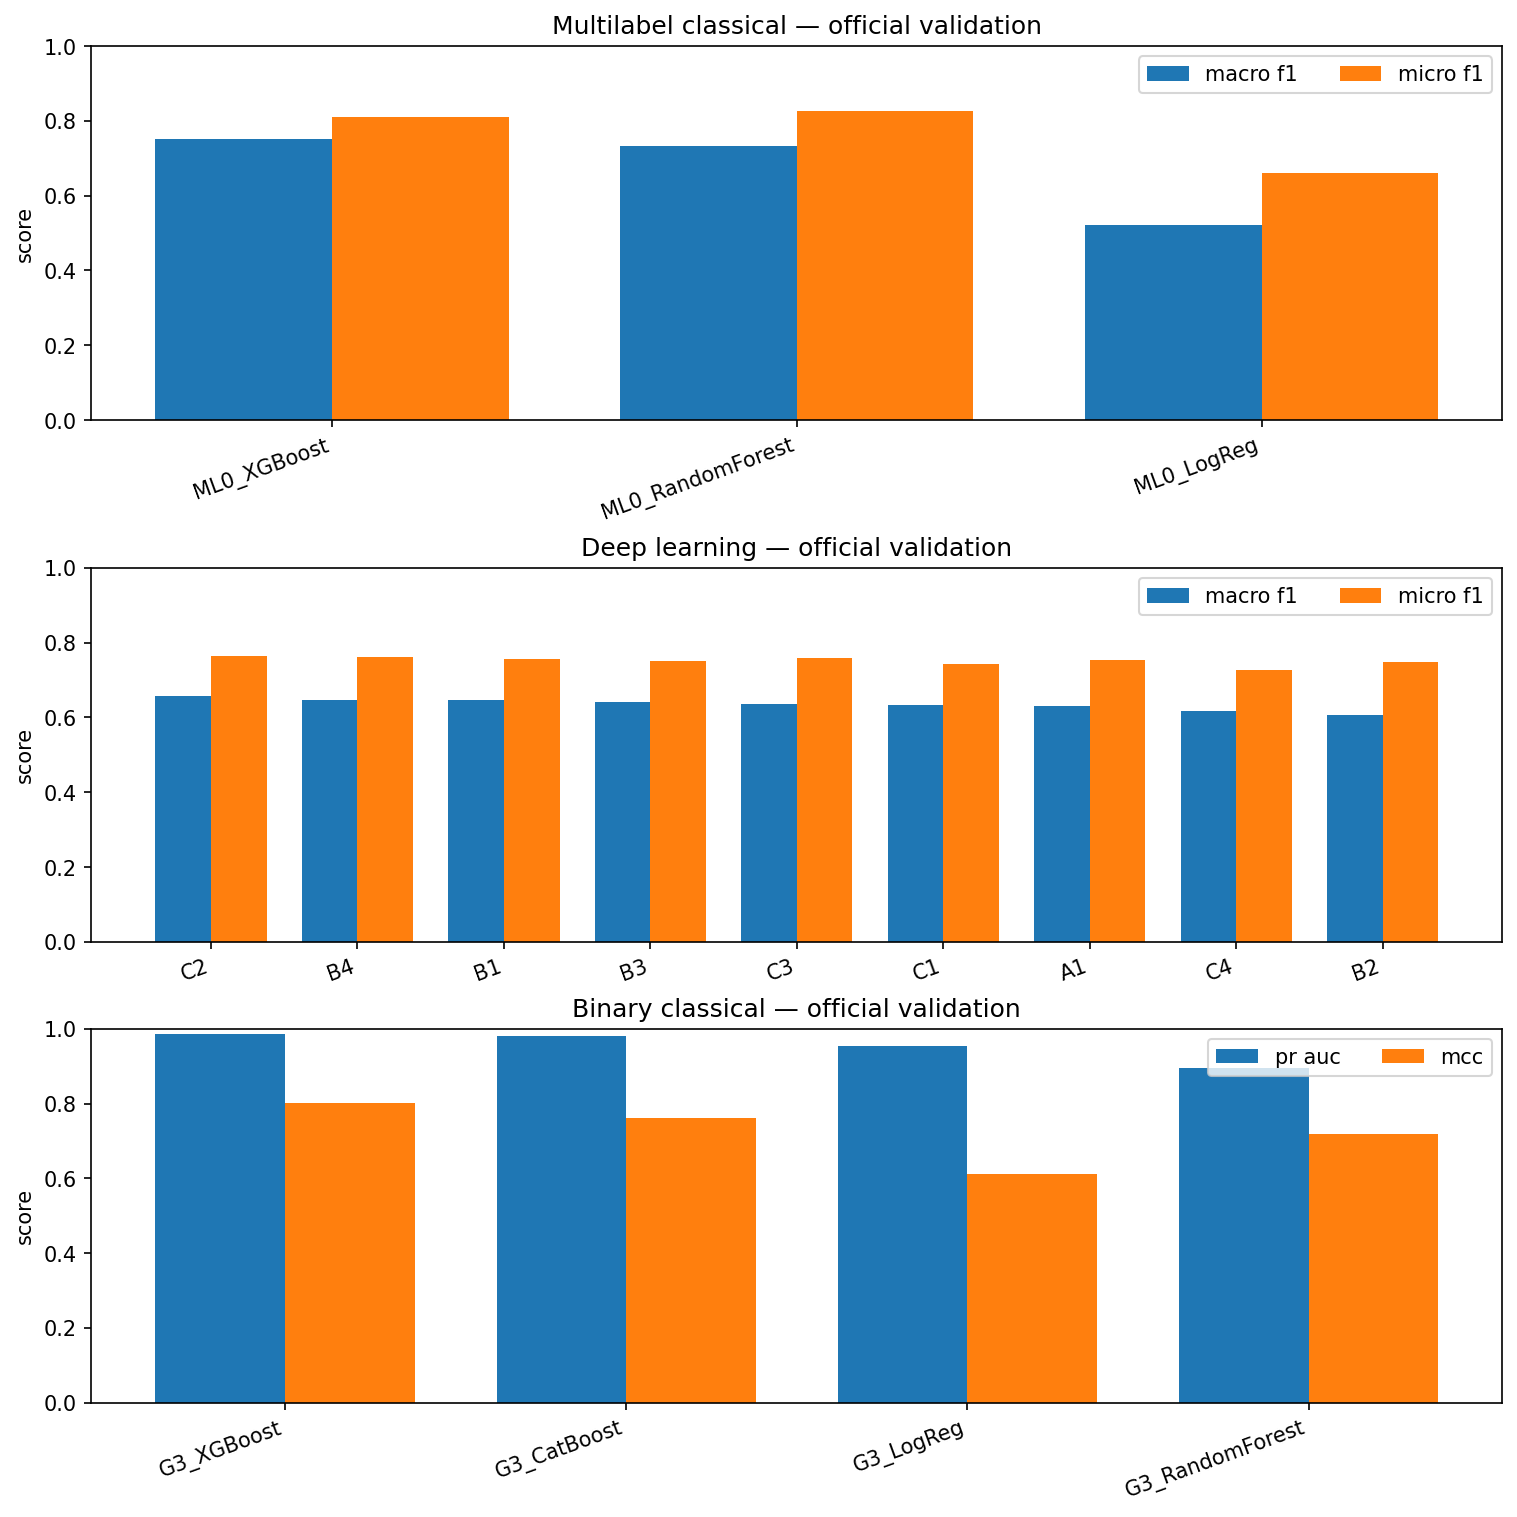

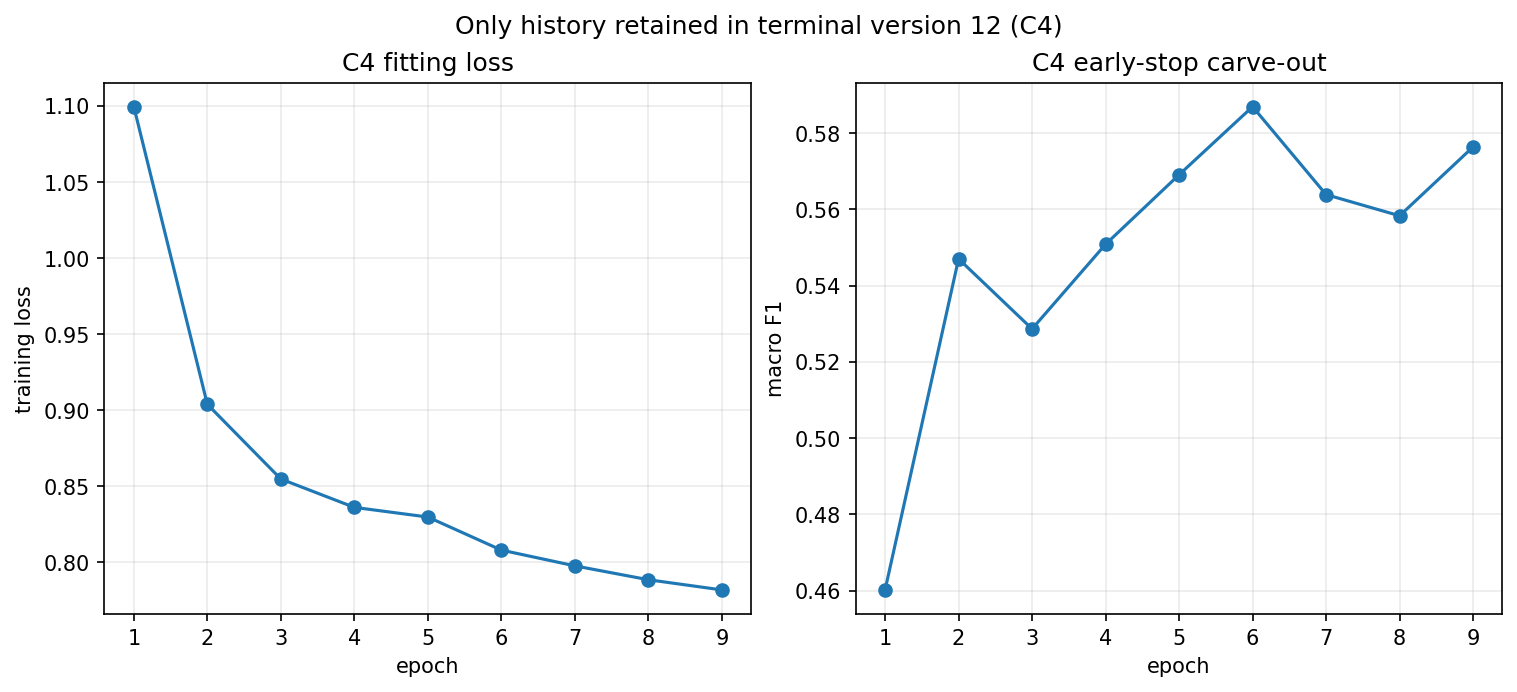

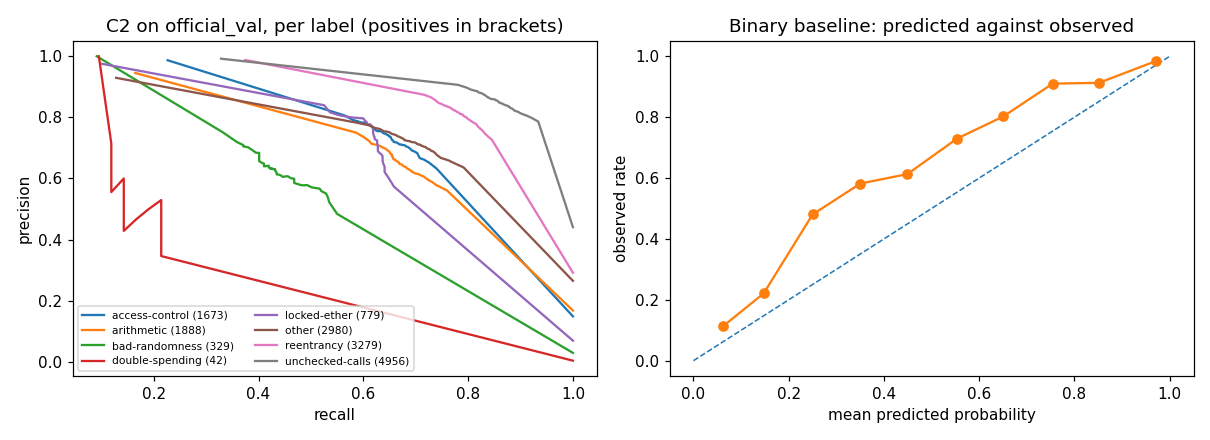

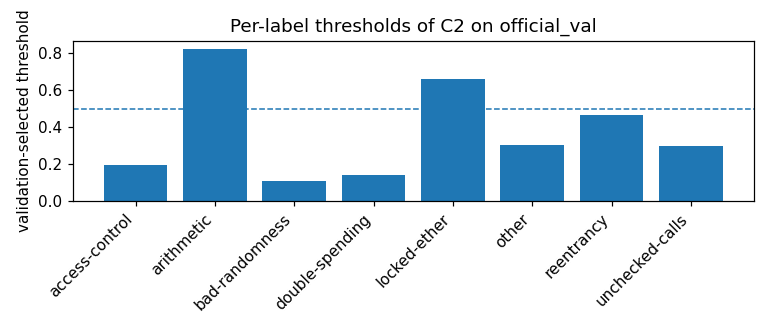


Nothing on this page is a result. The result is the held-out evaluation two
stages further on, which scores the frozen set once with exactly these
thresholds. If you want to argue that another configuration should have been
chosen, the place to do it is here, on validation, before the freeze, and the
answer would be a new run, not a change to this one.

### Validation diagnostics without stale target-score claims

What follows are diagnostics on validation records: the artifacts and their
identities, the coefficients of the logistic baselines, and the binary
registry. No target score is claimed here, and nothing below is a held-out
result.

In [35]:
# Mode-bound multi-seed diagnostics
print("Multi-seed diagnostics are not part of the two-mode contract; the one seed of the mode profile is recorded in the frozen selection.")


Multi-seed diagnostics are not part of the two-mode contract; the one seed of the mode profile is recorded in the frozen selection.


In [36]:
# Feature-importance diagnostics with logical artifact aliases
artifact = SELECTION_AUDIT.selected_artifacts.multilabel_classical
if artifact.relative_path.endswith(".json"):
    coefficients = read_json_record(Path(artifact.relative_path), artifact.identity)
    feature_order = list(SEALED_RUN.resolved.feature_order)
    for label, estimator in zip(coefficients.get("label_order", [str(index) for index in range(len(coefficients["estimators"]))]), coefficients["estimators"]):
        weights = estimator.get("coefficients") or estimator.get("coef") or []
        ranked = sorted(zip(feature_order, weights), key=lambda pair: -abs(pair[1]))[:3]
        print(f"  {label}: " + ", ".join(f"{name} ({weight:+.3f})" for name, weight in ranked))
else:
    print("The complete run stores its classical models as bytes; importances are read from the serialized estimator by the Task 11 harness, not here.")


The complete run stores its classical models as bytes; importances are read from the serialized estimator by the Task 11 harness, not here.


In [37]:
# Prediction-speed diagnostics with logical artifact aliases
print("Inference benchmarking is not part of the two-mode contract.")


Inference benchmarking is not part of the two-mode contract.


### Retired step (intentionally inactive)

RETIRED: this step of the original notebook is switched off on purpose (for example, recursive local or cloud-drive discovery) and will not return. The position is kept so the lineage stays visible.

In [38]:
# Retired step (intentionally inactive)
# RETIRED: this step of the original notebook is switched off on purpose (for example, recursive local or cloud-drive discovery) and will not return. The position is kept so the lineage stays visible.
pass

### Binary proxy-label task and mode-bound registry

The binary task asks whether a contract carries any of the eight proxy labels
at all. Its registry is mode-bound: the logistic baseline in the demonstration;
logistic, random forest, XGBoost and CatBoost in the complete run, ranked on
validation by PR-AUC and the Matthews correlation. The model in the final set
is the logistic baseline, as the science contract fixes.

In [39]:
# Block G — pre-flight: ensure FIG_DIR and CKPT_DIR exist under the authorized run root
FIG_DIR = BASE / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
CKPT_DIR.mkdir(parents=True, exist_ok=True)
print("FIG_DIR  =", FIG_DIR)
print("CKPT_DIR =", CKPT_DIR)
print("RUNS_DIR =", RUNS_DIR)


FIG_DIR  = /kaggle/working/run/figures
CKPT_DIR = /kaggle/working/run/artifacts/models
RUNS_DIR = /kaggle/working/run/artifacts


In [40]:
# Validated binary-model status
artifact = SELECTION_AUDIT.selected_artifacts.binary_classical
print("Binary model in the final set:", artifact.model_key, "| file", artifact.relative_path, "| validation commitment", artifact.validation_predictions_sha256[:16] + "...")


Binary model in the final set: G3_LogReg | file artifacts/models/G3_LogReg.bin | validation commitment c125870907d649a5...


In [41]:
# Role-bound binary targets
print("The binary target is the row-wise maximum of the eight labels, built inside the controller from the same rows as the multilabel task.")


The binary target is the row-wise maximum of the eight labels, built inside the controller from the same rows as the multilabel task.


In [42]:
# Retired step (intentionally inactive)
# RETIRED: this step of the original notebook is switched off on purpose (for example, recursive local or cloud-drive discovery) and will not return. The position is kept so the lineage stays visible.
pass

### Retired step (intentionally inactive)

RETIRED: this step of the original notebook is switched off on purpose (for example, recursive local or cloud-drive discovery) and will not return. The position is kept so the lineage stays visible.

In [43]:
# Retired step (intentionally inactive)
# RETIRED: this step of the original notebook is switched off on purpose (for example, recursive local or cloud-drive discovery) and will not return. The position is kept so the lineage stays visible.
pass

In [44]:
# Exact binary classical registry
registry = TEACHING_REGISTRY if MODE_CONFIG.mode == "TEACHING" else FULL_REGISTRY
print("Binary registry:", registry.binary_classical)
if MODE_CONFIG.mode == "FULL_KAGGLE_GPU":
    ranking_identity = read_json_record(Path("artifacts") / "validation-metrics.json", SELECTION_AUDIT.validation_metrics_identity)["ranking_identity"]
    full_ranking = read_json_record(Path("artifacts") / "full-ranking.json", FileIdentity(**ranking_identity))
    for item in full_ranking["binary_classical"]:
        mcc = "undefined" if item["mcc_f64_hex"] is None else f"{f64(item['mcc_f64_hex']):.4f}"
        print(f"  {item['model_key']}: validation PR-AUC {f64(item['pr_auc_f64_hex']):.4f}, MCC {mcc}")


Binary registry: ('G3_LogReg', 'G3_RandomForest', 'G3_XGBoost', 'G3_CatBoost')
  G3_XGBoost: validation PR-AUC 0.9867, MCC 0.8011
  G3_CatBoost: validation PR-AUC 0.9809, MCC 0.7613
  G3_LogReg: validation PR-AUC 0.9530, MCC 0.6120
  G3_RandomForest: validation PR-AUC 0.8950, MCC 0.7174


In [45]:
# English feature-importance plots and interpretation
import matplotlib.pyplot as plt

artifact = SELECTION_AUDIT.selected_artifacts.binary_classical
if artifact.relative_path.endswith(".json"):
    coefficients = read_json_record(Path(artifact.relative_path), artifact.identity)
    estimator = coefficients["estimators"][0]
    weights = estimator.get("coefficients") or estimator.get("coef") or []
    feature_order = list(SEALED_RUN.resolved.feature_order)
    ranked = sorted(zip(feature_order, weights), key=lambda pair: -abs(pair[1]))[:10]
    figure, axis = plt.subplots(figsize=(7, 3.5))
    axis.barh([name for name, _ in ranked][::-1], [weight for _, weight in ranked][::-1])
    axis.set_xlabel("logistic coefficient (standardised features)")
    axis.set_title("Binary baseline: ten largest coefficients")
    figure.tight_layout()
    figure.savefig(Path("figures") / "binary-importance.png", dpi=110)
    plt.close(figure)
    print("Saved figures/binary-importance.png")
else:
    print("The complete run stores its binary models as bytes; no coefficient plot here.")


The complete run stores its binary models as bytes; no coefficient plot here.


In [46]:
# English SHAP plots and interpretation
print("SHAP explanations are not part of the two-mode contract (no runtime installation, no unregistered computation).")


SHAP explanations are not part of the two-mode contract (no runtime installation, no unregistered computation).


### How the results are scored, and what a score is allowed to say

The cell below defines every number that the final tables will contain. It is
placed before the freeze on purpose: the definitions cannot be adjusted after
the held-out rows have been seen.

**Exact arithmetic.** Each score is a count, a ratio of counts, or a ratio of
values that a computer already stores exactly. So each score is computed
exactly and rounded once at the end. The one exception is the Matthews
correlation, which needs a square root; that is stated in the record.

**Support statuses.** A metric about a class that has no example in the rows
being scored is reported as unsupported and carries no value. A metric about a
class with one to four examples carries its value and the label "low support".
Five or more examples give a plain result. A missing value is never written as
zero, because a zero would read as a result.

**The multilabel scores.** Pooled F1 and mean F1 across the labels, and for each
of the eight labels its own F1 and the area under its precision-recall curve.
**The binary scores.** PR-AUC, ROC-AUC, the Matthews correlation, F1, the Brier
score, a ten-bin calibration error, and recall among the top 1, 5, 10, 20 and 30
percent of contracts ranked by probability, with the rule the author used for
the top-k count kept exactly.

In [47]:
import hashlib
from dataclasses import dataclass
from fractions import Fraction
from typing import Any, Literal

import numpy as np

# ---------------------------------------------------------------------------
# The metric contract: exact arithmetic, one rounding, and support statuses.
#
# Every score below is a count, a ratio of counts, or a ratio of dyadic
# rationals (a 64-bit float is a dyadic rational), so it is computed exactly and
# rounded to a float once. A metric that has no support is reported as
# UNSUPPORTED with no value, never as zero; a metric with one to four positives
# is reported with its value and the status LOW_SUPPORT.
# ---------------------------------------------------------------------------
METRIC_SCHEMA_VERSION = "final_metrics_v1"
METRIC_PROBABILITY_STAGE = "raw_v1"
METRICS_IMPLEMENTATION_IDENTITY = "final_metrics_v1/exact_rational_rn64/2026-09-03"
SUPPORT_OK_MIN = 5
SUPPORT_LOW_MIN = 1
SUPPORT_LOW_MAX = 4
TOPK_FRACTIONS_F64_HEX = ("7b14ae47e17a843f", "9a9999999999a93f", "9a9999999999b93f", "9a9999999999c93f", "333333333333d33f")
TOPK_METRIC_NAMES = ("topk_recall_1pct", "topk_recall_5pct", "topk_recall_10pct", "topk_recall_20pct", "topk_recall_30pct")
ECE_BIN_EDGES_F64_HEX = (
    "0000000000000000", "9a9999999999b93f", "9a9999999999c93f", "333333333333d33f", "9a9999999999d93f", "000000000000e03f",
    "333333333333e33f", "666666666666e63f", "9a9999999999e93f", "cdccccccccccec3f", "000000000000f03f",
)
BINARY_METRIC_NAMES = ("pr_auc", "roc_auc", "mcc", "f1", "brier_score", "ece_10_bin") + TOPK_METRIC_NAMES
RESULT_STATUS_BY_MODE = {"TEACHING": "DEMO_ONLY", "FULL_KAGGLE_GPU": "RETROSPECTIVE_REFERENCE_CANDIDATE"}
MetricStatus = Literal["OK", "LOW_SUPPORT", "UNSUPPORTED"]


@dataclass(frozen=True)
class MetricResult:
    metric_name: str
    scope: Literal["multilabel", "label", "binary"]
    label: str | None
    positive_support: int
    negative_support: int
    supported_label_count: int | None
    status: MetricStatus
    value_f64_hex: str | None


def multilabel_metric_names(label_order: tuple[str, ...]) -> tuple[str, ...]:
    """The exact metric names of the multilabel record, in the bundle's order."""
    names = ["micro_f1", "macro_f1"]
    for label in label_order:
        names.append("f1:" + label)
        names.append("pr_auc:" + label)
    return tuple(names)


def _rn64(value: Fraction) -> float:
    """The one rounding: an exact rational to the nearest 64-bit float."""
    return float(value)


def _support_status(support: int) -> MetricStatus:
    if support < SUPPORT_LOW_MIN:
        return "UNSUPPORTED"
    if support <= SUPPORT_LOW_MAX:
        return "LOW_SUPPORT"
    return "OK"


def _both_class_status(positives: int, negatives: int) -> MetricStatus:
    return _support_status(min(positives, negatives))


def _counts(predicted: np.ndarray, truth: np.ndarray) -> tuple[int, int, int, int]:
    predicted = np.asarray(predicted, dtype=bool)
    truth = np.asarray(truth, dtype=bool)
    tp = int(np.count_nonzero(predicted & truth))
    fp = int(np.count_nonzero(predicted & ~truth))
    fn = int(np.count_nonzero(~predicted & truth))
    tn = int(np.count_nonzero(~predicted & ~truth))
    return tp, fp, fn, tn


def f1_exact(predicted: np.ndarray, truth: np.ndarray) -> Fraction | None:
    """F1 as an exact ratio; None when there is nothing to score (no positive, no prediction)."""
    tp, fp, fn, _ = _counts(predicted, truth)
    denominator = 2 * tp + fp + fn
    if denominator == 0:
        return None
    return Fraction(2 * tp, denominator)


def _ranked_groups(scores: np.ndarray, truth: np.ndarray) -> list[tuple[int, int]]:
    """Positives and negatives per distinct score, from the highest score down."""
    scores = np.asarray(scores, dtype=np.float64)
    truth = np.asarray(truth, dtype=bool)
    order = np.argsort(-scores, kind="stable")
    groups: list[tuple[int, int]] = []
    previous = None
    for index in order:
        score = float(scores[index])
        if previous is None or score != previous:
            groups.append((0, 0))
            previous = score
        positives, negatives = groups[-1]
        groups[-1] = (positives + int(truth[index]), negatives + int(not truth[index]))
    return groups


def average_precision_exact(scores: np.ndarray, truth: np.ndarray) -> Fraction | None:
    """Average precision as the exact sum of precision times recall increment over distinct scores."""
    total_positives = int(np.count_nonzero(np.asarray(truth, dtype=bool)))
    if total_positives == 0:
        return None
    seen_positives, seen = 0, 0
    total = Fraction(0)
    for positives, negatives in _ranked_groups(scores, truth):
        seen_positives += positives
        seen += positives + negatives
        if positives:
            total += Fraction(positives, total_positives) * Fraction(seen_positives, seen)
    return total


def roc_auc_exact(scores: np.ndarray, truth: np.ndarray) -> Fraction | None:
    """ROC-AUC by pair counting, ties at one half; None without both classes."""
    truth_array = np.asarray(truth, dtype=bool)
    positives_total = int(np.count_nonzero(truth_array))
    negatives_total = int(truth_array.size - positives_total)
    if positives_total == 0 or negatives_total == 0:
        return None
    groups = _ranked_groups(scores, truth)
    negatives_above = 0
    pairs = Fraction(0)
    for positives, negatives in groups:
        # a positive in this group beats every negative ranked below it and ties the negatives beside it
        negatives_below = negatives_total - negatives_above - negatives
        pairs += positives * (Fraction(negatives_below) + Fraction(negatives, 2))
        negatives_above += negatives
    return pairs / (positives_total * negatives_total)


def mcc_value(predicted: np.ndarray, truth: np.ndarray) -> float | None:
    """Matthews correlation: the exact squared ratio rounded once, then the signed square root.

    The square root is the one operation that leaves rational arithmetic, so this
    value carries two roundings; the record says so through its implementation
    identity. None when any marginal is empty.
    """
    tp, fp, fn, tn = _counts(predicted, truth)
    denominator = (tp + fp) * (tp + fn) * (tn + fp) * (tn + fn)
    if denominator == 0:
        return None
    numerator = tp * tn - fp * fn
    magnitude = _rn64(Fraction(numerator * numerator, denominator)) ** 0.5
    return magnitude if numerator >= 0 else -magnitude


def brier_exact(probabilities: np.ndarray, truth: np.ndarray) -> Fraction | None:
    probabilities = np.asarray(probabilities, dtype=np.float64)
    truth = np.asarray(truth, dtype=bool)
    if probabilities.size == 0:
        return None
    total = Fraction(0)
    for probability, label in zip(probabilities.tolist(), truth.tolist()):
        difference = Fraction(probability) - (1 if label else 0)
        total += difference * difference
    return total / probabilities.size


def ece_exact(probabilities: np.ndarray, truth: np.ndarray, edges_f64_hex: tuple[str, ...] = ECE_BIN_EDGES_F64_HEX) -> Fraction | None:
    """Expected calibration error over the fixed bins: sum of |mean probability - positive rate| weighted by bin size."""
    probabilities = np.asarray(probabilities, dtype=np.float64)
    truth = np.asarray(truth, dtype=bool)
    if probabilities.size == 0:
        return None
    edges = [f64(item) for item in edges_f64_hex]
    total = Fraction(0)
    for lower, upper in zip(edges[:-1], edges[1:]):
        last = upper == edges[-1]
        inside = (probabilities >= lower) & ((probabilities <= upper) if last else (probabilities < upper))
        count = int(np.count_nonzero(inside))
        if count == 0:
            continue
        mean_probability = sum(Fraction(value) for value in probabilities[inside].tolist()) / count
        positive_rate = Fraction(int(np.count_nonzero(truth[inside])), count)
        total += Fraction(count, probabilities.size) * abs(mean_probability - positive_rate)
    return total


def topk_recall_exact(scores: np.ndarray, truth: np.ndarray, fraction_f64_hex: str) -> Fraction | None:
    """Recall among the top k rows by probability, k = max(1, round(fraction * rows)), capped by the reachable ceiling.

    This is the author's rule from the notebook's block G-6, kept exactly, with
    one difference stated here: ties in probability are broken by row order (a
    stable sort) so that the value does not depend on the sorting algorithm.
    """
    scores = np.asarray(scores, dtype=np.float64)
    truth = np.asarray(truth, dtype=bool)
    rows = int(scores.size)
    positives = int(np.count_nonzero(truth))
    if rows == 0 or positives == 0:
        return None
    k = max(1, int(round(f64(fraction_f64_hex) * rows)))
    order = np.argsort(-scores, kind="stable")
    caught = int(np.count_nonzero(truth[order[:k]]))
    ceiling = min(Fraction(1), Fraction(k, positives))
    return min(Fraction(caught, positives), ceiling)


def _result(name: str, scope: str, label: str | None, positives: int, negatives: int, status: MetricStatus, value: Fraction | float | None, supported_label_count: int | None = None) -> MetricResult:
    if status == "UNSUPPORTED" or value is None:
        return MetricResult(metric_name=name, scope=scope, label=label, positive_support=positives, negative_support=negatives, supported_label_count=supported_label_count, status="UNSUPPORTED" if value is None else status, value_f64_hex=None)
    number = _rn64(value) if isinstance(value, Fraction) else float(value)
    return MetricResult(metric_name=name, scope=scope, label=label, positive_support=positives, negative_support=negatives, supported_label_count=supported_label_count, status=status, value_f64_hex=_f64_hex(number))


def multilabel_metrics(probabilities: np.ndarray, labels: np.ndarray, thresholds: tuple[float, ...], label_order: tuple[str, ...]) -> tuple[MetricResult, ...]:
    """Micro and macro F1 and the per-label F1 and PR-AUC, with a status for each."""
    probabilities = np.asarray(probabilities, dtype=np.float64)
    labels = np.asarray(labels, dtype=bool)
    if probabilities.shape != labels.shape or probabilities.shape[1] != len(label_order) or len(thresholds) != len(label_order):
        raise ValueError("E_METRIC_SHAPE")
    predicted = probabilities >= np.asarray(thresholds, dtype=np.float64)[None, :]
    per_label: list[MetricResult] = []
    micro_tp = micro_fp = micro_fn = 0
    macro_terms: list[Fraction] = []
    worst_status = "OK"
    supported = 0
    for column, label in enumerate(label_order):
        positives = int(np.count_nonzero(labels[:, column]))
        negatives = int(labels.shape[0] - positives)
        status = _support_status(positives)
        per_label.append(_result("f1:" + label, "label", label, positives, negatives, status, f1_exact(predicted[:, column], labels[:, column])))
        per_label.append(_result("pr_auc:" + label, "label", label, positives, negatives, status, average_precision_exact(probabilities[:, column], labels[:, column])))
        if status == "UNSUPPORTED":
            continue
        supported += 1
        if status == "LOW_SUPPORT":
            worst_status = "LOW_SUPPORT"
        tp, fp, fn, _ = _counts(predicted[:, column], labels[:, column])
        micro_tp, micro_fp, micro_fn = micro_tp + tp, micro_fp + fp, micro_fn + fn
        label_f1 = f1_exact(predicted[:, column], labels[:, column])
        macro_terms.append(Fraction(0) if label_f1 is None else label_f1)
    total_positives = int(np.count_nonzero(labels))
    total_negatives = int(labels.size - total_positives)
    if supported == 0:
        aggregate_status: MetricStatus = "UNSUPPORTED"
        micro_value = macro_value = None
    else:
        aggregate_status = worst_status
        micro_denominator = 2 * micro_tp + micro_fp + micro_fn
        micro_value = None if micro_denominator == 0 else Fraction(2 * micro_tp, micro_denominator)
        macro_value = sum(macro_terms, Fraction(0)) / supported
    return (
        _result("micro_f1", "multilabel", None, total_positives, total_negatives, aggregate_status, micro_value, supported),
        _result("macro_f1", "multilabel", None, total_positives, total_negatives, aggregate_status, macro_value, supported),
        *per_label,
    )


def binary_metrics(probabilities: np.ndarray, labels: np.ndarray, threshold: float) -> tuple[MetricResult, ...]:
    """The binary record: PR-AUC, ROC-AUC, MCC, F1, Brier, ECE and the five top-k recalls."""
    probabilities = np.asarray(probabilities, dtype=np.float64).reshape(-1)
    labels = np.asarray(labels, dtype=bool).reshape(-1)
    if probabilities.shape != labels.shape:
        raise ValueError("E_METRIC_SHAPE")
    predicted = probabilities >= float(threshold)
    positives = int(np.count_nonzero(labels))
    negatives = int(labels.size - positives)
    positive_status = _support_status(positives)
    both_status = _both_class_status(positives, negatives)
    nonempty: MetricStatus = "OK" if labels.size > 0 else "UNSUPPORTED"
    results = [
        _result("pr_auc", "binary", None, positives, negatives, positive_status, average_precision_exact(probabilities, labels)),
        _result("roc_auc", "binary", None, positives, negatives, both_status, roc_auc_exact(probabilities, labels)),
        _result("mcc", "binary", None, positives, negatives, both_status, mcc_value(predicted, labels)),
        _result("f1", "binary", None, positives, negatives, positive_status, f1_exact(predicted, labels)),
        _result("brier_score", "binary", None, positives, negatives, nonempty, brier_exact(probabilities, labels)),
        _result("ece_10_bin", "binary", None, positives, negatives, nonempty, ece_exact(probabilities, labels)),
    ]
    for name, fraction_hex in zip(TOPK_METRIC_NAMES, TOPK_FRACTIONS_F64_HEX):
        results.append(_result(name, "binary", None, positives, negatives, positive_status, topk_recall_exact(probabilities, labels, fraction_hex)))
    return tuple(results)


def label_commitment(labels: np.ndarray) -> str:
    return hashlib.sha256(np.ascontiguousarray(np.asarray(labels, dtype=np.uint8)).tobytes(order="C")).hexdigest()


def row_order_commitment(row_ids: tuple[str, ...]) -> str:
    return hashlib.sha256(b"row-order-v1\0" + "\n".join(row_ids).encode("utf-8")).hexdigest()


def final_metrics_record(
    *,
    mode: str,
    role: str,
    result_status: str,
    model_key: str,
    label_order: tuple[str, ...],
    probabilities: np.ndarray,
    labels: np.ndarray,
    row_ids: tuple[str, ...],
    selection_record_sha256: str,
    threshold_grid_indices: tuple[int, ...],
    thresholds: tuple[float, ...],
    scope: Literal["multilabel", "binary"],
) -> dict:
    """The final-metrics record with exactly the bundle's fields, digest included."""
    if RESULT_STATUS_BY_MODE.get(mode) != result_status:
        raise RuntimeError("E_RESULT_STATUS_MODE:" + str(mode) + ":" + str(result_status))
    probabilities = np.asarray(probabilities, dtype=np.float64)
    if scope == "multilabel":
        results = multilabel_metrics(probabilities, labels, thresholds, label_order)
        names = multilabel_metric_names(label_order)
    else:
        results = binary_metrics(probabilities[:, 0] if probabilities.ndim == 2 else probabilities, labels, thresholds[0])
        names = BINARY_METRIC_NAMES
    if tuple(item.metric_name for item in results) != tuple(names):
        raise RuntimeError("E_METRIC_NAMES")
    record = {
        "schema_version": METRIC_SCHEMA_VERSION,
        "mode": mode,
        "role": role,
        "result_status": result_status,
        "model_key": model_key,
        "label_order": list(label_order),
        "rows": int(probabilities.shape[0]),
        "raw_probability_commitment": probability_commitment(probabilities),
        "metric_probability_stage": METRIC_PROBABILITY_STAGE,
        "selection_record_sha256": selection_record_sha256,
        "threshold_grid_indices": list(int(index) for index in threshold_grid_indices),
        "thresholds_f64_hex": [_f64_hex(float(value)) for value in thresholds],
        "metric_names": list(names),
        "metric_results": [
            {
                "metric_name": item.metric_name, "scope": item.scope, "label": item.label,
                "positive_support": item.positive_support, "negative_support": item.negative_support,
                "supported_label_count": item.supported_label_count, "status": item.status, "value_f64_hex": item.value_f64_hex,
            }
            for item in results
        ],
        "probability_commitment": probability_commitment(probabilities),
        "label_commitment": label_commitment(labels),
        "row_order_commitment": row_order_commitment(row_ids),
        "implementation_identity": METRICS_IMPLEMENTATION_IDENTITY,
    }
    record["record_sha256"] = record_digest(b"final-metrics-v1\0", record, "record_sha256")
    return record


What these definitions do not decide. They do not choose thresholds (the
validation rows did that, before the freeze), they do not compare models on the
held-out rows (no ranking happens there), and they do not calibrate anything.
Two details are recorded rather than hidden: ties in probability are broken by
row order so that the top-k count is the same on every machine, and the
Matthews correlation is rounded twice because of its square root.

### The freeze: the moment after which nothing about the selection may change

Up to here every decision used training and validation rows only. This cell
first draws the validation picture from the records the controller already
wrote. Then it asks the controller to freeze the selection: the three final
models, their thresholds, the identities of their files and of the validation
evidence become one record with a fingerprint. Before writing it, the
controller reads those three files back from disk and re-scores the validation
rows; a file that does not reproduce its recorded scores stops the run.

After the freeze comes B5, a diagnostic rather than a model: for four of the
trained configurations it compares validation macro F1 at a fixed threshold of
one half with the thresholds chosen on validation, from the probabilities the
controller saved during selection. It builds nothing, fits nothing, and changes
nothing; its record is required before the held-out rows can be opened.

Then one more diagnostic: what the two classical baselines actually used. For a
linear model the contribution of a feature to a row is its coefficient times how
far that row sits from the average, which is exactly that model's SHAP value
against an average background, so it is computed directly rather than estimated.
The network is not explained here: at full size that would cost hours of a
session for a picture.

In [48]:
# Stage 12: the validation picture, then the freeze and the B5 diagnostic.
# Everything drawn here comes from validation records the controller already
# wrote; nothing below touches a held-out row.
import matplotlib.pyplot as plt

# figures live beside the artifacts tree, in a directory the controller created at setup
FIGURES_DIR = Path("figures")
VALIDATION_METRICS = read_json_record(Path("artifacts") / "validation-metrics.json", SELECTION_AUDIT.validation_metrics_identity)
ranking_keys = [item["model_key"] for item in VALIDATION_METRICS["ranking"]]
ranking_scores = [f64(item["macro_f1_f64_hex"]) for item in VALIDATION_METRICS["ranking"]]
figure, axis = plt.subplots(figsize=(7, 3))
axis.bar(ranking_keys, ranking_scores)
axis.set_ylabel("validation macro F1")
axis.set_title(f"Validation ranking ({VALIDATION_METRICS['validation_role']}), selected: {VALIDATION_METRICS['selected_dl_key']}")
figure.tight_layout()
figure.savefig(FIGURES_DIR / "validation-ranking.png", dpi=110)
plt.close(figure)

# The freeze. After this call the selection is a record with a fingerprint, and
# no later cell can change which models are evaluated or with which thresholds.
FROZEN_SELECTION = SEALED_RUN.controller.freeze_selection()
FROZEN_RECORD = read_json_record(Path("artifacts") / "state" / "selection-frozen.json", FROZEN_SELECTION.persisted_record_identity)
print("Mode:", FROZEN_SELECTION.mode, "| result status:", FROZEN_SELECTION.result_status)
print("Frozen final evaluation set:", FROZEN_RECORD["final_evaluation_set"])
print("Selection fingerprint:", FROZEN_SELECTION.selection_fingerprint)

# B5: a diagnostic on validation only, after the freeze and before any held-out row.
B5_DIAGNOSTIC = SEALED_RUN.controller.run_b5_diagnostic()
print("B5 threshold sensitivity on", B5_DIAGNOSTIC.validation_role, "(optimized minus fixed 0.5, macro F1):")
for key, delta_hex in zip(B5_DIAGNOSTIC.source_model_keys, B5_DIAGNOSTIC.sensitivity_delta_f64_hex):
    print(f"  {key}: {f64(delta_hex):+.4f}")

# What the classical baselines actually used, on the validation rows. For a linear
# model these attributions are its SHAP values against the mean of those rows, so
# they are computed directly rather than estimated.
EXPLAINABILITY = SEALED_RUN.controller.run_explainability_diagnostic()
ATTRIBUTIONS = read_json_record(Path("artifacts") / "explainability-diagnostic.json", EXPLAINABILITY.artifact_identity)
figure, axes = plt.subplots(1, len(ATTRIBUTIONS["models"]), figsize=(11, 4))
for axis, (model_key, entry) in zip(list(axes) if len(ATTRIBUTIONS["models"]) > 1 else [axes], ATTRIBUTIONS["models"].items()):
    output_name, output = next(iter(entry["outputs"].items()))
    names = output["top_features"][::-1]
    values = [f64(item) for item in output["top_mean_absolute_f64_hex"]][::-1]
    axis.barh(names, values)
    axis.set_xlabel("mean absolute attribution")
    axis.set_title(f"{model_key} ({output_name})", fontsize="small")
figure.suptitle(f"Feature attributions on {ATTRIBUTIONS['validation_role']}, diagnostic only")
figure.tight_layout()
figure.savefig(FIGURES_DIR / "feature-attributions.png", dpi=110)
plt.close(figure)
print("Attributions written for:", list(ATTRIBUTIONS["models"]), "| method:", next(iter(ATTRIBUTIONS["models"].values()))["method"])


/tmp/ipykernel_66/1728766555.py:202: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(layer, num_layers=architecture.n_transformer_layers)


Mode: FULL_KAGGLE_GPU | result status: RETROSPECTIVE_REFERENCE_CANDIDATE
Frozen final evaluation set: ['ML0_LogReg', 'C2', 'G3_LogReg']
Selection fingerprint: 07ad6c39f9b7f6dafc40807f55d4d20d45e657363ae79d8f2a3bc900717b0c2d
B5 threshold sensitivity on official_val (optimized minus fixed 0.5, macro F1):
  B1: +0.0109
  B2: +0.0177
  B3: +0.0217
  B4: +0.0258


Attributions written for: ['G3_LogReg', 'ML0_LogReg'] | method: linear_shap_coefficient_times_centred_feature_v1


## Reader view: frozen selection, B5 and diagnostic attribution

**B5 is diagnostic only.** It compares fixed 0.5 with validation-optimized thresholds for B1–B4 after the final set is frozen and before the heldout reader opens. It trains no additional model, does not enter ranking, and leaves the selection fingerprint unchanged. The attribution figure is likewise a validation diagnostic.

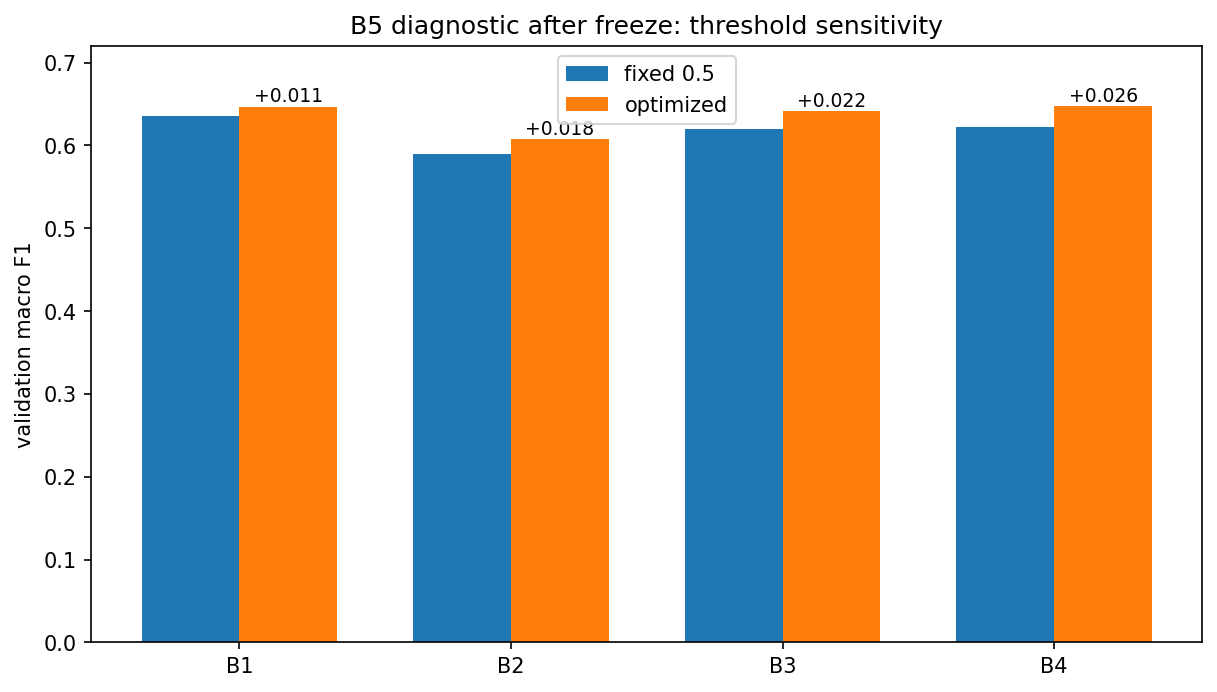

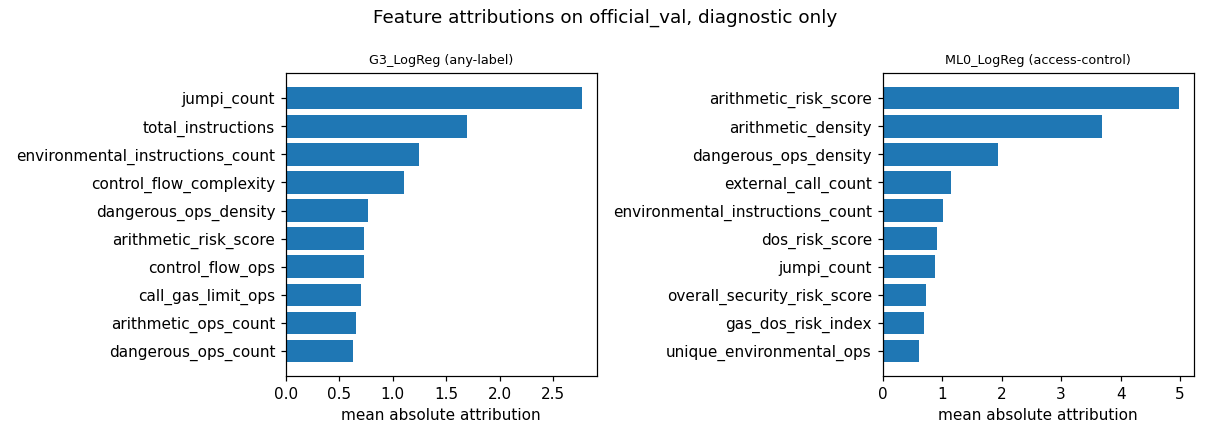


What to check here. The final evaluation set has exactly three entries, one
per role, and the middle one is the configuration that won the validation
ranking. The fingerprint printed above is the one the held-out stage will
re-read; if the two ever differ, the run refuses to continue. The B5 deltas are
validation numbers about thresholds, not a result of the model. The attribution
bars say which features the baselines leaned on, on validation rows, and nothing
about the held-out rows.

### One held-out evaluation, with everything decided beforehand

This is the only cell that reaches the held-out rows (the demonstration's
held-out slice, or the official test rows in the complete run). It calls the
controller once. The controller re-reads the frozen record by its identity,
recomputes its fingerprint, writes a durable access record, and only then reads
the rows, once. It scores exactly the frozen keys with the frozen thresholds,
writes one record per model, and writes the manifest of every artifact. A
second call is refused.

The table that follows is the predeclared summary: every metric with its
support status. Nothing else is computed from the held-out rows after this
cell, and nothing here changes a threshold or a model.

**Expected runtime and hardware.** Runtime: one scoring pass per final model, seconds in the demonstration and minutes in the complete run. Hardware: the same device as the selection.

In [49]:
# Stage 13 and 14: the one held-out evaluation, and only the predeclared summary.
# The controller re-reads the frozen record, opens the held-out role once, scores
# exactly the frozen keys with the frozen thresholds, and writes the records.
FINAL_EVALUATION = SEALED_RUN.controller.evaluate_frozen_once()
FINAL_INDEX = read_json_record(Path("artifacts") / "final-metrics.json", FINAL_EVALUATION.metrics_identity)
if FINAL_INDEX["result_keys"] != FROZEN_RECORD["final_evaluation_set"]:
    raise RuntimeError("E_FINAL_RESULT_KEYS:public")
print("Held-out role:", FINAL_EVALUATION.role, "| result status:", FINAL_EVALUATION.result_status, "| rows:", FINAL_INDEX["rows"])
print("Result keys (equal to the frozen set):", FINAL_INDEX["result_keys"])

# The predeclared summary: every metric of every final model with its support
# status. An UNSUPPORTED metric has no value; it is never a zero.
FINAL_RECORDS = {}
for key in FINAL_INDEX["result_keys"]:
    FINAL_RECORDS[key] = read_json_record(Path("artifacts") / "final" / (key + ".json"), FileIdentity(**FINAL_INDEX["records"][key]))
summary_rows = []
for key, record in FINAL_RECORDS.items():
    for item in record["metric_results"]:
        value = "unsupported" if item["value_f64_hex"] is None else f"{f64(item['value_f64_hex']):.4f}"
        summary_rows.append((key, item["metric_name"], item["status"], value, item["positive_support"]))
width = max(len(row[1]) for row in summary_rows)
print(f"{'model':16s} {'metric':{width}s} {'status':12s} {'value':>12s} {'positives':>9s}")
for key, name, status, value, positives in summary_rows:
    print(f"{key:16s} {name:{width}s} {status:12s} {value:>12s} {positives:>9d}")


/tmp/ipykernel_66/1728766555.py:202: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(layer, num_layers=architecture.n_transformer_layers)


Held-out role: official_test | result status: RETROSPECTIVE_REFERENCE_CANDIDATE | rows: 11247
Result keys (equal to the frozen set): ['ML0_LogReg', 'C2', 'G3_LogReg']
model            metric                 status              value positives
ML0_LogReg       micro_f1               OK                 0.6523     15964
ML0_LogReg       macro_f1               OK                 0.5017     15964
ML0_LogReg       f1:access-control      OK                 0.4869      1664
ML0_LogReg       pr_auc:access-control  OK                 0.4645      1664
ML0_LogReg       f1:arithmetic          OK                 0.4975      1868
ML0_LogReg       pr_auc:arithmetic      OK                 0.4390      1868
ML0_LogReg       f1:bad-randomness      OK                 0.3010       288
ML0_LogReg       pr_auc:bad-randomness  OK                 0.2149       288
ML0_LogReg       f1:double-spending     OK                 0.1215        39
ML0_LogReg       pr_auc:double-spending OK                 0.0626        

How to read the table. A status of unsupported means the held-out rows contain
no example of that class, so the metric has no value; low support means one to
four examples. In the demonstration the held-out slice is small and several
labels will read this way; that is a fact about the slice, not a defect of the
model. Every demonstration result is labelled DEMO_ONLY, and every result of the
complete run is labelled a retrospective reference candidate, because the split
it uses was released with the data rather than drawn fresh.

### Top-k prioritization diagnostics

Recall among the top k contracts by probability, for k equal to 1, 5, 10, 20 and
30 percent of the held-out rows, with the author's rule for the count kept
exactly. These are predeclared held-out summaries: read from the final
records, computed once, with their support statuses.

In [50]:
# English top-k plots and interpretation
import matplotlib.pyplot as plt

binary_record = FINAL_RECORDS["G3_LogReg"]
topk = [item for item in binary_record["metric_results"] if item["metric_name"].startswith("topk_recall_")]
labels = [item["metric_name"].split("topk_recall_")[1].split("pct")[0] + "%" for item in topk]
values = [0.0 if item["value_f64_hex"] is None else f64(item["value_f64_hex"]) for item in topk]
figure, axis = plt.subplots(figsize=(6, 3))
axis.bar(labels, values)
axis.set_ylim(0, 1)
axis.set_ylabel("recall among the top k")
axis.set_title(f"Top-k recall on {binary_record['role']} ({binary_record['result_status']})")
figure.tight_layout()
figure.savefig(Path("figures") / "topk-recall.png", dpi=110)
plt.close(figure)
for item, value in zip(topk, values):
    print(f"  {item['metric_name']:18s} {item['status']:12s} " + ("no value" if item["value_f64_hex"] is None else f"{value:.4f}") + f"  (positives {item['positive_support']})")


  topk_recall_1pct   OK           0.0142  (positives 7761)
  topk_recall_5pct   OK           0.0720  (positives 7761)
  topk_recall_10pct  OK           0.1442  (positives 7761)
  topk_recall_20pct  OK           0.2871  (positives 7761)
  topk_recall_30pct  OK           0.4288  (positives 7761)


### Verified-result context and proxy-label limitations

Every number in the final records is a held-out value with a support status;
unsupported metrics have no value. The labels are a static analyser's proxy,
not ground truth, and the split of the complete run is the one released with
the data. Interpret the demonstration as a demonstration of the procedure and
the complete run as a retrospective reference.

In [51]:
# Retired step (intentionally inactive)
# RETIRED: this step of the original notebook is switched off on purpose (for example, recursive local or cloud-drive discovery) and will not return. The position is kept so the lineage stays visible.
pass

## 15. Final Summary: Per-Label F1 Across All Runs

In [52]:
# English result-table columns and logical receipts
print(f"{'model':16s} {'metric':22s} {'status':12s} {'value':>10s}")
for key, record in FINAL_RECORDS.items():
    wanted = ("macro_f1", "micro_f1") if not key.startswith("G3_") else ("pr_auc", "roc_auc", "mcc", "f1")
    for item in record["metric_results"]:
        if item["metric_name"] in wanted:
            value = "unsupported" if item["value_f64_hex"] is None else f"{f64(item['value_f64_hex']):.4f}"
            print(f"{key:16s} {item['metric_name']:22s} {item['status']:12s} {value:>10s}")
print("Result status of every row:", FINAL_INDEX["result_status"])


model            metric                 status            value
ML0_LogReg       micro_f1               OK               0.6523
ML0_LogReg       macro_f1               OK               0.5017
C2               micro_f1               OK               0.7613
C2               macro_f1               OK               0.6539
G3_LogReg        pr_auc                 OK               0.9528
G3_LogReg        roc_auc                OK               0.9050
G3_LogReg        mcc                    OK               0.6099
G3_LogReg        f1                     OK               0.8901
Result status of every row: RETROSPECTIVE_REFERENCE_CANDIDATE


In [53]:
# English per-label summary visualization
import matplotlib.pyplot as plt

figure, axis = plt.subplots(figsize=(8, 3.5))
label_order = FINAL_INDEX["label_commitment"] and next(iter(FINAL_RECORDS.values()))["label_order"]
positions = range(len(label_order))
width = 0.4
for offset, (key, record) in enumerate(item for item in FINAL_RECORDS.items() if not item[0].startswith("G3_")):
    per_label = {item["metric_name"]: item for item in record["metric_results"]}
    values = [0.0 if per_label["f1:" + label]["value_f64_hex"] is None else f64(per_label["f1:" + label]["value_f64_hex"]) for label in label_order]
    axis.bar([position + offset * width for position in positions], values, width=width, label=key)
axis.set_xticks([position + width / 2 for position in positions])
axis.set_xticklabels(label_order, rotation=45, ha="right")
axis.set_ylim(0, 1)
axis.set_ylabel("held-out F1 (unsupported labels shown as empty)")
axis.legend()
figure.tight_layout()
figure.savefig(Path("figures") / "final-per-label-f1.png", dpi=110)
plt.close(figure)
print("Saved figures/final-per-label-f1.png; every bar is a held-out value with its status in the table above.")


Saved figures/final-per-label-f1.png; every bar is a held-out value with its status in the table above.


## Reader view: the frozen official-test evaluation

The final set is **ML0_LogReg, C2, and G3_LogReg**. It was fixed before the one recorded `official_test` access. The per-label figure compares the two multilabel models; the top-k figure belongs to the binary G3_LogReg reference. These are recorded retrospective results, not evidence of canonical-opcode semantics or a new untouched external test.

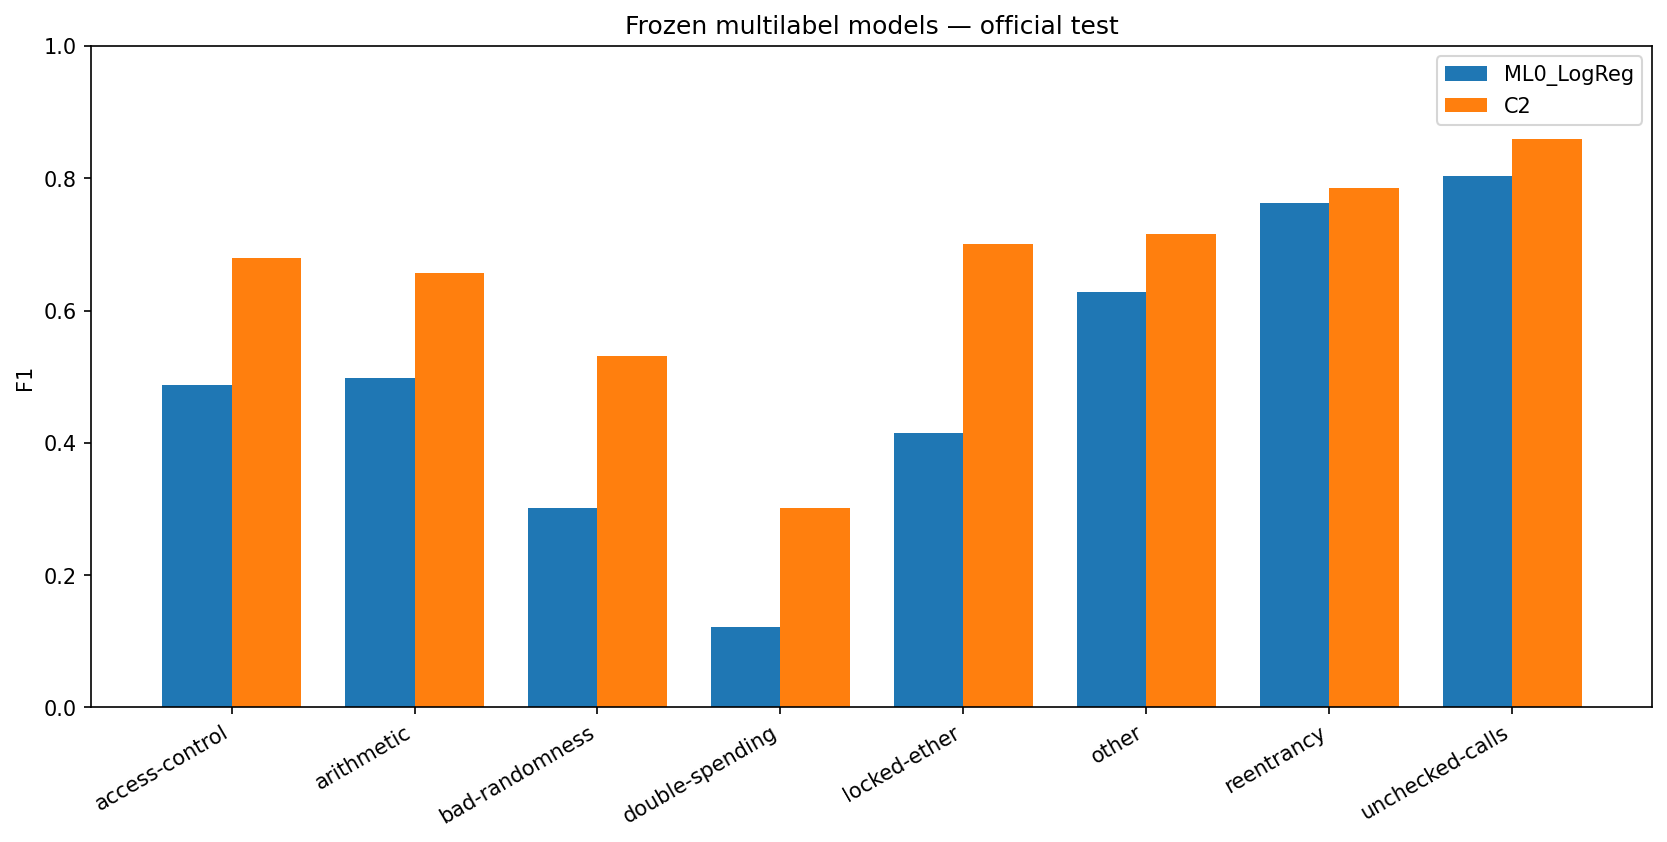

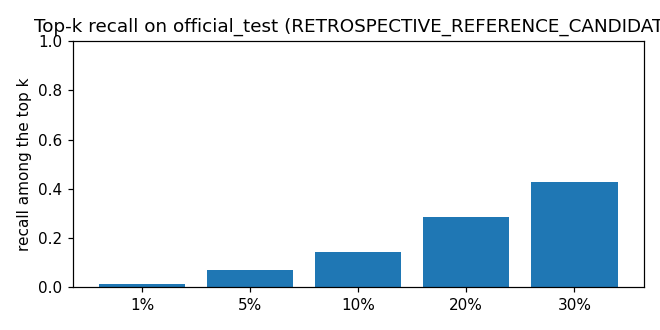


### Provenance: what was produced, and how to check it

The controller lists every artifact of the run with its size and digest in a
manifest that does not hash itself, and then writes a receipt that binds the
manifest, the final state record, this attempt, and any file added after the
evaluation. This cell reads both back by their identities and verifies every
file on disk against them; a missing, changed, or unlisted file stops the cell.

In [54]:
# Stage 15: the artifact manifest and the receipt, verified from disk.
# The manifest lists every artifact the controller wrote, with its size and
# digest, and does not hash itself; the receipt binds the manifest, the final
# state record and this attempt. Every listed file is re-read here and must
# match. Whether anything else sits in the artifacts tree is the validator's
# question (it enumerates; this cell does not).
RECEIPT = SEALED_RUN.controller.finalize_provenance()
MANIFEST = read_json_record(Path("artifacts") / "manifest.json", RECEIPT.manifest_identity)
RECEIPT_RECORD = read_json_record(Path("artifacts") / "receipt.json", RECEIPT.receipt_identity)
verified, mismatched = 0, []
for entry in list(MANIFEST["files"]) + list(RECEIPT_RECORD["files_after_evaluation"]):
    payload = Path(entry["relative_path"]).read_bytes()
    if len(payload) != entry["bytes"] or hashlib.sha256(payload).hexdigest() != entry["sha256"]:
        mismatched.append(entry["relative_path"])
    else:
        verified += 1
if mismatched:
    raise RuntimeError("E_PROVENANCE_VERIFY:" + ",".join(mismatched))
print("Artifacts verified against the manifest and the receipt:", verified)
print("Manifest identity:", RECEIPT.manifest_identity.sha256)
print("Receipt identity:", RECEIPT.receipt_identity.sha256)
print("Result status of every record in this run:", RECEIPT.result_status)


Artifacts verified against the manifest and the receipt: 53
Manifest identity: f939a2c4c6d11c1173672febae8923f4b77803da5e676d81e52c346d2d21eec0
Receipt identity: db96ea88252c5839dd4fa0a94fcdff677acca60b2624c376a3436e4e572872e8
Result status of every record in this run: RETROSPECTIVE_REFERENCE_CANDIDATE


**Model card and limitations.** The models here are trained on labels produced
by a static analyser (a proxy for vulnerabilities, not ground truth) over a
single tier of contracts, and evaluated on a split that was released with the
data. The complete run is therefore a retrospective reference, not a claim
about contracts the models have never seen in the wild. The demonstration is a
demonstration of the procedure. Neither replaces an audit, and neither should
be used to clear a contract.

**Responsible use.** Use the scores to decide what to inspect first, never
what to skip. The artifacts and their digests let anyone repeat the checks in
this notebook without trusting its printed numbers.